In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# todo junto y correlaciones, rio - clima- frea

Infomacion del drive

In [ ]:
import pandas as pd
ruta_nivel_rio = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/nivelRioNegro_mensual_2010_2023.xlsx'
ruta_freatimetros = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
archivo_csv = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datos_promedios_mensuales_clima.csv'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosClima = pd.read_csv(archivo_csv)
# Leer el archivo Excel y cargar la pestaña en un DataFrame
FreatimetrosImputados = pd.read_excel(ruta_freatimetros, sheet_name=nombre_pestaña)
nivelRioNegro_mensual_2010_2023 = pd.read_excel(ruta_nivel_rio, sheet_name=nombre_pestaña)


In [ ]:

#cambie un Date de por pd.to_datetime(FreatimetrosImputados['Date']) fecha
FreatimetrosImputados['fecha'] = pd.to_datetime(FreatimetrosImputados['fecha'])
nivelRioNegro_mensual_2010_2023['fecha'] = pd.to_datetime(nivelRioNegro_mensual_2010_2023['Date'])
datosClima['Date'] = pd.to_datetime(datosClima['Date'])
# Filtrar datos para el DataFrame DF
filtro_DF = (FreatimetrosImputados['fecha'].dt.year >= 2010) & (FreatimetrosImputados['fecha'].dt.year <= 2023) & (FreatimetrosImputados['fecha'].dt.month.isin([9,10,11,12,1,2,3,4]))
freatimetros_caso2 = FreatimetrosImputados[filtro_DF]

# Filtrar datos para el DataFrame promediosAlturaRoca_df
filtro_promedios = (nivelRioNegro_mensual_2010_2023['fecha'].dt.year >= 2010) & (nivelRioNegro_mensual_2010_2023['fecha'].dt.year <= 2023) & (nivelRioNegro_mensual_2010_2023['fecha'].dt.month.isin([9,10,11,12,1,2,3,4]))
nivelRioNegro_caso2 = nivelRioNegro_mensual_2010_2023[filtro_promedios]

# de sept a abril
filtro_datosClima_caso2 =(datosClima['Date'].dt.month.isin([9,10,11,12,1,2,3,4]))
datosClima_caso2 = datosClima[filtro_datosClima_caso2]
# Mostrar los datos filtrados


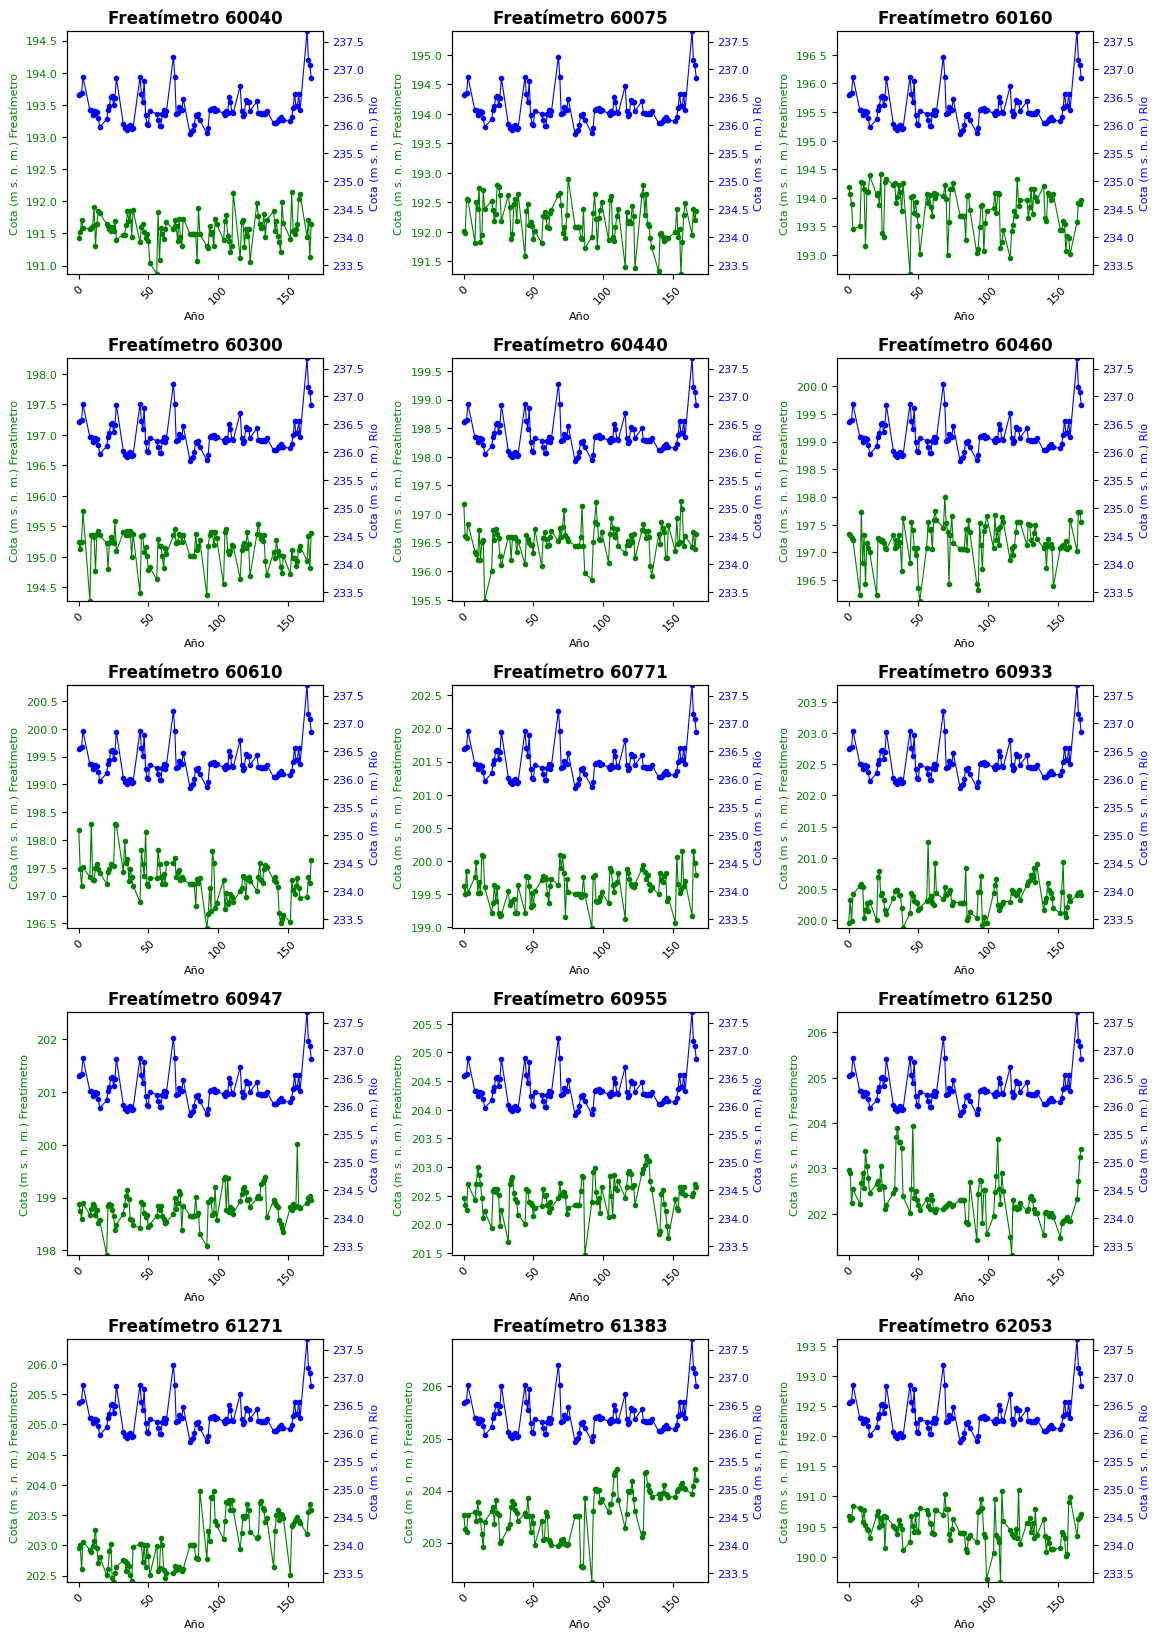

In [ ]:
import matplotlib.pyplot as plt

# Lista de freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Número de filas y columnas para los subplots
n_rows = 5
n_cols = 3

# Crear la figura y los ejes con subplots
fig, axs = plt.subplots(n_rows, n_cols, figsize=(11.7, 16.5))  # A4 (11.7 x 16.5 pulgadas)



# Iterar sobre cada freatímetro y generar gráficos individuales en cada subplot
for i, freatimetro in enumerate(freatimetros):
    # Definir fila y columna del subplot actual
    row = i // n_cols
    col = i % n_cols

    # Obtener el subplot actual
    ax1 = axs[row, col]

    # Freatímetro actual
    freatimetro_data = freatimetros_caso2[freatimetro]

    # Dibujar la gráfica del freatímetro con líneas más finas y puntos más pequeños
    ax1.plot(freatimetro_data, marker='o', markersize=3, linestyle='-', linewidth=0.8, color='green', label=f'Freatímetro {freatimetro}')
    ax1.set_xlabel('Año', fontsize=8)
    ax1.set_ylabel('Cota (m s. n. m.) Freatímetro', color='green', fontsize=8)
    ax1.tick_params(axis='y', labelcolor='green', labelsize=8)

    # Dibujar el gráfico lineal para el promedio del río
    ax2 = ax1.twinx()
    ax2.plot(nivelRioNegro_caso2['promedio'], marker='o', markersize=3, linestyle='-', linewidth=0.8, color='blue', label='Promedio de Altura río')
    ax2.set_ylabel('Cota (m s. n. m.) Río', color='blue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=8)

    # Ajustar los límites del eje y
    buffer = 2.5  # Espacio entre los gráficos
    ax1.set_ylim([freatimetro_data.min(), freatimetro_data.max() + buffer])
    ax2.set_ylim([nivelRioNegro_caso2['promedio'].min() - buffer, nivelRioNegro_caso2['promedio'].max()])

    # Ajustar el tamaño y la rotación de las etiquetas del eje x
    ax1.tick_params(axis='x', labelsize=8, rotation=45)  # Tamaño y rotación del texto en el eje x

    # Añadir título a cada subplot
    ax1.set_title(f'Freatímetro {freatimetro}', fontsize=12, fontweight='bold')


# Ajustar el diseño de la figura
fig.tight_layout()

# Mostrar el gráfico
plt.show()


In [ ]:
import pandas as pd


datosClima = datosClima_caso2.rename(columns={'Date': 'fecha'})
# Asegurar que las columnas 'fecha' de todos los DataFrames estén en formato datetime
datosClima['fecha'] = pd.to_datetime(datosClima['fecha'])
freatimetros_caso2['fecha'] = pd.to_datetime(freatimetros_caso2['fecha'])
nivelRioNegro_caso2['fecha'] = pd.to_datetime(nivelRioNegro_caso2['fecha'])

# Crear columnas de 'año-mes' para los DataFrames
datosClima['año_mes'] = datosClima['fecha'].dt.to_period('M')
freatimetros_caso2['año_mes'] = freatimetros_caso2['fecha'].dt.to_period('M')
nivelRioNegro_caso2['año_mes'] = nivelRioNegro_caso2['fecha'].dt.to_period('M')

# Unir datosClima y datos_filtrados_DF usando 'año_mes' como clave
df_merged = pd.merge(datosClima, freatimetros_caso2, on='año_mes', how='inner')

# Luego, unir con datos_filtrados_promedios también usando 'año_mes' como clave
df_merged_final = pd.merge(df_merged, nivelRioNegro_caso2, on='año_mes', how='inner')

# Renombrar la columna 'promedio' a 'nivelRio'
df_merged_final = df_merged_final.rename(columns={'promedio': 'nivelRio'})
# Reordenar las columnas para que 'nivelRio' esté en la primera posición
cols = ['nivelRio'] + [col for col in df_merged_final.columns if col != 'nivelRio']
df_merged_final = df_merged_final[cols]

#df_merged_final = df_merged_final.drop(columns=['index'])
#cambie por fecha porque daba error
df_merged_final = df_merged_final.drop(columns=['fecha'])

df_merged_final = df_merged_final.drop(columns=['año_mes'])
#df_merged_final = df_merged_final.drop(columns=['fecha'])
df_merged_final = df_merged_final.drop(columns=['fecha_x'])
df_merged_final = df_merged_final.drop(columns=['fecha_y'])
df_merged_final = df_merged_final.drop(columns=['año'])
df_merged_final = df_merged_final.drop(columns=['mes'])
df_merged_final.to_excel('/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datasetRedNcaso2.xlsx')
# Mostrar las primeras filas para verificar la unión
print(df_merged_final.head)

<bound method NDFrame.head of       nivelRio Year-Month   Temp Out    Hi Temp   Low Temp    Out Hum  \
0   236.547742    2010-01  15.519254  15.679427  15.359879  54.647326   
1   236.556429    2010-02  17.161264  17.345704  16.978229  50.445964   
2   236.584839    2010-03  19.292587  19.465814  19.117658  60.934078   
3   236.864667    2010-04  13.971620  14.102917  13.836181  58.846528   
4   236.268333    2010-09  11.697685  11.868727  11.525116  50.998148   
..         ...        ...        ...        ...        ...        ...   
72  236.508710    2019-01  22.661604  22.849978  22.474418  44.678091   
73  236.415714    2019-02  21.837326  22.042237  21.632316  51.222222   
74  236.233226    2019-03  16.653672  16.825570  16.481803  56.951070   
75  236.224333    2019-04  14.569938  14.767816  14.378110  64.820813   
76  236.708000    2019-09   8.530376   8.664254   8.399300  60.240771   

      Dew Pt.  Wind Speed  Wind Run   Hi Speed  ...   60610       60771  \
0    4.970003    2

/tmp/ipython-input-3394918322.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freatimetros_caso2['fecha'] = pd.to_datetime(freatimetros_caso2['fecha'])
/tmp/ipython-input-3394918322.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nivelRioNegro_caso2['fecha'] = pd.to_datetime(nivelRioNegro_caso2['fecha'])
/tmp/ipython-input-3394918322.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

CORRELACIONES

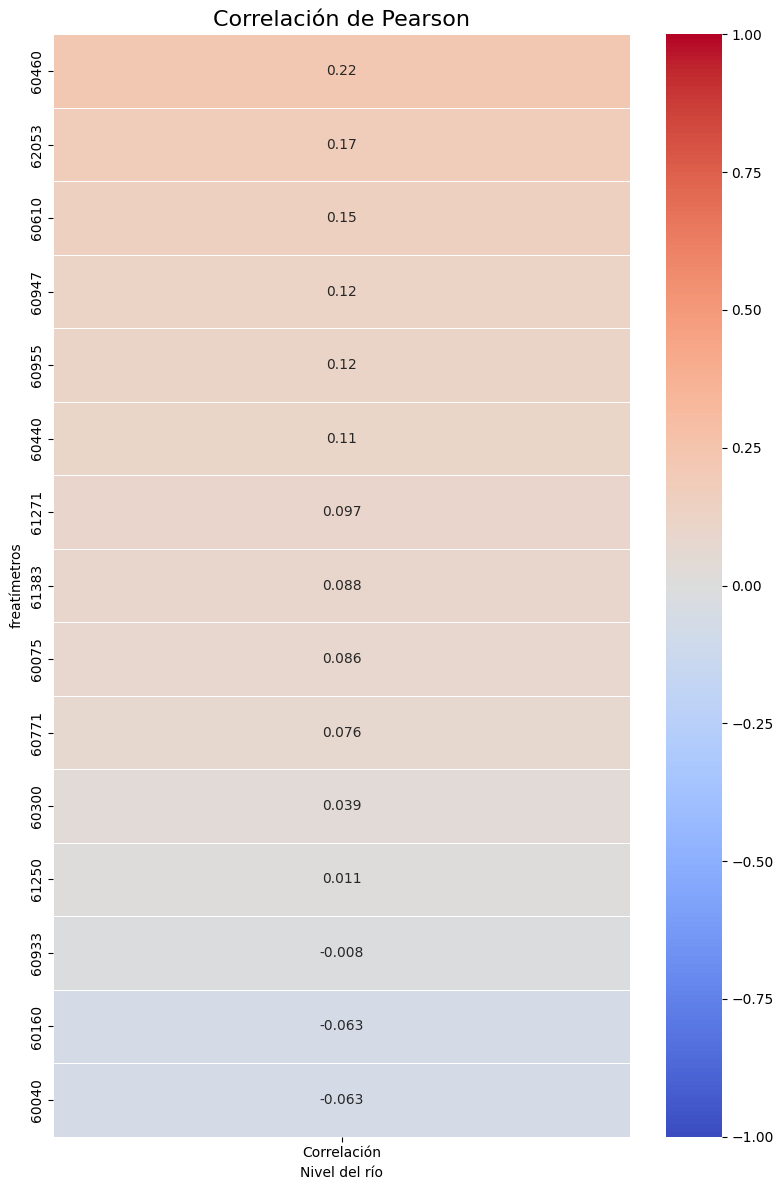

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Pearson
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = nivelRioNegro_caso2['promedio']

# Calcular la correlación de Pearson entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación de Pearson
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': freatimetros_caso2[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Asegurarse de eliminar filas con NaNs

    # Calcular la correlación de Pearson
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = pearsonr(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Pearson', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()

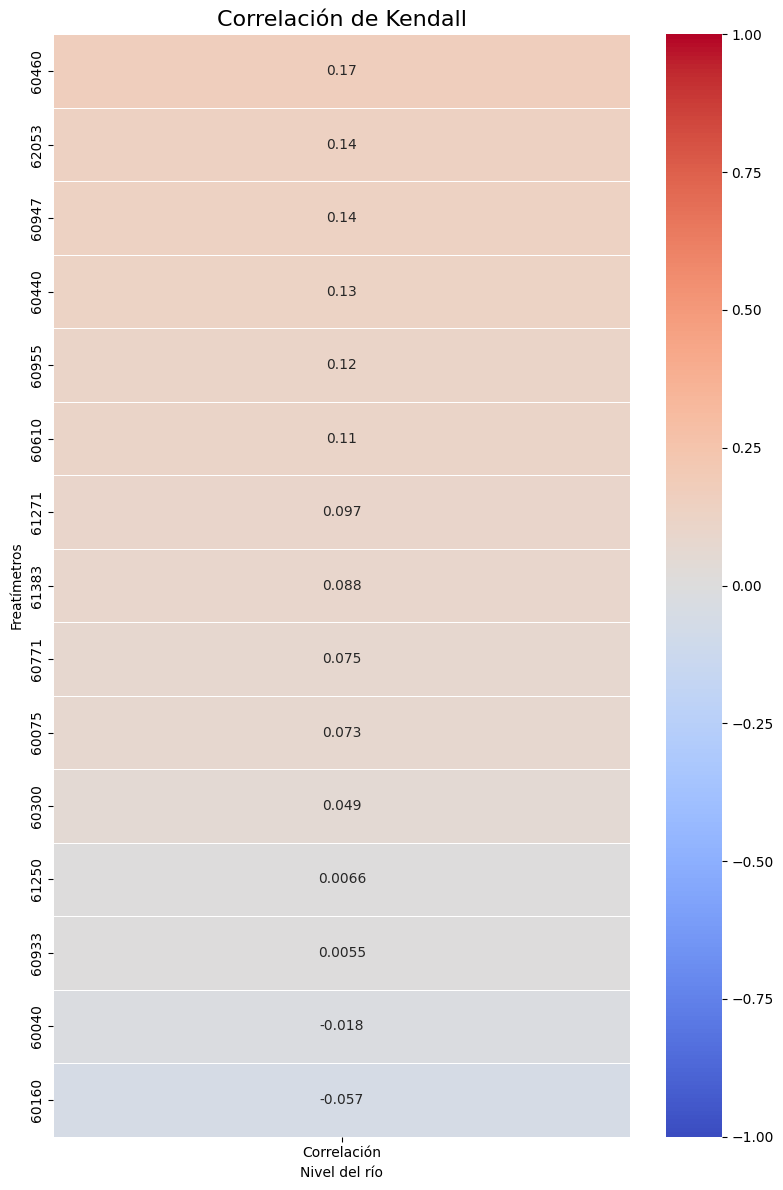

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau  # Cambiamos pearsonr por kendalltau

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Kendall
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = nivelRioNegro_caso2['promedio']

# Calcular la correlación de Kendall entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': freatimetros_caso2[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Eliminar filas con NaNs

    # Calcular la correlación de Kendall
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = kendalltau(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Kendall', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('Freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()


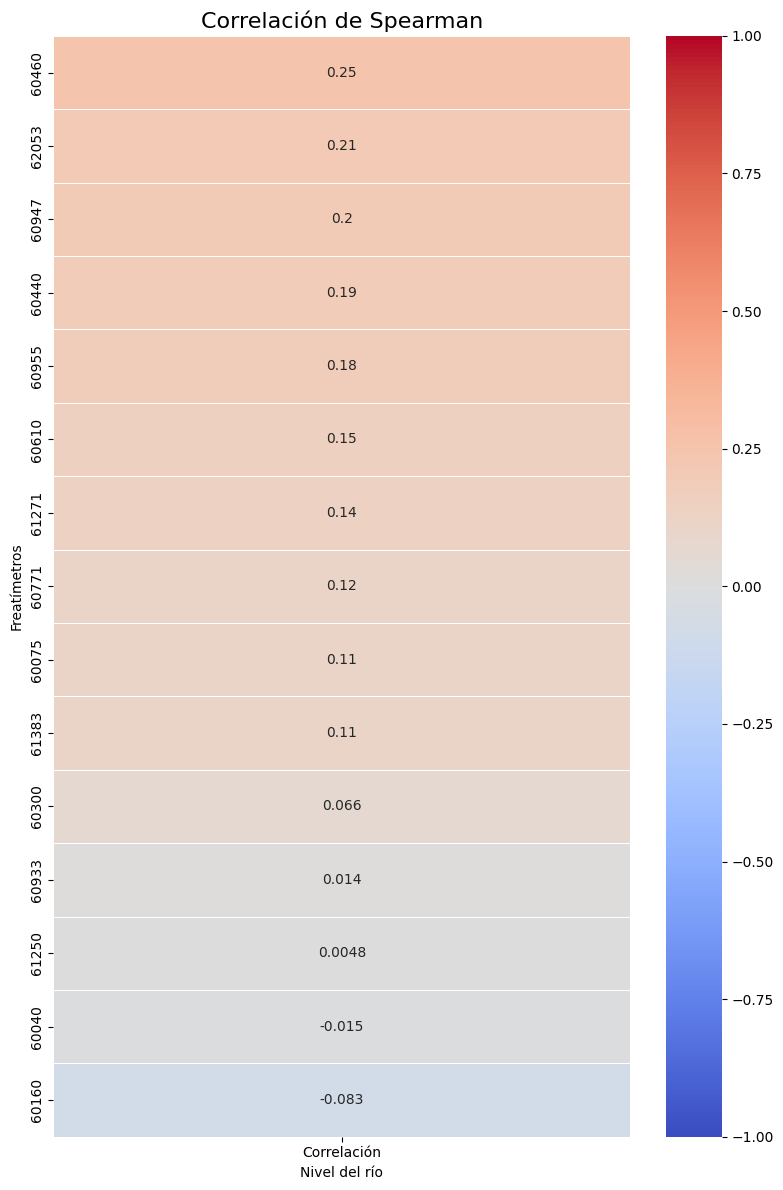

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr  # Cambiamos a spearmanr

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Spearman
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = nivelRioNegro_caso2['promedio']

# Calcular la correlación de Spearman entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': freatimetros_caso2[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Eliminar filas con NaNs

    # Calcular la correlación de Spearman
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = spearmanr(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Spearman', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('Freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()


#Red neuronal Caso 2 Rio-Frea

In [ ]:
import pandas as pd

#este archivo esta en formato long listo para entrenar una red neuronal - entre nivel del rio y freatimetros de Sept a Abril
ruta ='/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/df_merged_freatimetros_nivelRioNegro_long.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
df_merged_freatimetros_nivelRioNegro_long = pd.read_excel(ruta, sheet_name=nombre_pestaña)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ========================================================================
# 1️⃣ **Preprocesamiento: Codificación y Normalización**
# ========================================================================
df = df_merged_freatimetros_nivelRioNegro_long.copy()

# 🔹 **Codificación del ID de freatímetros**
label_encoder = LabelEncoder()
df['freátimetro_id_encoded'] = label_encoder.fit_transform(df['freátimetro_id'])

# 🔹 **Escalar el nivel del río**
scaler_X = StandardScaler()
df['nivelRio_scaled'] = scaler_X.fit_transform(df[['nivelRio']])

# 🔹 **Escalar el nivel freático**
scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])


# ========================================================================
# 2️⃣ **Generación de Secuencias**
# ========================================================================
def create_sequences_per_freatimetro(df, window_size=8):
    """
    Genera secuencias por cada freatímetro sin mezclar datos entre ellos.
    Retorna:
    - X_seq: Matriz (n_muestras, window_size, n_features)
    - y_seq: Valores objetivo correspondientes
    - freatimetros_seq: Lista con los freatímetros correspondientes
    - fechas_seq: Lista con las fechas correspondientes a cada secuencia
    """
    X_seq, y_seq, freatimetros_seq, fechas_seq = [], [], [], []

    for freatimetro_id in df['freátimetro_id_encoded'].unique():
        df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

        X = df_freatimetro[['nivelRio_scaled', 'freátimetro_id_encoded']].values
        y = df_freatimetro['nivel_freatico_scaled'].values
        fechas = df_freatimetro['fecha'].values


        for i in range(len(X) - window_size):
            ventana_X = X[i:i + window_size]
            valor_y = y[i + window_size]
            fecha_prediccion = fechas[i + window_size]
            X_seq.append(ventana_X)
            y_seq.append(valor_y)
            freatimetros_seq.append(freatimetro_id)
            fechas_seq.append(fecha_prediccion)

    return np.array(X_seq), np.array(y_seq), np.array(freatimetros_seq), np.array(fechas_seq)

# 🔹 **Generar secuencias**
X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df, window_size=8)

# ========================================================================
# 3️⃣ **Generar Secuencias por Freatímetro**
# ========================================================================
X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
freatimetros_train_list, freatimetros_test_list = [], []
fechas_train_list, fechas_test_list = [], []

for freatimetro_id in df['freátimetro_id_encoded'].unique():
    df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

    # 🔹 Generar secuencias para este freatímetro
    X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df_freatimetro, window_size=8)

    # 🔹 Dividir en entrenamiento y prueba SOLO para este freatímetro
    train_size = int(len(X_seq) * 0.8)

    X_train_list.append(X_seq[:train_size])
    X_test_list.append(X_seq[train_size:])
    y_train_list.append(y_seq[:train_size])
    y_test_list.append(y_seq[train_size:])
    fechas_train_list.append(fechas_seq[:train_size])
    fechas_test_list.append(fechas_seq[train_size:])
    freatimetros_train_list.append(freatimetros_seq[:train_size])
    freatimetros_test_list.append(freatimetros_seq[train_size:])

# 🔹 Concatenar las listas finales para obtener los conjuntos balanceados
X_train, X_test = np.vstack(X_train_list), np.vstack(X_test_list)
y_train, y_test = np.hstack(y_train_list), np.hstack(y_test_list)
fechas_train, fechas_test = np.hstack(fechas_train_list), np.hstack(fechas_test_list)
freatimetros_train, freatimetros_test = np.hstack(freatimetros_train_list), np.hstack(freatimetros_test_list)




In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

# 🔹 **Compilar el Modelo**
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.5379 - mae: 0.5849 - val_loss: 2.6274 - val_mae: 1.1341
Epoch 2/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0936 - mae: 0.2400 - val_loss: 2.9403 - val_mae: 1.1091
Epoch 3/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0714 - mae: 0.2016 - val_loss: 2.9428 - val_mae: 1.1067
Epoch 4/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0756 - mae: 0.2100 - val_loss: 3.3541 - val_mae: 1.1123
Epoch 5/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0821 - mae: 0.2220 - val_loss: 3.0423 - val_mae: 1.1217
Epoch 6/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0657 - mae: 0.2002 - val_loss: 3.4650 - val_mae: 1.1301
Epoch 7/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0754 - mae: 0.2165 - val_loss: 3.2630 - val_mae: 1.1040
Epoch 8/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0632 - mae: 0.1955 - val_loss: 3.1296 - val_mae: 1.1159
Epoch 9/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - lo

In [ ]:
# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# 🔹 **Generar Predicciones**
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 **Decodificar los IDs de los freatímetros**
freatimetros_test_original = label_encoder.inverse_transform(freatimetros_test)

# 🔹 **Encontrar la última predicción para cada freatímetro**
ultima_prediccion_por_freatimetro = {}
for i in range(len(freatimetros_test_original)):
    freatimetro_id = freatimetros_test_original[i]
    ultima_prediccion_por_freatimetro[freatimetro_id] = (fechas_test[i], y_pred[i][0], y_test_descaled[i][0])

# 🔹 **Mostrar los resultados finales**
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
for freatimetro_id, (fecha, pred, real) in sorted(ultima_prediccion_por_freatimetro.items()):
    print(f"Fecha: {fecha}, Freátimetro ID: {freatimetro_id}, Predicción: {pred:.2f}, Real: {real:.2f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1687 - mae: 0.2199
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step

Loss (MSE): 0.5997, MAE: 0.4019
📌 Última predicción de cada freatímetro:
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60040, Predicción: 191.72, Real: 191.50
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60075, Predicción: 192.36, Real: 192.04
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60160, Predicción: 193.62, Real: 193.54
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60300, Predicción: 195.40, Real: 194.98
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60440, Predicción: 197.27, Real: 196.51
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60460, Predicción: 198.37, Real: 197.08
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60610, Predicción: 199.22, Real: 197.02
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60771, Predicción: 199.92, Real: 199.52
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60933, Predi

In [ ]:
import numpy as np
import pandas as pd
import joblib
from dateutil.relativedelta import relativedelta

def predecir_nivel_freatico(model, df, freatimetro_id, scaler_X, scaler_y):
    """
    Predice el nivel freático para un freatímetro específico basado en los últimos 8 meses de datos.

    Parámetros:
    - model: Modelo LSTM entrenado.
    - df: DataFrame con los datos históricos.
    - freatimetro_id: ID del freatímetro que se desea predecir.
    - scaler_X: Escalador para los datos de entrada.
    - scaler_y: Escalador para los valores de salida (nivel freático).

    Retorna:
    - Fecha de la predicción y nivel freático estimado (msnm).
    """



    # Filtrar los datos del freatímetro específico
    df_freatimetro = df[df["freátimetro_id"] == freatimetro_id]

    # Verificar si hay suficientes datos (8 meses)
    if len(df_freatimetro) < 8:
        print(f"❌ No hay suficientes datos para el freatímetro {freatimetro_id} (se necesitan al menos 8 meses).")
        return None

    # Seleccionar los últimos 8 meses de datos
    ultimo_periodo = df_freatimetro[["fecha", "nivelRio"]].iloc[-8:].copy()

    # Obtener la última fecha y calcular la fecha de predicción
    ultima_fecha = ultimo_periodo["fecha"].iloc[-1]
    fecha_prediccion = ultima_fecha + relativedelta(months=1)

    print(f"🔹 Últimos 8 registros seleccionados para el freatímetro {freatimetro_id}:")
    print(ultimo_periodo)

    # Escalar el nivel del río
    nivelRio_scaled = scaler_X.transform(ultimo_periodo[["nivelRio"]])
     # **Codificar el ID del freatímetro correctamente**
    if freatimetro_id in label_encoder.classes_:
        freatimetro_encoded = label_encoder.transform([freatimetro_id])[0]  # Convertir ID a formato codificado
    else:
        print(f"❌ Error: El freatímetro {freatimetro_id} no está en el LabelEncoder.")
        return None

    freatimetro_encoded_array = np.full((8, 1), freatimetro_encoded)  # Crear array con el mismo valor en los 8 meses

    # Combinar nivel del río escalado con ID codificado
    input_data = np.hstack((nivelRio_scaled, freatimetro_encoded_array))

    # Redimensionar para el modelo LSTM (1 muestra, 8 meses, 2 variables)
    X_pred = np.array([input_data])

    # Realizar la predicción con el modelo LSTM
    y_pred_scaled = model.predict(X_pred)

    # Desescalar la predicción para obtener valores reales de nivel de napa (msnm)
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)[0][0]

    # Mostrar resultado
    print(f"\n📌 Predicción del Nivel Freático para el Freatímetro {freatimetro_id}")
    print(f"📅 Fecha Predicción: {fecha_prediccion.strftime('%Y-%m')}, Nivel Freático: {y_pred_real:.2f} msnm")



    return fecha_prediccion, y_pred_real

# **Ejemplo: Predecir el nivel freático del freatímetro 60040 en enero de 2023**
predecir_nivel_freatico(
    model=model,
    df=df_merged_freatimetros_nivelRioNegro_long,
    freatimetro_id=61383,
    scaler_X=scaler_X,
    scaler_y=scaler_y
)


🔹 Últimos 8 registros seleccionados para el freatímetro 61383:
          fecha    nivelRio
1453 2022-01-01  236.110968
1468 2022-02-01  236.146786
1483 2022-03-01  236.095161
1498 2022-04-01  236.093333
1513 2022-09-01  236.074667
1528 2022-10-01  236.159032
1543 2022-11-01  236.312000
1558 2022-12-01  236.569032
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

📌 Predicción del Nivel Freático para el Freatímetro 61383
📅 Fecha Predicción: 2023-01, Nivel Freático: 201.96 msnm


(Timestamp('2023-01-01 00:00:00'), np.float32(201.96353))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


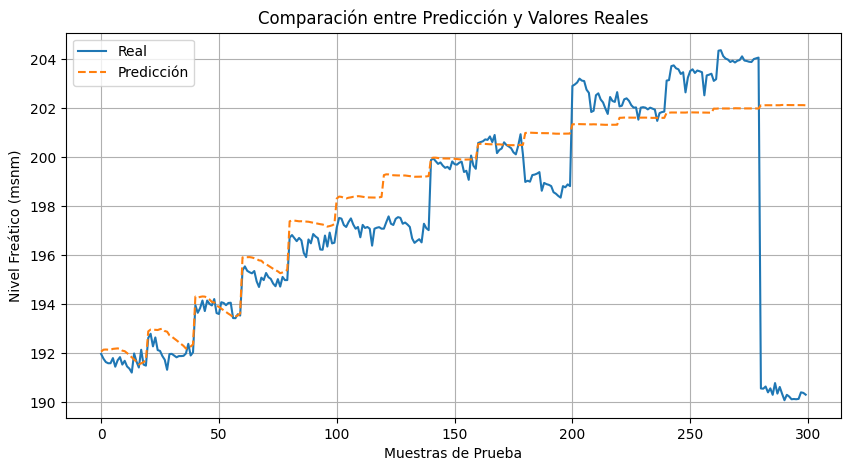

In [ ]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Real", linestyle="-")
plt.plot(y_pred, label="Predicción", linestyle="dashed")
plt.xlabel("Muestras de Prueba")
plt.ylabel("Nivel Freático (msnm)")
plt.title("Comparación entre Predicción y Valores Reales")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_descaled, y_pred)
print(f"🔹 Coeficiente de Determinación R²: {r2:.2f}")

# Obtener el ID codificado de 60040
id_60040_codificado = label_encoder.transform([60040])[0]

print(f"🔹 ID del freatímetro 60040 codificado: {id_60040_codificado}")



🔹 Coeficiente de Determinación R²: 0.42


In [ ]:
# Obtener el ID codificado de 60040
id_60040_codificado = label_encoder.transform([60040])[0]

print(f"🔹 ID del freatímetro 60040 codificado: {id_60040_codificado}")


🔹 ID del freatímetro 60040 codificado: 0


In [ ]:
#no funciona y no se que hace

# Desescalar las predicciones y los valores reales si aún no lo has hecho
y_pred_desescalado = scaler_y.inverse_transform(y_pred_scaled)
y_test_desescalado = scaler_y.inverse_transform(y_test)

ValueError: Expected 2D array, got 1D array instead:
array=[-1.34671814 -1.3929631  -1.42561917 -1.43720263 -1.43669016 -1.38719805
 -1.47053902 -1.40862858 -1.37767336 -1.45000193 -1.41339092 -1.46815785
 -1.48958838 -1.52768711 -1.3419558  -1.42053443 -1.4785341  -1.30623824
 -1.44975839 -1.46010256 -1.1912277  -1.1507478  -1.27333405 -1.18646536
 -1.30941806 -1.31742975 -1.36743433 -1.40315189 -1.50077989 -1.3478778
 -1.34600379 -1.36267199 -1.37934018 -1.36743433 -1.36743433 -1.36505316
 -1.3414708  -1.2483758  -1.36164076 -1.33109748 -0.87334142 -0.94715771
 -0.90184022 -0.82809918 -0.93050117 -0.82809918 -0.86143557 -0.87572259
 -0.81381215 -0.94995596 -0.95906356 -0.84476737 -0.85191088 -0.87334142
 -0.85191088 -0.84952971 -0.99841013 -0.99954346 -0.961068   -0.97400745
 -0.5358466  -0.49664022 -0.53962335 -0.55378832 -0.56397686 -0.54188247
 -0.64189163 -0.69665856 -0.60617407 -0.62978011 -0.56093183 -0.60141173
 -0.61807993 -0.66332217 -0.68951505 -0.6204611  -0.69280792 -0.59

# correlaciones

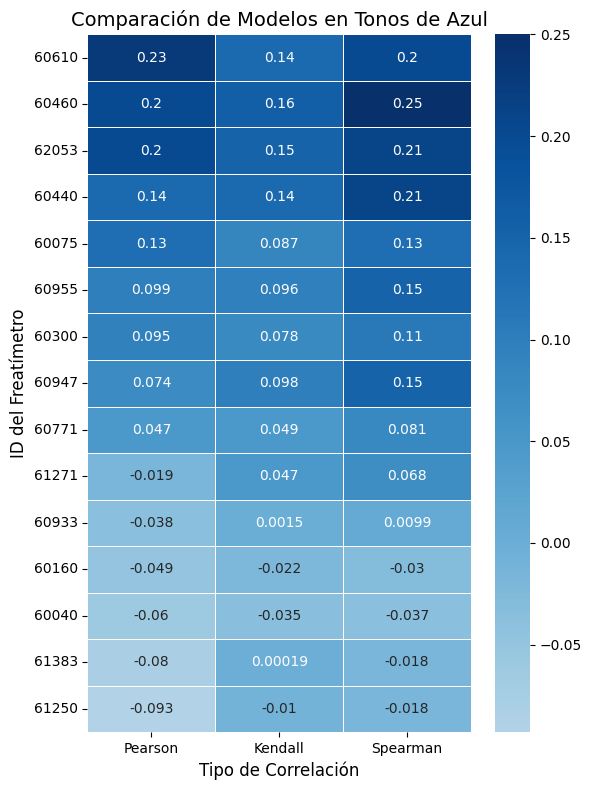

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1) Definir los freatímetros y sus correlaciones en listas (orden: de arriba hacia abajo)
freatimetros = [60610, 60460, 62053, 60440, 60075, 60955, 60300, 60947, 60771,
                61271, 60933, 60160, 60040, 61383, 61250]

pearson = [0.23, 0.20, 0.20, 0.14, 0.13, 0.099, 0.095, 0.074, 0.047,
          -0.019, -0.038, -0.049, -0.06, -0.08, -0.093]

kendall = [0.14, 0.16, 0.15, 0.14, 0.087, 0.096, 0.078, 0.098, 0.049,
           0.047, 0.0015, -0.022,-0.035, 0.00019, -0.01]

spearman = [0.2, 0.25, 0.21, 0.21, 0.13, 0.15, 0.11, 0.15, 0.081,
            0.068, 0.0099, -0.03, -0.037, -0.018, -0.018]

# 2) Construir un DataFrame con columnas para cada tipo de correlación
df_correl = pd.DataFrame({
    'Pearson': pearson,
    'Kendall': kendall,
    'Spearman': spearman
}, index=freatimetros)

# Opcional: ordenar el índice de mayor a menor correlación de Pearson,
# o dejarlo en tu orden preferido
# df_correl = df_correl.sort_values(by='Pearson', ascending=False)

# 3) Crear el mapa de calor (heatmap) con seaborn
plt.figure(figsize=(6, 8))  # Ajusta el tamaño según convenga
sns.heatmap(df_correl,
            cmap='Blues',   # Paleta de tonos azules
            center=0,       # Para que 0 sea el punto medio del degradado
            annot=True,     # Muestra los valores en cada celda
            fmt=".3g",      # Formato numérico (tres dígitos significativos)
            linewidths=0.5, # Separación entre celdas
            cbar=True       # Muestra la barra lateral de colores
           )

plt.title("Comparación de Modelos en Tonos de Azul", fontsize=14)
plt.xlabel("Tipo de Correlación", fontsize=12)
plt.ylabel("ID del Freatímetro", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
archivo_excel = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datasetRedNcaso2.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datasetMerge = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)
print (datasetMerge.head())

   Unnamed: 0.1    nivelRio Year-Month   Temp Out    Hi Temp   Low Temp  \
0             0  236.547742    2010-01  15.519254  15.679427  15.359879   
1             1  236.556429    2010-02  17.161264  17.345704  16.978229   
2             2  236.584839    2010-03  19.292587  19.465814  19.117658   
3             3  236.864667    2010-04  13.971620  14.102917  13.836181   
4             4  236.268333    2010-09  11.697685  11.868727  11.525116   

     Out Hum    Dew Pt.  Wind Speed  Wind Run  ...   60610       60771  \
0  54.647326   4.970003    2.954101  0.493615  ...  198.18  199.617973   
1  50.445964   5.297872    3.642767  0.608535  ...  197.48  199.500000   
2  60.934078  10.547204    3.275745  0.547337  ...  197.18  199.850000   
3  58.846528   5.077569    0.362593  0.060882  ...  197.51  199.520000   
4  50.998148   0.512037    4.098148  0.684007  ...  197.33  199.760000   

        60933       60947       60955       61250       61271       61383  \
0  199.950000  198.883900  

In [ ]:
# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]  # Asegúrate de que esta lista contenga todos los freatímetros que desees incluir.
# Agrega aquí otras variables de interés si lo deseas
#variables_interes = [ 'Temp Out', 'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.',
 #      'Wind Speed', 'Wind Run', 'Hi Speed', 'Bar  ', 'Rain', 'Rain Rate', 'Solar Energy', 'Heat D-D ', 'Cool D-D ', 'In Temp', 'In  Hum',
 #      'In  Dew', 'In  Heat', 'In  ET'
  #     ,]  # Añade tus variables relevantes


#lo cambie a:
variables_interes = ['Dew Pt.','Out Hum', 'Rain Rate']


# Combina las listas
columnas_interes = freatimetros + variables_interes

print(columnas_interes)

[60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053, 'Dew Pt.', 'Out Hum', 'Rain Rate']


['Dew Pt.', 'Out Hum', 'Rain Rate']


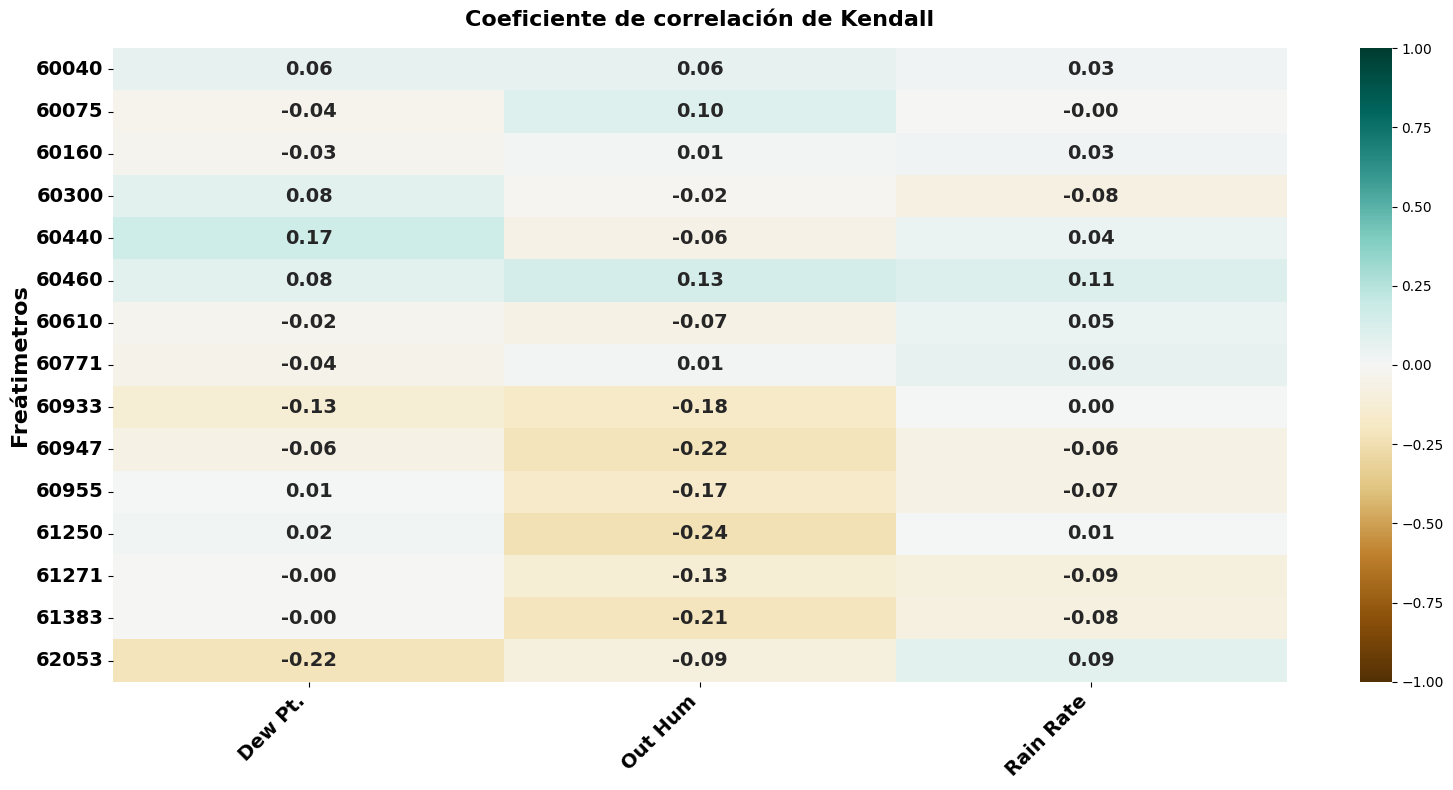

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
aux = datasetMerge[columnas_interes].corr(method='kendall')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

print(climaticas_labels)

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
#variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.2).sum(), axis=0)
#variables_to_keep = variables_to_keep[variables_to_keep > 2].index  # Variables que cumplen la condición



# Filtrar la matriz para las variables climáticas seleccionadas
#filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

# red neuronal con clima... ver de solo usar out hum, dew pt. y rain rate

In [ ]:
import pandas as pd
# Transformar el dataset al formato "long" para incluir todos los freátimetros
# Identificar las columnas de los freátimetros
freatimetro_columns = [60040, 60075, 60160, 60300, 60440, 60460, 60610,
                       60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]
#'In  Dew','Hi Speed'
print(datasetMerge.columns)

# Usar pandas.melt para transformar el dataset
long_data = pd.melt(
    datasetMerge,
    #id_vars=['fecha','In  Hum' ,'Wind Speed', 'Wind Run','Solar Energy'],  # Variables comunes
    #lo cambie yo quiero que las variables sean solo
    #variables_interes = ['Dew Pt.','Out Hum', 'Rain Rate']
    id_vars=['Date','Dew Pt.','Out Hum', 'Rain Rate'],
    value_vars=freatimetro_columns,  # Columnas de freátimetros
    var_name='freátimetro_id',       # Nombre de la columna de identificadores
    value_name='nivel_freatico'      # Valores de los niveles freáticos
)

# Ordenar por fecha para preservar la secuencia temporal
long_data.sort_values(by=['Date', 'freátimetro_id'], inplace=True)
# Verificar el formato de la columna 'fecha'
print(long_data['Date'].dtype)
print(long_data['Date'].head())
long_data = long_data[
    (long_data['Date'].dt.month.isin([1, 2, 3, 4,9,10,11,12])) &
    (long_data['Date'].dt.year.between(2010, 2019))
]

# Revisar el resultado de la transformación
print(long_data.head())

Index([ 'Unnamed: 0.1',      'nivelRio',    'Year-Month',      'Temp Out',
             'Hi Temp',      'Low Temp',       'Out Hum',       'Dew Pt.',
          'Wind Speed',      'Wind Run',      'Hi Speed',    'Wind Chill',
          'Heat Index',     'THW Index',           'Bar',          'Rain',
           'Rain Rate',    'Solar Rad.',  'Solar Energy', 'Hi Solar Rad.',
            'Heat D-D',      'Cool D-D',       'In Temp',        'In Hum',
              'In Dew',       'In Heat',            'ET',     'Wind Samp',
          'ISS Recept',     'Arc. Int.',    'Unnamed: 0',           60040,
                 60075,           60160,           60300,           60440,
                 60460,           60610,           60771,           60933,
                 60947,           60955,           61250,           61271,
                 61383,           62053,          'Date'],
      dtype='object')
datetime64[ns]
0     2010-01-01
77    2010-01-01
154   2010-01-01
231   2010-01-01
308   2010-

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])
long_data['año'] = long_data['Date'].dt.year
long_data['mes'] = long_data['Date'].dt.month
long_data['dia'] = long_data['Date'].dt.day

# Seleccionar las características (X) y el objetivo (y)
#features = ['año','mes', 'dia','In  Hum' ,'Wind Speed', 'Wind Run','Solar Energy','freátimetro_id_encoded']
features = ['año','mes', 'dia','Dew Pt.','Out Hum', 'Rain Rate','freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=False))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.9216 - mae: 0.7982 - val_loss: 0.7281 - val_mae: 0.6549
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6923 - mae: 0.6162 - val_loss: 0.5647 - val_mae: 0.4990
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5642 - mae: 0.4693 - val_loss: 0.5205 - val_mae: 0.4623
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4476 - mae: 0.3943 - val_loss: 0.5264 - val_mae: 0.5139
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4960 - mae: 0.4664 - val_loss: 0.4818 - val_mae: 0.4426
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4725 - mae: 0.4133 - val_loss: 0.4684 - val_mae: 0.4585
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3863 - mae: 0.3786 - val_loss: 0.4470 - val_mae: 0.4430
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4397 - mae: 0.4058 - val_loss: 0.4368 - val_mae: 0.4496
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3804 - mae: 0.

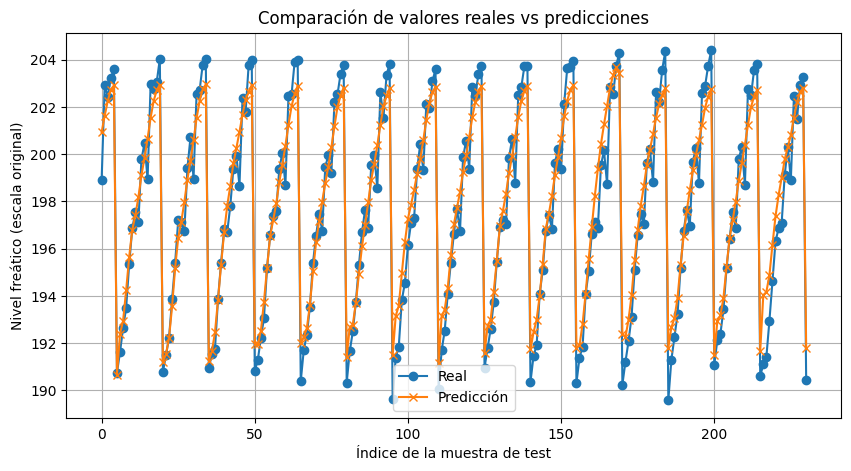

In [ ]:
import matplotlib.pyplot as plt

# EJEMPLO 1: Gráfico sencillo por índice de muestra
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label='Real', marker='o')
plt.plot(y_pred, label='Predicción', marker='x')
plt.title("Comparación de valores reales vs predicciones")
plt.xlabel("Índice de la muestra de test")
plt.ylabel("Nivel freático (escala original)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])

# Seleccionar las características (X) y el objetivo (y)
#features = ['In  Hum' ,'Wind Speed', 'Wind Run','Solar Energy','freátimetro_id_encoded']
features = ['Dew Pt.','Out Hum', 'Rain Rate','freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=False))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.8983 - mae: 0.7753 - val_loss: 0.6485 - val_mae: 0.6192
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6594 - mae: 0.5851 - val_loss: 0.5306 - val_mae: 0.4822
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5316 - mae: 0.4798 - val_loss: 0.5163 - val_mae: 0.4591
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5217 - mae: 0.4772 - val_loss: 0.5043 - val_mae: 0.4198
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5600 - mae: 0.4448 - val_loss: 0.4901 - val_mae: 0.4261
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4441 - mae: 0.4063 - val_loss: 0.4752 - val_mae: 0.4382
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4909 - mae: 0.4266 - val_loss: 0.4687 - val_mae: 0.4430
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5186 - mae: 0.4411 - val_loss: 0.4573 - val_mae: 0.3732
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4212 - mae: 0.3534 - v

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])
long_data['año'] = long_data['Date'].dt.year
long_data['mes'] = long_data['Date'].dt.month
long_data['dia'] = long_data['Date'].dt.day

# Seleccionar las características (X) y el objetivo (y)
#features = ['año', 'mes', 'dia', 'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy', 'freátimetro_id_encoded']
features = ['Dew Pt.','Out Hum', 'Rain Rate','freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.9546 - mae: 0.8185 - val_loss: 0.8073 - val_mae: 0.7152
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7604 - mae: 0.6792 - val_loss: 0.5864 - val_mae: 0.4737
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5958 - mae: 0.4827 - val_loss: 0.5188 - val_mae: 0.4742
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4820 - mae: 0.4540 - val_loss: 0.4929 - val_mae: 0.4468
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5187 - mae: 0.4649 - val_loss: 0.4745 - val_mae: 0.4328
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4342 - mae: 0.4146 - val_loss: 0.4610 - val_mae: 0.3995
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4277 - mae: 0.4158 - val_loss: 0.4631 - val_mae: 0.3651
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4105 - mae: 0.4135 - val_loss: 0.4127 - val_mae: 0.3816
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4869 - mae:

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Loss (MSE): 0.18242761492729187, MAE: 0.2707403600215912
Primeras predicciones vs valores reales con IDs originales:
Freátimetro ID: 60040, Predicción: 200.44, Real: 198.91
Freátimetro ID: 60075, Predicción: 202.08, Real: 202.92
Freátimetro ID: 60160, Predicción: 203.05, Real: 202.44
Freátimetro ID: 60300, Predicción: 201.87, Real: 203.24
Freátimetro ID: 60440, Predicción: 197.72, Real: 203.60


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])
long_data['año'] = long_data['Date'].dt.year
long_data['mes'] = long_data['Date'].dt.month
long_data['dia'] = long_data['Date'].dt.day

# Seleccionar las características (X) y el objetivo (y)
#features = ['año', 'mes', 'dia', 'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy', 'freátimetro_id_encoded']
features = ['Dew Pt.','Out Hum', 'Rain Rate','freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.2, callbacks=[early_stopping], verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.9355 - mae: 0.8022 - val_loss: 0.6648 - val_mae: 0.5962
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.6185 - mae: 0.5409 - val_loss: 0.5226 - val_mae: 0.4642
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4982 - mae: 0.4390 - val_loss: 0.4970 - val_mae: 0.4342
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5220 - mae: 0.4505 - val_loss: 0.4885 - val_mae: 0.4250
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5312 - mae: 0.4552 - val_loss: 0.4810 - val_mae: 0.4016
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5043 - mae: 0.4402 - val_loss: 0.4633 - val_mae: 0.4104
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5182 - mae: 0.4525 - val_loss: 0.4532 - val_mae: 0.4030
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4922 - mae: 0.4453 - val_loss: 0.4289 - val_mae: 0.3939
Epoch 9/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4177 - mae: 0.4094 -

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Loss (MSE): 0.09075014293193817, MAE: 0.2199852019548416
Primeras predicciones vs valores reales con IDs originales:
Freátimetro ID: 60040, Predicción: 199.49, Real: 198.91
Freátimetro ID: 60075, Predicción: 201.26, Real: 202.92
Freátimetro ID: 60160, Predicción: 202.59, Real: 202.44
Freátimetro ID: 60300, Predicción: 202.36, Real: 203.24
Freátimetro ID: 60440, Predicción: 201.00, Real: 203.60


In [ ]:
##no se que hace aca con mes sin y nes con


import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Cargar y preparar datos (asumiendo que long_data es tu DataFrame)
# Mantener copia de IDs originales
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# 2. Ingeniería de características temporales
# Codificación cíclica para el mes
long_data['mes_sin'] = np.sin(2 * np.pi * long_data['mes'] / 12)
long_data['mes_cos'] = np.cos(2 * np.pi * long_data['mes'] / 12)

# Codificar IDs
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])

# 3. Selección de características
features = [
    'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy',
    'mes_sin', 'mes_cos', 'freátimetro_id_encoded'
]
X = long_data[features].values
y = long_data['nivel_freatico'].values

# 4. Creación de ventanas temporales
def create_sequences(data, target, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:i+window_size])
        y_seq.append(target[i+window_size])
    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 6  # Ajustar según análisis de autocorrelación
X_seq, y_seq = create_sequences(X, y, WINDOW_SIZE)

# 5. División de datos manteniendo orden temporal
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    shuffle=False
)

# 6. Escalado (evitando data leakage)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Escalar características usando solo datos de entrenamiento
X_train_shape = X_train.shape
X_train = scaler_X.fit_transform(X_train.reshape(-1, X_train_shape[-1])).reshape(X_train_shape)
X_test = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Escalar target
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# 7. Construcción del modelo LSTM mejorado
model = Sequential([
    LSTM(128,
         input_shape=(WINDOW_SIZE, X_train.shape[2]),
         return_sequences=True,
         dropout=0.2,
         recurrent_dropout=0.2),
    LSTM(64,
         dropout=0.2,
         recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# 8. Entrenamiento con early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 9. Evaluación y predicciones
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Obtener predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 10. Resultados (ajustar índices según ventana)
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("Predicciones vs Valores reales (primeros 5 ejemplos):")
for i in range(5):
    print(f"ID: {freatimetro_ids_original[i + WINDOW_SIZE]} | Pred: {y_pred[i][0]:.2f} | Real: {y_test_descaled[i][0]:.2f}")

NameError: name 'long_data' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# 1. Cargar y preparar datos
# =============================================================================
# Asumiendo que long_data es tu DataFrame con columnas:
# ['fecha', 'In Hum', 'Wind Speed', 'Wind Run', 'Solar Energy', 'freátimetro_id', 'nivel_freatico']

# Mantener copia de IDs originales
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# 2. Ingeniería de características temporales
# =============================================================================
# Codificación cíclica para el mes
long_data['mes'] = long_data['fecha'].dt.month
long_data['mes_sin'] = np.sin(2 * np.pi * long_data['mes'] / 12)
long_data['mes_cos'] = np.cos(2 * np.pi * long_data['mes'] / 12)

# Codificar IDs de freátimetros
label_encoder = LabelEncoder()
long_data['id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])

# 3. Selección de características
# =============================================================================
features = [
    'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy',
    'mes_sin', 'mes_cos', 'id_encoded'
]
target = 'nivel_freatico'

# 4. Función para crear secuencias temporales por freátimetro
# =============================================================================
def create_sequences(data, window_size=4):
    X_seq, y_seq, ids_seq = [], [], []
    for freat_id in data['freátimetro_id'].unique():
        grupo = data[data['freátimetro_id'] == freat_id].sort_values('fecha')
        if len(grupo) < window_size + 1:
            continue  # Saltar freátimetros con pocos datos

        valores = grupo[features].values
        target_vals = grupo[target].values

        for i in range(len(valores) - window_size):
            X_seq.append(valores[i:i+window_size])
            y_seq.append(target_vals[i+window_size])
            ids_seq.append(freat_id)

    return np.array(X_seq), np.array(y_seq), np.array(ids_seq)

# 5. Creación de secuencias y división temporal
# =============================================================================
WINDOW_SIZE = 4  # Ventana de 4 meses
X_seq, y_seq, ids_seq = create_sequences(long_data, WINDOW_SIZE)

# Función para dividir series temporales manteniendo la cronología por freátimetro
def temporal_train_test_split(X, y, ids, test_size=0.2):
    X_train, X_test, y_train, y_test = [], [], [], []

    for freat_id in np.unique(ids):
        mask = (ids == freat_id)
        split_idx = int(np.sum(mask) * (1 - test_size))

        X_train.append(X[mask][:split_idx])
        X_test.append(X[mask][split_idx:])
        y_train.append(y[mask][:split_idx])
        y_test.append(y[mask][split_idx:])

    return (np.concatenate(X_train), np.concatenate(X_test),
            np.concatenate(y_train), np.concatenate(y_test))

# División de datos (80% entrenamiento, 20% prueba por cada freátimetro)
X_train, X_test, y_train, y_test = temporal_train_test_split(X_seq, y_seq, ids_seq)

# 6. Escalado seguro (sin data leakage)
# =============================================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Escalar características
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler_X.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_reshaped).reshape(X_test.shape)

# Escalar target
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# 7. Construcción del modelo LSTM mejorado
# =============================================================================
model = Sequential([
    LSTM(128,
         input_shape=(WINDOW_SIZE, X_train_scaled.shape[2]),
         return_sequences=True,
         dropout=0.2,
         recurrent_dropout=0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# 8. Entrenamiento con early stopping
# =============================================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 9. Evaluación y predicciones
# =============================================================================
# Evaluación en datos de prueba
test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=1)

# Predicciones
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

# 10. Resultados y verificación
# =============================================================================
print(f"\nMSE en test: {test_loss:.4f}, MAE en test: {test_mae:.4f}")

# Verificación de freátimetros en ambos conjuntos
print("\nFreátimetros en entrenamiento:", np.unique(ids_seq[np.isin(ids_seq, np.unique(ids_train))]))
print("Freátimetros en prueba:", np.unique(ids_seq[np.isin(ids_seq, np.unique(ids_test))]))

# Ejemplo de predicciones
print("\nEjemplos de predicción vs real:")
for i in range(5):
    print(f"ID: {ids_test[i]} | Pred: {y_pred[i][0]:.2f} | Real: {y_true[i][0]:.2f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - loss: 0.5457 - mae: 0.6011 - val_loss: 2.7044 - val_mae: 1.1881
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2177 - mae: 0.3250 - val_loss: 2.8621 - val_mae: 1.1790
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2497 - mae: 0.3613 - val_loss: 3.6731 - val_mae: 1.1536
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1735 - mae: 0.2946 - val_loss: 3.2474 - val_mae: 1.1356
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2100 - mae: 0.3082 - val_loss: 3.4740 - val_mae: 1.1352
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1689 - mae: 0.2733 - val_loss: 3.4231 - val_mae: 1.1248
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1828 - mae: 0.2842 - val_loss: 3.4615 - val_mae: 1.1280
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2170 - mae: 0.3066 - val_loss: 3.9178 - val_mae: 1.2251
Epoch 9/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - l

NameError: name 'ids_train' is not defined

In [ ]:
long_data['año'] = long_data['fecha'].dt.year

In [ ]:
import pandas as pd
import numpy as np

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Supongamos que tu DataFrame se llama long_data y ya contiene solo los
# meses de riego (8 meses/año) desde 2010 a 2019.

# Asegúrate de que esté ordenado primero por freátimetro_id y luego por fecha:
long_data = long_data.sort_values(by=['freátimetro_id', 'fecha']).reset_index(drop=True)


In [ ]:
long_data['mes_sin'] = np.sin(2 * np.pi * ((long_data['mes']-1) / 8.0))
long_data['mes_cos'] = np.cos(2 * np.pi * ((long_data['mes']-1) / 8.0))


In [ ]:
features = [ 'año','mes_sin','mes_cos', 'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy']
target = 'nivel_freatico'


In [ ]:
# Extraer la matriz X (features) y y (target), además de los IDs y fechas
X_all = long_data[features].values  # Todas las filas, columnas definidas
y_all = long_data[target].values
freat_ids_all = long_data['freátimetro_id'].values  # para restaurar luego
fechas_all = long_data['fecha'].values

# Escaladores
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Ajustamos los escaladores con TODOS los datos (global)
X_all_scaled = scaler_X.fit_transform(X_all)
y_all_scaled = scaler_y.fit_transform(y_all.reshape(-1, 1)).flatten()
# .flatten() para mantener vector 1D


In [ ]:
def create_sequences_by_id(X, y, ids, fechas, n_steps=3):
    """
    Crea ventanas de largo n_steps para cada freátimetro sin mezclarlos.

    Parámetros:
    -----------
    X: np.ndarray de forma (N, num_features) -- escalado
    y: np.ndarray de forma (N,) -- escalado
    ids: np.ndarray de forma (N,) con el ID del freátimetro
    fechas: np.ndarray de forma (N,) con la fecha
    n_steps: int, tamaño de la ventana temporal

    Retorna:
    --------
    X_seq: np.ndarray de forma (total_muestras, n_steps, num_features)
    y_seq: np.ndarray de forma (total_muestras,)
    ids_seq: np.ndarray de forma (total_muestras,) con el ID correspondiente
    fechas_seq: np.ndarray de forma (total_muestras,) con la última fecha de la ventana (opcional)
    """
    X_seq, y_seq = [], []
    ids_seq = []
    fechas_seq = []

    # Indices únicos de freátimetros en orden
    unique_ids = np.unique(ids)

    for f_id in unique_ids:
        # Extraer las filas correspondientes a este freátimetro
        mask = (ids == f_id)
        X_f = X[mask]
        y_f = y[mask]
        fechas_f = fechas[mask]

        # Crear ventanas para este freátimetro
        for i in range(len(X_f) - n_steps):
            X_seq.append(X_f[i:i+n_steps])
            y_seq.append(y_f[i + n_steps])
            ids_seq.append(f_id)
            # Guardar la fecha "target" como la del paso final
            fechas_seq.append(fechas_f[i + n_steps])

    return (np.array(X_seq),
            np.array(y_seq),
            np.array(ids_seq),
            np.array(fechas_seq))

# Creamos secuencias con n_steps=3 (ejemplo)
n_steps = 10
X_seq, y_seq, ids_seq, fechas_seq = create_sequences_by_id(
    X_all_scaled, y_all_scaled, freat_ids_all, fechas_all, n_steps=n_steps
)

print("Forma de X_seq:", X_seq.shape)   # (muestras_totales, 3, num_features)
print("Forma de y_seq:", y_seq.shape)   # (muestras_totales,)
print("Forma de ids_seq:", ids_seq.shape)
print("Forma de fechas_seq:", fechas_seq.shape)


Forma de X_seq: (1050, 10, 7)
Forma de y_seq: (1050,)
Forma de ids_seq: (1050,)
Forma de fechas_seq: (1050,)


In [ ]:
# OJO: X_seq ya está "concatenado" de todos los IDs en orden de ID y fecha
# Si quieres un split puramente temporal, deberías separar por fecha.
# Aquí, por simplicidad, haremos un 80/20 sin shuffle:

train_size = int(0.8 * len(X_seq))

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]
ids_train = ids_seq[:train_size]
fechas_train = fechas_seq[:train_size]

X_test = X_seq[train_size:]
y_test = y_seq[train_size:]
ids_test = ids_seq[train_size:]
fechas_test = fechas_seq[train_size:]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes :", X_test.shape, y_test.shape)


Train shapes: (840, 10, 7) (840,)
Test shapes : (210, 10, 7) (210,)


In [ ]:
# Definir la arquitectura del modelo
num_features = X_train.shape[2]

model = Sequential()
model.add(
    LSTM(
        units=128,
        input_shape=(n_steps, num_features),
        activation='relu',
        return_sequences=False
    )
)
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# Entrenamos
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,  # 20% de train como validación interna
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 128)                 │          69,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,953 (304.50 KB)

 Trainable params: 77,953 (304.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.5080 - mae: 0.5933 - val_loss: 2.0059 - val_mae: 1.3831
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4785 - mae: 0.5863 - val_loss: 2.1239 - val_mae: 1.4207
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4610 - mae: 0.5761 - val_loss: 2.0731 - val_mae: 1.4024
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4774 - mae: 0.5959 - val_loss: 1.9017 - val_mae: 1.3437
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4866 - mae: 0.5861 - val_loss: 2.0966 - val_mae: 1.4152
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4835 - mae: 0.5978 - val_loss: 1.9535 - val_mae: 1.3601
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4937 - mae: 0.6011 - val_loss: 1.8183 - val_mae: 1.3089
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4845 - mae: 0.5958 - val_loss: 1.9734 - val_mae: 1.3671
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - lo

In [ ]:
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss (MSE escalado): {loss:.4f}, Test MAE escalado: {mae:.4f}")

# Predicciones
y_pred_scaled = model.predict(X_test)
# Desescalar
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6105 - mae: 1.6081 
Test Loss (MSE escalado): 2.5180, Test MAE escalado: 1.5749
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [ ]:
results_df = pd.DataFrame({
    'freátimetro_id': ids_test,
    'fecha': fechas_test,
    'prediccion': y_pred,
    'real': y_test_inv
})

# Ordenar por ID y fecha, si deseas
results_df = results_df.sort_values(by=['freátimetro_id', 'fecha']).reset_index(drop=True)

print(results_df.head(300))


     freátimetro_id      fecha  prediccion        real
0             61271 2011-01-01  196.152588  203.257000
1             61271 2011-02-01  196.271362  202.957000
2             61271 2011-03-01  196.308472  202.707000
3             61271 2011-04-01  196.271118  202.809878
4             61271 2011-09-01  196.177933  202.507000
..              ...        ...         ...         ...
211           62053 2019-04-01  195.907715  190.595000
212           62053 2019-09-01  195.677353  190.445000
213           62053 2019-10-01  195.910965  190.369593
214           62053 2019-11-01  195.902695  190.365000
215           62053 2019-12-01  195.841492  190.325000

[216 rows x 4 columns]


In [ ]:
print(f"\nTest Loss (MSE): {loss}, MAE: {mae}")
print("Primeras 5 predicciones vs valores reales con IDs y fechas:")
for i in range(5):
    print(f"Freátimetro ID: {results_df.loc[i,'freátimetro_id']}, "
          f"Fecha: {results_df.loc[i,'fecha']}, "
          f"Pred: {results_df.loc[i,'prediccion']:.2f}, "
          f"Real: {results_df.loc[i,'real']:.2f}")



Test Loss (MSE): 2.5383877754211426, MAE: 1.5798249244689941
Primeras 5 predicciones vs valores reales con IDs y fechas:
Freátimetro ID: 61271, Fecha: 2011-01-01 00:00:00, Pred: 196.15, Real: 203.26
Freátimetro ID: 61271, Fecha: 2011-02-01 00:00:00, Pred: 196.27, Real: 202.96
Freátimetro ID: 61271, Fecha: 2011-03-01 00:00:00, Pred: 196.31, Real: 202.71
Freátimetro ID: 61271, Fecha: 2011-04-01 00:00:00, Pred: 196.27, Real: 202.81
Freátimetro ID: 61271, Fecha: 2011-09-01 00:00:00, Pred: 196.18, Real: 202.51


In [ ]:
import numpy as np
import pandas as pd

# Scikit-learn para escalado y división de datos
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# TensorFlow / Keras para la red densa
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =======================
# 1) PREPARACIÓN DE DATOS
# =======================

# Asegurarnos de que long_data esté ordenado cronológicamente
long_data = long_data.sort_values(by='fecha').reset_index(drop=True)

# Crear columnas cíclicas para 'mes' y 'dia'
# (Si 'mes' va de 1..12, y 'dia' de 1..31. Ajustar según tus datos.)
long_data['mes_sin'] = np.sin(2 * np.pi * long_data['mes'] / 12.0)
long_data['mes_cos'] = np.cos(2 * np.pi * long_data['mes'] / 12.0)

# Definir las columnas de entrada (features) y la columna objetivo (target)
features = [
    'año',
    'mes_sin', 'mes_cos',
    'In  Hum',
    'Wind Speed',
    'Wind Run',
    'Solar Energy'
]

target = 'nivel_freatico'

# Extraer las matrices/arrays
X_all = long_data[features].values
y_all = long_data[target].values.reshape(-1, 1)  # Como columna 2D

# (Opcional) Guardar columnas extra para analizar resultados después
fechas_all = long_data['fecha'].values
ids_all = long_data['freátimetro_id'].values

# Escalado de características y objetivo
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_all_scaled = scaler_X.fit_transform(X_all)
y_all_scaled = scaler_y.fit_transform(y_all)

# ===========================================
# 2) SEPARACIÓN ENTRE ENTRENAMIENTO Y PRUEBA
# ===========================================
# Usamos un 80/20 sin mezclar (shuffle=False) para respetar orden temporal
X_train, X_test, y_train, y_test = train_test_split(
    X_all_scaled,
    y_all_scaled,
    test_size=0.2,
    shuffle=False
)

# También separamos fechas e IDs para interpretabilidad
fechas_train, fechas_test = train_test_split(
    fechas_all, test_size=0.2, shuffle=False
)
ids_train, ids_test = train_test_split(
    ids_all, test_size=0.2, shuffle=False
)

print("Tamaño de entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño de prueba:", X_test.shape, y_test.shape)

# ================================
# 3) CONSTRUCCIÓN DE LA RED DENSA
# ================================

num_features = X_train.shape[1]  # Número de columnas de entrada

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=num_features))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))  # Salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

# ======================
# 4) ENTRENAMIENTO (FIT)
# ======================

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,  # 20% del set de entrenamiento para validación interna
    verbose=1
)

# =========================
# 5) EVALUACIÓN Y PREDICCIÓN
# =========================

loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest MSE (escalado): {loss:.4f}, Test MAE (escalado): {mae:.4f}")

# Generamos predicciones en el set de prueba
y_pred_scaled = model.predict(X_test)

# Invertir la escala de las predicciones y la del target
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# ========================
# 6) ANÁLISIS DE RESULTADOS
# ========================

# Construir un DataFrame para comparar
results_df = pd.DataFrame({
    'fecha': fechas_test,
    'freátimetro_id': ids_test,
    'prediccion': y_pred.flatten(),
    'real': y_test_real.flatten()
})

# Ordenar para análisis (opcional)
results_df = results_df.sort_values(by=['freátimetro_id', 'fecha']).reset_index(drop=True)

# Mostrar algunas filas
print("\nPrimeras filas de resultados:")
print(results_df.head(10))

# Ejemplo simple de comparación en el test set
for i in range(5):
    print(f"ID: {results_df.loc[i,'freátimetro_id']}, "
          f"Fecha: {results_df.loc[i,'fecha']}, "
          f"Pred: {results_df.loc[i,'prediccion']:.2f}, "
          f"Real: {results_df.loc[i,'real']:.2f}")


Tamaño de entrenamiento: (960, 7) (960, 1)
Tamaño de prueba: (240, 7) (240, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9912 - mae: 0.8462 - val_loss: 1.0463 - val_mae: 0.8675
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9501 - mae: 0.8216 - val_loss: 1.0136 - val_mae: 0.8577
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9911 - mae: 0.8532 - val_loss: 1.0212 - val_mae: 0.8608
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0006 - mae: 0.8508 - val_loss: 1.0308 - val_mae: 0.8636
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9957 - mae: 0.8496 - val_loss: 1.0092 - val_mae: 0.8564
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0143 - mae: 0.8677 - val_loss: 1.0272 - val_mae: 0.8627
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9434 - mae: 0.8198 - val_loss: 1.0184 - val_mae: 0.8601
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0005 - mae: 0.8602 - val_loss: 1.0169 - val_mae: 0.8598
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.000

In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.4 MB/s eta 0:00:00


#con el canal de riego

In [ ]:
import pandas as pd
import numpy as np
import os

# Cargar el archivo CSV en un DataFrame
file_path = "/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datosCanalRiego.csv"
df = pd.read_csv(file_path)

# Convertir columnas numéricas a formato decimal con 2 decimales sin notación científica
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols] = df[numeric_cols].round(2)

# Guardar el DataFrame en un archivo Excel asegurando la correcta conversión de datos numéricos
excel_file_path = "/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datosCanalRiego.xlsx"

with pd.ExcelWriter(excel_file_path, engine='xlsxwriter') as writer:
    df.to_excel(writer, index=False, sheet_name="Muestras")

# Verificar si el archivo se ha guardado correctamente
file_exists = os.path.exists(excel_file_path)

# Devolver la ruta del archivo para su descarga
if file_exists:
    print(f"Archivo Excel guardado en: {excel_file_path}")
else:
    print("Error al guardar el archivo Excel.")

Archivo Excel guardado en: /content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datosCanalRiego.xlsx


In [ ]:
import pandas as pd
import numpy as np
archivo_excel = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datosCanalRiego.xlsx'
nombre_pestaña = 'Muestras'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
caudal_canalRiego = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)
caudal_canalRiego['Caudal'] = caudal_canalRiego['Caudal'].replace(0, np.nan)
print (caudal_canalRiego.head())

      Mes  Mañana  Tarde  Caudal   Año Día Abertura
0  AGOSTO     NaN    NaN     NaN  2009   1      NaN
1  AGOSTO     NaN    NaN     NaN  2009   2      NaN
2  AGOSTO     NaN    NaN     NaN  2009   3      NaN
3  AGOSTO     NaN    NaN     NaN  2009   4      NaN
4  AGOSTO     NaN    NaN     NaN  2009   5      NaN


In [ ]:
nulos_columna = caudal_canalRiego['Caudal'].isnull().sum() +  (caudal_canalRiego['Caudal'] == 0).sum()

print(f" tiene {nulos_columna} valores nulos o 0.")

 tiene 1046 valores nulos o 0.


In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# Cargar el dataset
caudal_canalRiego.columns = caudal_canalRiego.columns.str.strip()

# Seleccionar solo las columnas relevantes (Caudal y otras numéricas)
columnas_numericas = caudal_canalRiego.select_dtypes(include=['number']).columns
df_numerico = caudal_canalRiego[columnas_numericas]

# Aplicar KNNImputer
imputer = KNNImputer(n_neighbors=5)  # Puedes ajustar el número de vecinos
df_imputado = pd.DataFrame(imputer.fit_transform(df_numerico), columns=df_numerico.columns)

# Reemplazar la columna Caudal en el dataset original
caudal_canalRiego['Caudal'] = df_imputado['Caudal']

# Guardar el dataset imputado (opcional)
caudal_canalRiego.to_csv('caudal_canalRiego_imputado.csv', index=False)

print(caudal_canalRiego)


         Mes  Mañana  Tarde     Caudal   Año Día Abertura
0     AGOSTO     NaN    NaN  11088.550  2009   1      NaN
1     AGOSTO     NaN    NaN  11088.550  2009   2      NaN
2     AGOSTO     NaN    NaN  11088.550  2009   3      NaN
3     AGOSTO     NaN    NaN  11088.550  2009   4      NaN
4     AGOSTO     NaN    NaN  11088.550  2009   5      NaN
...      ...     ...    ...        ...   ...  ..      ...
3696   ABRIL     NaN    NaN  14396.738  2020  26      NaN
3697   ABRIL     NaN    NaN  14396.738  2020  27      NaN
3698   ABRIL     NaN    NaN  14396.738  2020  28      NaN
3699   ABRIL     NaN    NaN  14396.738  2020  29      NaN
3700   ABRIL     NaN    NaN  14396.738  2020  30      NaN

[3701 rows x 7 columns]


In [ ]:
nulos_columna = caudal_canalRiego['Caudal'].isnull().sum() +  (caudal_canalRiego['Caudal'] == 0).sum()

print(f" tiene {nulos_columna} valores nulos o 0.")

 tiene 0 valores nulos o 0.


In [ ]:
import pandas as pd

# Diccionario para convertir nombres de meses a números
meses_dict = {
    'ENERO': 1, 'FEB': 2, 'MAR': 3, 'ABRIL': 4,'SEPT': 9, 'OCT.': 10, 'NOV.': 11, 'DIC.': 12}

# Cargar el archivo
df = caudal_canalRiego

# Convertir la columna "Mes" a string, eliminar espacios y poner en mayúsculas
df['Mes'] = df['Mes'].astype(str).str.strip().str.upper()

# Reemplazar nombres de meses por números si existen en el diccionario
df['Mes'] = df['Mes'].replace(meses_dict)

# Convertir "Mes" y "Año" a numérico (evitando errores con `errors='coerce'`)
df['Mes'] = pd.to_numeric(df['Mes'], errors='coerce')
df['Año'] = pd.to_numeric(df['Año'], errors='coerce')

# Revisar si hay valores NaN en Mes o Año
print("Valores nulos en Mes:", df['Mes'].isnull().sum())
print("Valores nulos en Año:", df['Año'].isnull().sum())

# Eliminar filas con Mes o Año nulos (si es necesario)
df = df.dropna(subset=['Mes', 'Año'])

# Convertir a enteros después de eliminar los NaN
df['Mes'] = df['Mes'].astype(int)
df['Año'] = df['Año'].astype(int)

# Crear la columna de Fecha con el día 01
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes'].astype(str) + '-01')

# Calcular el promedio mensual de 'Caudal'
df_promedio_mensual_canal = df.groupby(['Año', 'Mes'], as_index=False)['Caudal'].mean()

# Agregar la columna de Fecha en el dataset resultante
df_promedio_mensual_canal['Fecha'] = pd.to_datetime(df_promedio_mensual_canal['Año'].astype(str) + '-' + df_promedio_mensual_canal['Mes'].astype(str) + '-01')

# Mostrar los resultados
print(df_promedio_mensual_canal)


Valores nulos en Mes: 372
Valores nulos en Año: 0
     Año  Mes        Caudal      Fecha
0   2009    1  15202.404909 2009-01-01
1   2009    2  13864.845152 2009-02-01
2   2009    3  12016.092788 2009-03-01
3   2009    4  14043.167636 2009-04-01
4   2009    9  11133.281935 2009-09-01
..   ...  ...           ...        ...
91  2020    4  13929.699133 2020-04-01
92  2020    9  11443.086452 2020-09-01
93  2020   10  15394.483871 2020-10-01
94  2020   11  15523.304129 2020-11-01
95  2020   12  15593.946065 2020-12-01

[96 rows x 4 columns]


/tmp/ipython-input-1958604025.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Mes'] = df['Mes'].astype(int)
/tmp/ipython-input-1958604025.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Año'] = df['Año'].astype(int)
/tmp/ipython-input-1958604025.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 3.5 MB/s eta 0:00:00


In [ ]:
import os
excel_file_path = "/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/df_promedio_mensual_canal.xlsx"

with pd.ExcelWriter(excel_file_path, engine='xlsxwriter') as writer:
    df_promedio_mensual_canal.to_excel(writer, index=False, sheet_name="Muestras")

# Verificar si el archivo se ha guardado correctamente
file_exists = os.path.exists(excel_file_path)

# Devolver la ruta del archivo para su descarga
if file_exists:
    print(f"Archivo Excel guardado en: {excel_file_path}")
else:
    print("Error al guardar el archivo Excel.")

Archivo Excel guardado en: /content/drive/MyDrive/tesisWalterDatos/preparedDatasets/df_promedio_mensual_canal.xlsx


In [ ]:
print(freatimetros_caso2)

     Unnamed: 0      fecha       60040       60075       60160       60300  \
0             0 2010-01-01  191.432000  192.015000  194.180000  195.252000   
1             1 2010-02-01  191.522000  191.985000  194.070000  195.132000   
2             2 2010-03-01  191.712000  192.555000  193.889057  195.252000   
3             3 2010-04-01  191.592000  192.535000  193.450000  195.752000   
8             8 2010-09-01  191.562000  191.815000  193.499619  194.282000   
..          ...        ...         ...         ...         ...         ...   
159         159 2023-04-01  192.112000  192.485000  193.010000  195.172000   
164         164 2023-09-01  191.442797  191.945069  193.571538  194.940253   
165         165 2023-10-01  191.713456  192.381188  193.911607  195.347290   
166         166 2023-11-01  191.132000  192.195000  193.890000  194.822000   
167         167 2023-12-01  191.647745  192.354045  193.965817  195.395100   

          60440    60460   60610       60771       60933       

In [ ]:
import pandas as pd
import numpy as np
archivo_excel = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/df_promedio_mensual_canal.xlsx'
nombre_pestaña = 'Muestras'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
df_promedio_mensual_canal = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)

In [ ]:

print(freatimetros_caso2.columns)

# Asegurar que la columna de fecha esté en formato datetime
df_promedio_mensual_canal["Fecha"] = pd.to_datetime(df_promedio_mensual_canal["Fecha"])
#freatimetros_caso2["index"] = pd.to_datetime(freatimetros_caso2["index"])
#cambie por fecha
freatimetros_caso2["fecha"] = pd.to_datetime(freatimetros_caso2["fecha"])

# Realizar la unión tipo INNER JOIN con columnas diferentes
merged_df2 = pd.merge(df_promedio_mensual_canal, freatimetros_caso2,
                     left_on="Fecha", right_on="fecha", how="inner")

# Opcional: eliminar la columna duplicada si no se necesita
merged_df2.drop(columns=["fecha"], inplace=True)

# Mostrar las primeras filas del DataFrame resultante
print(merged_df2.head())

Index(['Unnamed: 0',      'fecha',        60040,        60075,        60160,
              60300,        60440,        60460,        60610,        60771,
              60933,        60947,        60955,        61250,        61271,
              61383,        62053],
      dtype='object')
    Año  Mes        Caudal      Fecha  Unnamed: 0    60040    60075  \
0  2010    1  15283.717030 2010-01-01           0  191.432  192.015   
1  2010    2  14899.375152 2010-02-01           1  191.522  191.985   
2  2010    3  11753.783214 2010-03-01           2  191.712  192.555   
3  2010    4  11126.641879 2010-04-01           3  191.592  192.535   
4  2010    9  12105.726387 2010-09-01           8  191.562  191.815   

        60160    60300   60440    60460   60610       60771       60933  \
0  194.180000  195.252  197.18  197.338  198.18  199.617973  199.950000   
1  194.070000  195.132  196.62  197.308  197.48  199.500000  200.330000   
2  193.889057  195.252  196.58  197.268  197.18  199.850000

/tmp/ipython-input-2682787771.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freatimetros_caso2["fecha"] = pd.to_datetime(freatimetros_caso2["fecha"])


In [ ]:
import os
excel_file_path = "/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/merged_df2.xlsx"

with pd.ExcelWriter(excel_file_path, engine='xlsxwriter') as writer:
    merged_df2.to_excel(writer, index=False, sheet_name="Muestras")

# Verificar si el archivo se ha guardado correctamente
file_exists = os.path.exists(excel_file_path)

# Devolver la ruta del archivo para su descarga
if file_exists:
    print(f"Archivo Excel guardado en: {excel_file_path}")
else:
    print("Error al guardar el archivo Excel.")

Archivo Excel guardado en: /content/drive/MyDrive/tesisWalterDatos/preparedDatasets/merged_df2.xlsx


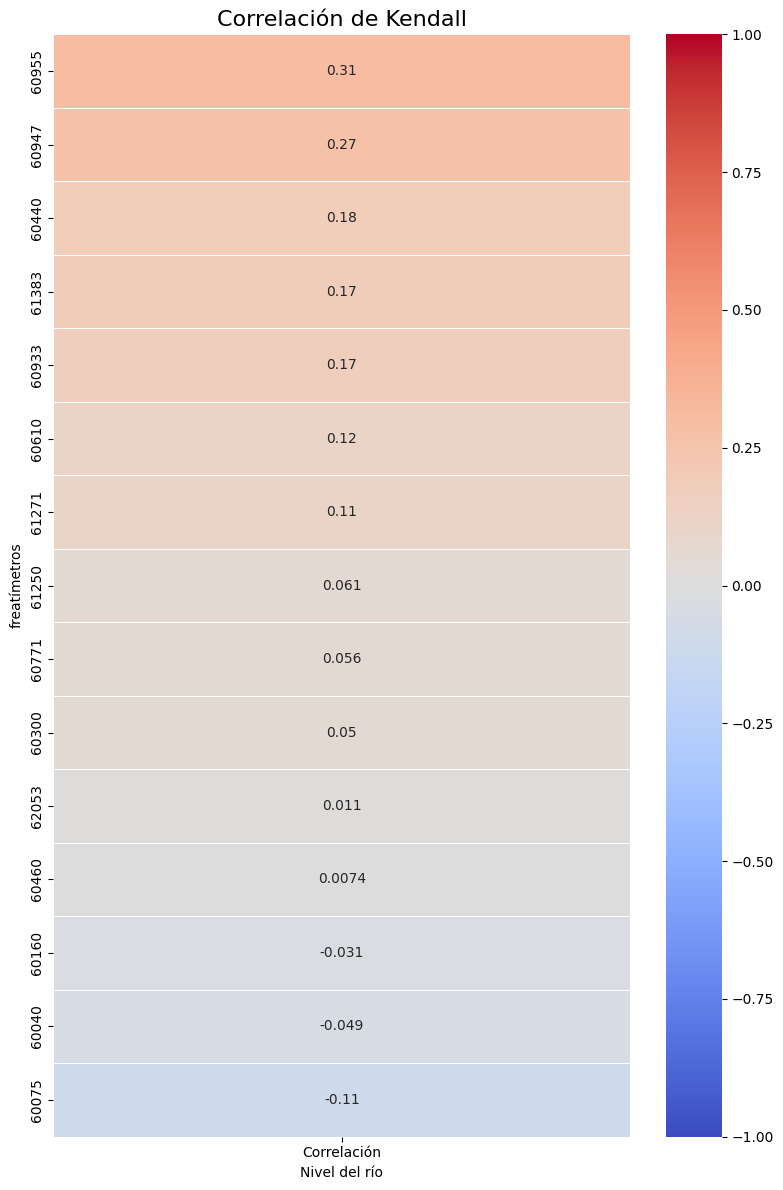

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Pearson
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = merged_df2['Caudal']

# Calcular la correlación de Pearson entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación de Pearson
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': merged_df2[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Asegurarse de eliminar filas con NaNs

    # Calcular la correlación de Pearson
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = kendalltau(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Kendall', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Crear los datos de correlación
data = {
    "Freatímetro": [
        "62053", "60610", "60460", "61250", "60160", "60955",
        "60075", "60933", "60771", "60947", "60440",
        "61271", "60300", "61383", "60040"
    ],
    "Pearson": [0.61, 0.41, 0.37, 0.33, 0.32, 0.27, 0.23, 0.2, 0.19, 0.15, 0.14, 0.048, -0.0068, -0.03, -0.094],
    "Spearman": [0.60, 0.45, 0.38, 0.37, 0.31, 0.27, 0.24, 0.27, 0.17, 0.14, 0.14, 0.024, 0.0038, -0.061, -0.08],
    "Kendall": [0.43, 0.32, 0.28, 0.26, 0.21, 0.2, 0.19, 0.16, 0.12, 0.087, 0.089, 0.027, 0.011, -0.051, -0.022]
}

# Crear el DataFrame
df_correlaciones = pd.DataFrame(data)

# Mostrar la tabla
print(df_correlaciones)


   Freatímetro  Pearson  Spearman  Kendall
0        62053   0.6100    0.6000    0.430
1        60610   0.4100    0.4500    0.320
2        60460   0.3700    0.3800    0.280
3        61250   0.3300    0.3700    0.260
4        60160   0.3200    0.3100    0.210
5        60955   0.2700    0.2700    0.200
6        60075   0.2300    0.2400    0.190
7        60933   0.2000    0.2700    0.160
8        60771   0.1900    0.1700    0.120
9        60947   0.1500    0.1400    0.087
10       60440   0.1400    0.1400    0.089
11       61271   0.0480    0.0240    0.027
12       60300  -0.0068    0.0038    0.011
13       61383  -0.0300   -0.0610   -0.051
14       60040  -0.0940   -0.0800   -0.022


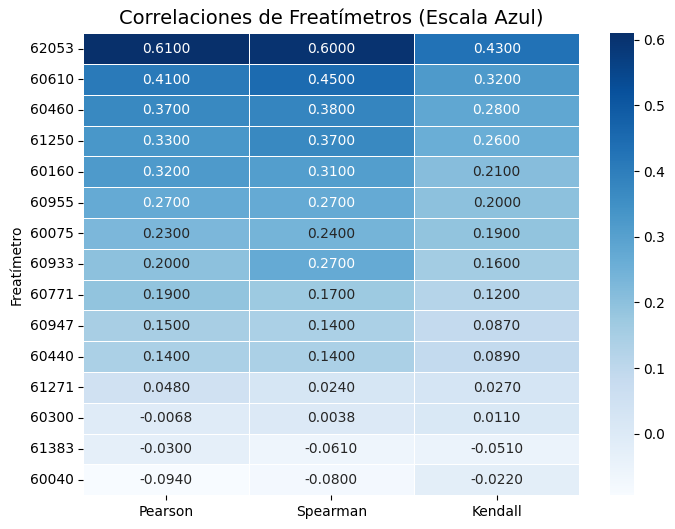

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear los datos de correlación
data = {
    "Freatímetro": [
        "62053", "60610", "60460", "61250", "60160", "60955",
        "60075", "60933", "60771", "60947", "60440",
        "61271", "60300", "61383", "60040"
    ],
    "Pearson": [0.61, 0.41, 0.37, 0.33, 0.32, 0.27, 0.23, 0.2, 0.19, 0.15, 0.14, 0.048, -0.0068, -0.03, -0.094],
    "Spearman": [0.60, 0.45, 0.38, 0.37, 0.31, 0.27, 0.24, 0.27, 0.17, 0.14, 0.14, 0.024, 0.0038, -0.061, -0.08],
    "Kendall": [0.43, 0.32, 0.28, 0.26, 0.21, 0.2, 0.19, 0.16, 0.12, 0.087, 0.089, 0.027, 0.011, -0.051, -0.022]
}

# Crear el DataFrame
df_correlaciones = pd.DataFrame(data).set_index("Freatímetro")

# Crear la figura
fig, ax = plt.subplots(figsize=(8, 6))

# Generar el heatmap con escala de colores en azul
sns.heatmap(df_correlaciones, cmap="Blues", annot=True, fmt=".4f", linewidths=0.5, ax=ax)

# Configurar el título
ax.set_title("Correlaciones de Freatímetros (Escala Azul)", fontsize=14)

# Mostrar la tabla visualmente
plt.show()


In [ ]:
import pandas as pd

# Crear la tabla de distancia basada en la imagen
data_distancia = {
    "Freatímetro": [
        "62053", "60075", "60610", "61250", "61383", "60460",
        "60933", "60947", "60040", "60440", "60300", "60771",
        "60955", "60160", "61271"
    ],
    "Distancia": [250, 350, 400, 600, 600, 700, 900, 1200, 1350, 1550, 1600, 1900, 1900, 2000, 2000]
}

# Crear el DataFrame de distancia
df_distancia = pd.DataFrame(data_distancia)

# Crear los datos de correlación de Pearson
data_pearson = {
    "Freatímetro": [
        "62053", "60610", "60460", "61250", "60160", "60955",
        "60075", "60933", "60771", "60947", "60440",
        "61271", "60300", "61383", "60040"
    ],
    "Pearson": [0.61, 0.41, 0.37, 0.33, 0.32, 0.27, 0.23, 0.2, 0.19, 0.15, 0.14, 0.048, -0.0068, -0.03, -0.094]
}

# Crear el DataFrame de correlación
df_pearson = pd.DataFrame(data_pearson)

# Unir la tabla de correlaciones con la tabla de distancia usando la columna "Freatímetro"
df_merged = pd.merge(df_pearson, df_distancia, on="Freatímetro", how="inner")

# Ordenar por distancia de menor a mayor
df_merged = df_merged.sort_values(by="Distancia", ascending=True).reset_index(drop=True)

# Categorizar la correlación en colores
def categorizar_correlacion(valor):
    if valor >= 0.5:
        return "Verde"  # Fuerte
    elif 0.2 <= valor < 0.5:
        return "Amarillo"  # Moderada
    else:
        return "Rojo"  # Débil

df_merged["Categoría"] = df_merged["Pearson"].apply(categorizar_correlacion)

# Mostrar la tabla resultante
print(df_merged)


   Freatímetro  Pearson  Distancia Categoría
0        62053   0.6100        250     Verde
1        60075   0.2300        350  Amarillo
2        60610   0.4100        400  Amarillo
3        61250   0.3300        600  Amarillo
4        61383  -0.0300        600      Rojo
5        60460   0.3700        700  Amarillo
6        60933   0.2000        900  Amarillo
7        60947   0.1500       1200      Rojo
8        60040  -0.0940       1350      Rojo
9        60440   0.1400       1550      Rojo
10       60300  -0.0068       1600      Rojo
11       60955   0.2700       1900  Amarillo
12       60771   0.1900       1900      Rojo
13       60160   0.3200       2000  Amarillo
14       61271   0.0480       2000      Rojo


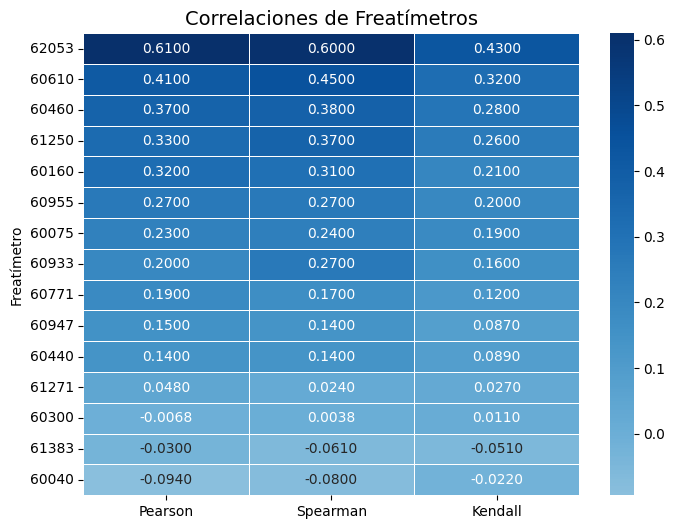

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el DataFrame con los datos proporcionados
df_correlaciones = pd.DataFrame({
    "Freatímetro": [
        "62053", "60610", "60460", "61250", "60160", "60955",
        "60075", "60933", "60771", "60947", "60440",
        "61271", "60300", "61383", "60040"
    ],
    "Pearson": [0.61, 0.41, 0.37, 0.33, 0.32, 0.27, 0.23, 0.2, 0.19, 0.15, 0.14, 0.048, -0.0068, -0.03, -0.094],
    "Spearman": [0.60, 0.45, 0.38, 0.37, 0.31, 0.27, 0.24, 0.27, 0.17, 0.14, 0.14, 0.024, 0.0038, -0.061, -0.08],
    "Kendall": [0.43, 0.32, 0.28, 0.26, 0.21, 0.2, 0.19, 0.16, 0.12, 0.087, 0.089, 0.027, 0.011, -0.051, -0.022]
})

# Crear una visualización en tabla con formato de colores
fig, ax = plt.subplots(figsize=(8, 6))

# Crear el heatmap con escala de azul para valores cercanos a 1 y -1, sin color para valores cercanos a 0
sns.heatmap(df_correlaciones.set_index("Freatímetro"), cmap="Blues", annot=True, fmt=".4f", linewidths=0.5, ax=ax, center=0)

# Configurar el título
ax.set_title("Correlaciones de Freatímetros", fontsize=14)

# Mostrar la tabla visualmente
plt.show()


# clima 2010-2022


In [ ]:
import pandas as pd
ruta_nivel_rio = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/nivelRioNegro_mensual_2010_2023.xlsx'
ruta_freatimetros = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
ruta_clima = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/clima_completo_2009_2022_imputado.xlsx'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosClima = pd.read_excel(ruta_clima, sheet_name=nombre_pestaña)
# Leer el archivo Excel y cargar la pestaña en un DataFrame
FreatimetrosImputados = pd.read_excel(ruta_freatimetros, sheet_name=nombre_pestaña)
nivelRioNegro_mensual_2010_2023 = pd.read_excel(ruta_nivel_rio, sheet_name=nombre_pestaña)

In [ ]:
datosClima['Date'] = pd.to_datetime(datosClima['Year-Month'])
datosClima['Date'] = pd.to_datetime(datosClima['Date'])



In [ ]:
# Filtrar datos para el DataFrame DF
filtro_DF = (FreatimetrosImputados['fecha'].dt.year >= 2010) & (FreatimetrosImputados['fecha'].dt.year <= 2022) & (FreatimetrosImputados['fecha'].dt.month.isin([9,10,11,12,1,2,3,4]))
freatimetros_caso2 = FreatimetrosImputados[filtro_DF]

# Filtrar datos para el DataFrame promediosAlturaRoca_df
filtro_promedios = (nivelRioNegro_mensual_2010_2023['Date'].dt.year >= 2010) & (nivelRioNegro_mensual_2010_2023['Date'].dt.year <= 2022) & (nivelRioNegro_mensual_2010_2023['Date'].dt.month.isin([9,10,11,12,1,2,3,4]))
nivelRioNegro_caso2 = nivelRioNegro_mensual_2010_2023[filtro_promedios]


filtro_datosClima_caso2 =(datosClima['Date'].dt.month.isin([9,10,11,12,1,2,3,4]))
datosClima_caso2 = datosClima[filtro_datosClima_caso2]

In [ ]:
print(datosClima_caso2)

     Rain Rate    Out Hum        ET    Dew Pt.       Date Year-Month
2     0.000000  52.203241  0.021593  -0.142037 2009-09-01    2009-09
3     0.000000  41.810260  0.033134   0.591174 2009-10-01    2009-10
4     0.013333  41.456834  0.039477   2.135473 2009-11-01    2009-11
5     0.020843  45.891342  0.040849   6.875381 2009-12-01    2009-12
6     0.305193  54.647326  0.023448   4.970003 2010-01-01    2010-01
..         ...        ...       ...        ...        ...        ...
150   0.838710  51.222481  4.924194  11.613441 2022-01-01    2022-01
151   2.742857  57.351935  4.208571  11.061335 2022-02-01    2022-02
152   0.032258  56.929584  3.448710   7.277081 2022-03-01    2022-03
153   1.066667  62.521296  2.404333   5.315272 2022-04-01    2022-04
158   0.613333  53.444919  2.788000   1.883313 2022-09-01    2022-09

[105 rows x 6 columns]


In [ ]:
import pandas as pd

# Cargar los tres archivos filtrados
df_clima = datosClima_caso2
df_freatimetros = freatimetros_caso2
df_rio = nivelRioNegro_caso2

# Asegurarse que las columnas Date estén en datetime
df_clima['Date'] = pd.to_datetime(df_clima['Date'])
df_freatimetros['Date'] = pd.to_datetime(df_freatimetros['fecha'])
df_rio['Date'] = pd.to_datetime(df_rio['Date'])

# Unir los tres DataFrames por la columna Date
# Usamos INNER JOIN para quedarnos solo con fechas comunes
df_unificado = df_clima.merge(df_freatimetros, on='Date', how='inner')
df_unificado = df_unificado.merge(df_rio[['Date', 'promedio']], on='Date', how='inner')

# Ordenar por fecha
df_unificado.sort_values('Date', inplace=True)
df_unificado = df_unificado.rename(columns={'promedio': 'nivelRio'})

df_unificado.to_excel('/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/clima_caso2_h3.xlsx')

print(df_unificado)

     Rain Rate    Out Hum        ET    Dew Pt.       Date Year-Month  \
0     0.305193  54.647326  0.023448   4.970003 2010-01-01    2010-01   
1     2.373873  50.445964  0.031365   5.297872 2010-02-01    2010-02   
2     0.370062  60.934078  0.025841  10.547204 2010-03-01    2010-03   
3     0.025579  58.846528  0.000030   5.077569 2010-04-01    2010-04   
4     0.174028  50.998148  0.021940   0.512037 2010-09-01    2010-09   
..         ...        ...       ...        ...        ...        ...   
96    0.838710  51.222481  4.924194  11.613441 2022-01-01    2022-01   
97    2.742857  57.351935  4.208571  11.061335 2022-02-01    2022-02   
98    0.032258  56.929584  3.448710   7.277081 2022-03-01    2022-03   
99    1.066667  62.521296  2.404333   5.315272 2022-04-01    2022-04   
100   0.613333  53.444919  2.788000   1.883313 2022-09-01    2022-09   

     Unnamed: 0      fecha       60040       60075  ...   60610       60771  \
0             0 2010-01-01  191.432000  192.015000  ... 

/tmp/ipython-input-3344889433.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clima['Date'] = pd.to_datetime(df_clima['Date'])
/tmp/ipython-input-3344889433.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freatimetros['Date'] = pd.to_datetime(df_freatimetros['fecha'])
/tmp/ipython-input-3344889433.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

In [ ]:
ruta_clima = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/clima_caso2_h3.xlsx'
nombre_pestaña = 'Sheet1'
clima_caso2_h3 = pd.read_excel(ruta_clima, sheet_name=nombre_pestaña)

In [ ]:
# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

variables_interes = ['Out Hum', 'Dew Pt.',
       'Rain Rate'
       ]  # Añade tus variables relevantes



# Combina las listas
columnas_interes = freatimetros + variables_interes

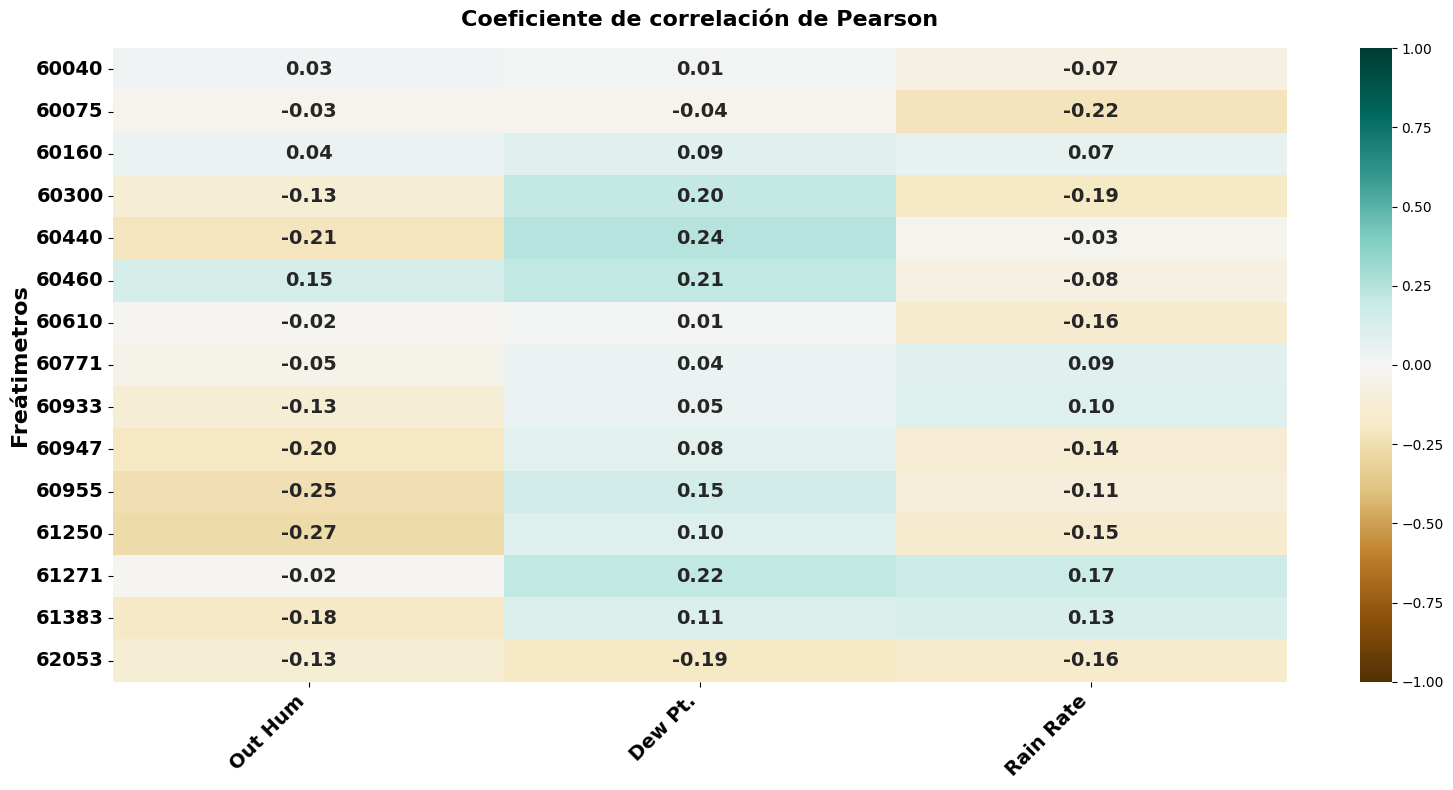

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aux = clima_caso2_h3[columnas_interes].corr(method='pearson')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.00).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 1].index  # Variables que cumplen la condición



# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Pearson',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

# prediccion de nivel rio y frea -  se podria empezar de aca

In [ ]:
import pandas as pd

#este archivo esta en formato long listo para entrenar una red neuronal - entre nivel del rio y freatimetros de Sept a Abril
ruta ='/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/df_merged_freatimetros_nivelRioNegro_long.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
df_merged_freatimetros_nivelRioNegro_long = pd.read_excel(ruta, sheet_name=nombre_pestaña)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ========================================================================
# 1️⃣ **Preprocesamiento: Codificación y Normalización**
# ========================================================================
df = df_merged_freatimetros_nivelRioNegro_long.copy()

# 🔹 **Codificación del ID de freatímetros**
label_encoder = LabelEncoder()
df['freátimetro_id_encoded'] = label_encoder.fit_transform(df['freátimetro_id'])

# 🔹 **Escalar el nivel del río**
scaler_X = StandardScaler()
df['nivelRio_scaled'] = scaler_X.fit_transform(df[['nivelRio']])

# 🔹 **Escalar el nivel freático**
scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])


# ========================================================================
# 2️⃣ **Generación de Secuencias**
# ========================================================================
def create_sequences_per_freatimetro(df, window_size=8):
    """
    Genera secuencias por cada freatímetro sin mezclar datos entre ellos.
    Retorna:
    - X_seq: Matriz (n_muestras, window_size, n_features)
    - y_seq: Valores objetivo correspondientes
    - freatimetros_seq: Lista con los freatímetros correspondientes
    - fechas_seq: Lista con las fechas correspondientes a cada secuencia
    """
    X_seq, y_seq, freatimetros_seq, fechas_seq = [], [], [], []

    for freatimetro_id in df['freátimetro_id_encoded'].unique():
        df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

        X = df_freatimetro[['nivelRio_scaled', 'freátimetro_id_encoded']].values
        y = df_freatimetro['nivel_freatico_scaled'].values
        fechas = df_freatimetro['fecha'].values


        for i in range(len(X) - window_size):
            ventana_X = X[i:i + window_size]
            valor_y = y[i + window_size]
            fecha_prediccion = fechas[i + window_size]
            X_seq.append(ventana_X)
            y_seq.append(valor_y)
            freatimetros_seq.append(freatimetro_id)
            fechas_seq.append(fecha_prediccion)

    return np.array(X_seq), np.array(y_seq), np.array(freatimetros_seq), np.array(fechas_seq)

# 🔹 **Generar secuencias**
X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df, window_size=8)

# ========================================================================
# 3️⃣ **Generar Secuencias por Freatímetro**
# ========================================================================
X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
freatimetros_train_list, freatimetros_test_list = [], []
fechas_train_list, fechas_test_list = [], []

for freatimetro_id in df['freátimetro_id_encoded'].unique():
    df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

    # 🔹 Generar secuencias para este freatímetro
    X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df_freatimetro, window_size=8)

    # 🔹 Dividir en entrenamiento y prueba SOLO para este freatímetro
    train_size = int(len(X_seq) * 0.8)

    X_train_list.append(X_seq[:train_size])
    X_test_list.append(X_seq[train_size:])
    y_train_list.append(y_seq[:train_size])
    y_test_list.append(y_seq[train_size:])
    fechas_train_list.append(fechas_seq[:train_size])
    fechas_test_list.append(fechas_seq[train_size:])
    freatimetros_train_list.append(freatimetros_seq[:train_size])
    freatimetros_test_list.append(freatimetros_seq[train_size:])

# 🔹 Concatenar las listas finales para obtener los conjuntos balanceados
X_train, X_test = np.vstack(X_train_list), np.vstack(X_test_list)
y_train, y_test = np.hstack(y_train_list), np.hstack(y_test_list)
fechas_train, fechas_test = np.hstack(fechas_train_list), np.hstack(fechas_test_list)
freatimetros_train, freatimetros_test = np.hstack(freatimetros_train_list), np.hstack(freatimetros_test_list)




In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

# 🔹 **Compilar el Modelo**
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.4208 - mae: 0.5067 - val_loss: 2.7127 - val_mae: 1.1488
Epoch 2/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0994 - mae: 0.2475 - val_loss: 2.9344 - val_mae: 1.1420
Epoch 3/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0890 - mae: 0.2344 - val_loss: 3.2577 - val_mae: 1.1027
Epoch 4/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0733 - mae: 0.2081 - val_loss: 3.3789 - val_mae: 1.1149
Epoch 5/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0666 - mae: 0.2030 - val_loss: 3.2344 - val_mae: 1.1134
Epoch 6/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0741 - mae: 0.2120 - val_loss: 3.2217 - val_mae: 1.1064
Epoch 7/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0616 - mae: 0.1920 - val_loss: 3.1594 - val_mae: 1.1054
Epoch 8/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0617 - mae: 0.1928 - val_loss: 3.3413 - val_mae: 1.1155
Epoch 9/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - lo

In [ ]:
# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# 🔹 **Generar Predicciones**
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 **Decodificar los IDs de los freatímetros**
freatimetros_test_original = label_encoder.inverse_transform(freatimetros_test)

# 🔹 **Encontrar la última predicción para cada freatímetro**
ultima_prediccion_por_freatimetro = {}
for i in range(len(freatimetros_test_original)):
    freatimetro_id = freatimetros_test_original[i]
    ultima_prediccion_por_freatimetro[freatimetro_id] = (fechas_test[i], y_pred[i][0], y_test_descaled[i][0])

# 🔹 **Mostrar los resultados finales**
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
for freatimetro_id, (fecha, pred, real) in sorted(ultima_prediccion_por_freatimetro.items()):
    print(f"Fecha: {fecha}, Freátimetro ID: {freatimetro_id}, Predicción: {pred:.2f}, Real: {real:.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1643 - mae: 0.2183
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step

Loss (MSE): 0.6013, MAE: 0.3935
📌 Última predicción de cada freatímetro:
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60040, Predicción: 192.83, Real: 191.50
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60075, Predicción: 192.99, Real: 192.04
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60160, Predicción: 194.08, Real: 193.54
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60300, Predicción: 195.50, Real: 194.98
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60440, Predicción: 196.79, Real: 196.51
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60460, Predicción: 197.53, Real: 197.08
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60610, Predicción: 198.16, Real: 197.02
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60771, Predicción: 198.95, Real: 199.52
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60933, Pred

In [ ]:
import numpy as np
import pandas as pd
import joblib
from dateutil.relativedelta import relativedelta

def predecir_nivel_freatico(model, df, freatimetro_id, scaler_X, scaler_y):
    """
    Predice el nivel freático para un freatímetro específico basado en los últimos 8 meses de datos.

    Parámetros:
    - model: Modelo LSTM entrenado.
    - df: DataFrame con los datos históricos.
    - freatimetro_id: ID del freatímetro que se desea predecir.
    - scaler_X: Escalador para los datos de entrada.
    - scaler_y: Escalador para los valores de salida (nivel freático).

    Retorna:
    - Fecha de la predicción y nivel freático estimado (msnm).
    """



    # Filtrar los datos del freatímetro específico
    df_freatimetro = df[df["freátimetro_id"] == freatimetro_id]

    # Verificar si hay suficientes datos (8 meses)
    if len(df_freatimetro) < 8:
        print(f"❌ No hay suficientes datos para el freatímetro {freatimetro_id} (se necesitan al menos 8 meses).")
        return None

    # Seleccionar los últimos 8 meses de datos
    ultimo_periodo = df_freatimetro[["fecha", "nivelRio"]].iloc[-8:].copy()

    # Obtener la última fecha y calcular la fecha de predicción
    ultima_fecha = ultimo_periodo["fecha"].iloc[-1]
    fecha_prediccion = ultima_fecha + relativedelta(months=1)

    print(f"🔹 Últimos 8 registros seleccionados para el freatímetro {freatimetro_id}:")
    print(ultimo_periodo)

    # Escalar el nivel del río
    nivelRio_scaled = scaler_X.transform(ultimo_periodo[["nivelRio"]])
     # **Codificar el ID del freatímetro correctamente**
    if freatimetro_id in label_encoder.classes_:
        freatimetro_encoded = label_encoder.transform([freatimetro_id])[0]  # Convertir ID a formato codificado
    else:
        print(f"❌ Error: El freatímetro {freatimetro_id} no está en el LabelEncoder.")
        return None

    freatimetro_encoded_array = np.full((8, 1), freatimetro_encoded)  # Crear array con el mismo valor en los 8 meses

    # Combinar nivel del río escalado con ID codificado
    input_data = np.hstack((nivelRio_scaled, freatimetro_encoded_array))

    # Redimensionar para el modelo LSTM (1 muestra, 8 meses, 2 variables)
    X_pred = np.array([input_data])

    # Realizar la predicción con el modelo LSTM
    y_pred_scaled = model.predict(X_pred)

    # Desescalar la predicción para obtener valores reales de nivel de napa (msnm)
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)[0][0]

    # Mostrar resultado
    print(f"\n📌 Predicción del Nivel Freático para el Freatímetro {freatimetro_id}")
    print(f"📅 Fecha Predicción: {fecha_prediccion.strftime('%Y-%m')}, Nivel Freático: {y_pred_real:.2f} msnm")



    return fecha_prediccion, y_pred_real

# **Ejemplo: Predecir el nivel freático del freatímetro 60040 en enero de 2023**
predecir_nivel_freatico(
    model=model,
    df=df_merged_freatimetros_nivelRioNegro_long,
    freatimetro_id=61383,
    scaler_X=scaler_X,
    scaler_y=scaler_y
)

🔹 Últimos 8 registros seleccionados para el freatímetro 61383:
          fecha    nivelRio
1453 2022-01-01  236.110968
1468 2022-02-01  236.146786
1483 2022-03-01  236.095161
1498 2022-04-01  236.093333
1513 2022-09-01  236.074667
1528 2022-10-01  236.159032
1543 2022-11-01  236.312000
1558 2022-12-01  236.569032
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

📌 Predicción del Nivel Freático para el Freatímetro 61383
📅 Fecha Predicción: 2023-01, Nivel Freático: 202.01 msnm


(Timestamp('2023-01-01 00:00:00'), np.float32(202.0088))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


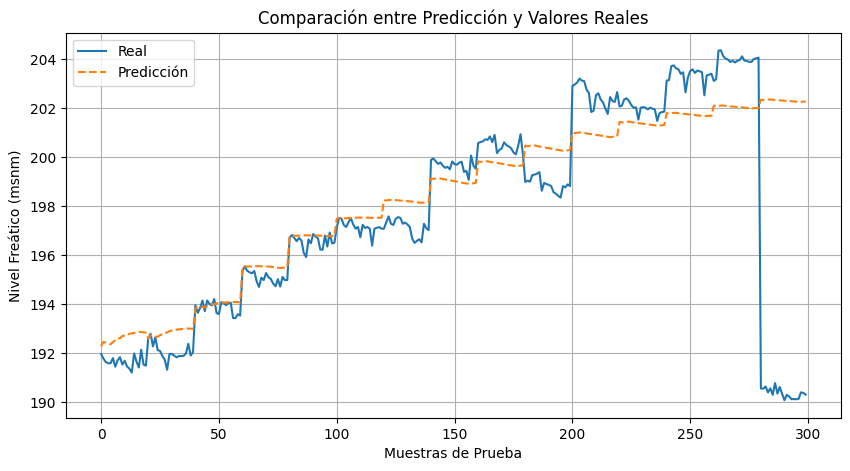

In [ ]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Real", linestyle="-")
plt.plot(y_pred, label="Predicción", linestyle="dashed")
plt.xlabel("Muestras de Prueba")
plt.ylabel("Nivel Freático (msnm)")
plt.title("Comparación entre Predicción y Valores Reales")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

r2 = r2_score(y_test_descaled, y_pred)
print(f"🔹 Coeficiente de Determinación R²: {r2:.2f}")

# Obtener el ID codificado de 60040
id_60040_codificado = label_encoder.transform([60040])[0]

print(f"🔹 ID del freatímetro 60040 codificado: {id_60040_codificado}")

# Calcular MSE
mse = mean_squared_error(y_test_descaled, y_pred)

print(f"📉 MSE: {mse:.4f}")

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y_test_descaled, y_pred))

print(f"📉 RMSE: {rmse:.4f}")




🔹 Coeficiente de Determinación R²: 0.42
🔹 ID del freatímetro 60040 codificado: 0
📉 MSE: 10.6057
📉 RMSE: 3.2566


In [ ]:
#no funciona y no se que hace

# Desescalar las predicciones y los valores reales si aún no lo has hecho
y_pred_desescalado = scaler_y.inverse_transform(y_pred_scaled)
y_test_desescalado = scaler_y.inverse_transform(y_test)

# H1. Configuraciones con Rio y Freatimetros

## PARTE COMUN

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

#este archivo esta en formato long listo para entrenar una red neuronal con nivel rio - freatimetros
# tiene fecha, nivelRio, freátimetro_id, nivel_freatico

ruta ='/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/df_merged_freatimetros_nivelRioNegro_long_caso2.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
long_data = pd.read_excel(ruta, sheet_name=nombre_pestaña)

#lo paso a otro nombre...nose porque

df_merged_freatimetros_nivelRioNegro_long=long_data[['fecha','freátimetro_id','nivelRio', 'nivel_freatico']]
print(df_merged_freatimetros_nivelRioNegro_long)

          fecha  freátimetro_id    nivelRio  nivel_freatico
0    2010-01-01           60040  236.547742      191.432000
1    2010-01-01           60075  236.547742      192.015000
2    2010-01-01           60160  236.547742      194.180000
3    2010-01-01           60300  236.547742      195.252000
4    2010-01-01           60440  236.547742      197.180000
...         ...             ...         ...             ...
1555 2022-12-01           60955  236.569032      202.647000
1556 2022-12-01           61250  236.569032      201.853000
1557 2022-12-01           61271  236.569032      203.397000
1558 2022-12-01           61383  236.569032      204.055000
1559 2022-12-01           62053  236.569032      190.311453

[1560 rows x 4 columns]


In [5]:
# armo los pasos de la red
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ========================================================================
# 1️⃣ **Preprocesamiento: Codificación y Normalización caso 1**
# ========================================================================
df = df_merged_freatimetros_nivelRioNegro_long.copy()

unique_ids = np.sort(df['freátimetro_id'].unique())  # Orden natural

# 🔹 **Colocar el 62053 en la primera posición y mantener el orden**
custom_order = [62053] + [id_ for id_ in unique_ids if id_ != 62053]

# 🔹 **Crear diccionario de mapeo manual**
id_to_encoded = {id_: idx for idx, id_ in enumerate(custom_order)}

# 🔹 **Aplicar codificación manual**
df['freátimetro_id_encoded'] = df['freátimetro_id'].map(id_to_encoded)

print(df['freátimetro_id_encoded'])
# 🔹 **Escalar el nivel del río**
scaler_X = StandardScaler()
df['nivelRio_scaled'] = scaler_X.fit_transform(df[['nivelRio']])

# 🔹 **Escalar el nivel freático**
scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])



# ========================================================================
# 2️⃣ **Generación de Secuencias (Ventana de 8 Meses)**
# ========================================================================
#no deberian ser ventanas de 8 meses? porque ahora son 8 meses
def create_sequences_per_freatimetro(df, window_size=8):
    """
    Genera secuencias por cada freatímetro sin mezclar datos entre ellos.
    """
    X_seq, y_seq, freatimetros_seq, fechas_seq = [], [], [], []

    for freatimetro_id in df['freátimetro_id_encoded'].unique():
        df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

        X = df_freatimetro[['nivelRio_scaled', 'freátimetro_id_encoded']].values
        y = df_freatimetro['nivel_freatico_scaled'].values
        fechas = df_freatimetro['fecha'].values

        for i in range(len(X) - window_size):
            ventana_X = X[i:i + window_size]
            valor_y = y[i + window_size]
            fecha_prediccion = fechas[i + window_size]

            X_seq.append(ventana_X)
            y_seq.append(valor_y)
            freatimetros_seq.append(freatimetro_id)
            fechas_seq.append(fecha_prediccion)

    return np.array(X_seq), np.array(y_seq), np.array(freatimetros_seq), np.array(fechas_seq)

# ========================================================================
# 3️⃣ **División en Entrenamiento y Prueba POR FREATÍMETRO**
# ========================================================================
X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
freatimetros_train_list, freatimetros_test_list = [], []
fechas_train_list, fechas_test_list = [], []

# 🔹 **Generar secuencias antes de dividir**
X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df, window_size=4)

# 🔹 **Dividir por cada freatímetro**
for freatimetro_id in np.unique(freatimetros_seq):
    indices_freatimetro = np.where(freatimetros_seq == freatimetro_id)[0]
    train_size = int(len(indices_freatimetro) * 0.8)

    X_train_list.append(X_seq[indices_freatimetro[:train_size]])
    X_test_list.append(X_seq[indices_freatimetro[train_size:]])
    y_train_list.append(y_seq[indices_freatimetro[:train_size]])
    y_test_list.append(y_seq[indices_freatimetro[train_size:]])
    fechas_train_list.append(fechas_seq[indices_freatimetro[:train_size]])
    fechas_test_list.append(fechas_seq[indices_freatimetro[train_size:]])
    freatimetros_train_list.append(freatimetros_seq[indices_freatimetro[:train_size]])
    freatimetros_test_list.append(freatimetros_seq[indices_freatimetro[train_size:]])

# 🔹 **Concatenar los resultados finales**
X_train, X_test = np.vstack(X_train_list), np.vstack(X_test_list)
y_train, y_test = np.hstack(y_train_list), np.hstack(y_test_list)
fechas_train, fechas_test = np.hstack(fechas_train_list), np.hstack(fechas_test_list)
freatimetros_train, freatimetros_test = np.hstack(freatimetros_train_list), np.hstack(freatimetros_test_list)

# ========================================================================
# ✅ **Verificación de Datos**
# ========================================================================
print(f"🔹 X_train shape: {X_train.shape}")  # (n_muestras, 8 number of time steps, 2 variables)
print(f"🔹 y_train shape: {y_train.shape}")  # (n_muestras,)
print(f"🔹 Cantidad de freatímetros únicos en test: {len(set(freatimetros_test))}")
print(f"🔹 Freatímetros en test: {set(freatimetros_test)}")
print(f"🔹 Fechas en test (últimas 5 muestras): {fechas_test[-5:]}")


0        1
1        2
2        3
3        4
4        5
        ..
1555    11
1556    12
1557    13
1558    14
1559     0
Name: freátimetro_id_encoded, Length: 1560, dtype: int64
🔹 X_train shape: (1200, 4, 2)
🔹 y_train shape: (1200,)
🔹 Cantidad de freatímetros únicos en test: 15
🔹 Freatímetros en test: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)}
🔹 Fechas en test (últimas 5 muestras): ['2022-04-01T00:00:00.000000000' '2022-09-01T00:00:00.000000000'
 '2022-10-01T00:00:00.000000000' '2022-11-01T00:00:00.000000000'
 '2022-12-01T00:00:00.000000000']


### LSTM: Final del paper rio con freatimetro - 1ra configuracion segun paper

Number of LSTM layers 1

Number of units per layer 32

Batch size 16

Number of epochs 200

Learning rate 0.0005

Activation function (LSTM) tanh

Dropout rate (LSTM) 0.2

Optimization Adam

In [39]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
# 1ra configuracion

#Number of LSTM layers 1
#Number of units per layer 32
#Activation function (LSTM) tanh

model = Sequential()


#capa 2
model.add(LSTM(32, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(1, activation='linear'))


# 🔹 **Compilar el Modelo**

#Optimization Adam
#Learning rate 0.001
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

#Batch size 16
#Number of epochs 200

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.8901 - mae: 0.7737 - val_loss: 0.6734 - val_mae: 0.8105
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5304 - mae: 0.5457 - val_loss: 0.1106 - val_mae: 0.3123
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2943 - mae: 0.4030 - val_loss: 0.0360 - val_mae: 0.1570
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1884 - mae: 0.3265 - val_loss: 0.1120 - val_mae: 0.3119
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1267 - mae: 0.2702 - val_loss: 0.1732 - val_mae: 0.3969
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0839 - mae: 0.2294 - val_loss: 0.2084 - val_mae: 0.4388
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0739 - mae: 0.2125 - val_loss: 0.2082 - val_mae: 0.4388
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0614 - mae: 0.1928 - val_loss: 0.2016 - val_mae: 0.4320
Epoch 9/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.06

In [43]:
history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0440 - mae: 0.1597 - val_loss: 0.0140 - val_mae: 0.0897
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0439 - mae: 0.1593 - val_loss: 0.0144 - val_mae: 0.0911
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0410 - mae: 0.1536 - val_loss: 0.0140 - val_mae: 0.0870
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0403 - mae: 0.1519 - val_loss: 0.0176 - val_mae: 0.1000
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0413 - mae: 0.1549 - val_loss: 0.0171 - val_mae: 0.1033
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0449 - mae: 0.1600 - val_loss: 0.0160 - val_mae: 0.0937
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0458 - mae: 0.1638 - val_loss: 0.0148 - val_mae: 0.0904
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0437 - mae: 0.1603 - val_loss: 0.0160 - val_mae: 0.0977
Epoch 9/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss

In [44]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================

# aca calcule las métricas loss=mse y  mae
loss, mae = model.evaluate(X_test, y_test, verbose=1)

loss_test, mae_test = model.evaluate(X_test, y_test, verbose=0)

print("Test loss (MSE):", loss_test)
print("Test MAE:", mae_test)


# 🔹 **Generar Predicciones**
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 **Decodificar los IDs de los freatímetros**
encoded_to_id = {v: k for k, v in id_to_encoded.items()}
freatimetros_test_original=  [encoded_to_id[id_] for id_ in freatimetros_test]

# 🔹 **Crear un DataFrame con los resultados**
df_resultados = pd.DataFrame({
    "Fecha": fechas_test,
    "Freátimetro ID": freatimetros_test_original,
    "Predicción": y_pred.flatten(),
    "Real": y_test_descaled.flatten()
})

# 🔹 **Obtener la última predicción por cada freatímetro**
df_resultados = df_resultados.sort_values(by=["Freátimetro ID", "Fecha"])  # Ordenar correctamente
df_ultimas_predicciones = df_resultados.groupby("Freátimetro ID").last().reset_index()

# 🔹 **Mostrar los resultados finales**
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
print(df_ultimas_predicciones)

# 🔹 **Opcional: Guardar en Excel para análisis posterior**
df_ultimas_predicciones.to_excel("predicciones_ventana4.xlsx", index=False)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0210 - mae: 0.1068 
Test loss (MSE): 0.030901022255420685
Test MAE: 0.13170108199119568
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Loss (MSE): 0.0309, MAE: 0.1317
📌 Última predicción de cada freatímetro:
    Freátimetro ID      Fecha  Predicción        Real
0            60040 2022-12-01  191.439468  191.495829
1            60075 2022-12-01  192.623871  192.037601
2            60160 2022-12-01  193.995087  193.537241
3            60300 2022-12-01  195.318329  194.983411
4            60440 2022-12-01  196.431519  196.506990
5            60460 2022-12-01  197.364960  197.078000
6            60610 2022-12-01  198.217560  197.020000
7            60771 2022-12-01  199.051224  199.520000
8            60933 2022-12-01  199.889832  200.110000
9            60947 2022-12-01  200.733231  198.815000
10           60955 2022-12-01  201.565979  202.647000
11           61250 2022-12-01  202.364624  201.853000
12           61271 2022-12-01  203.105194  203.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


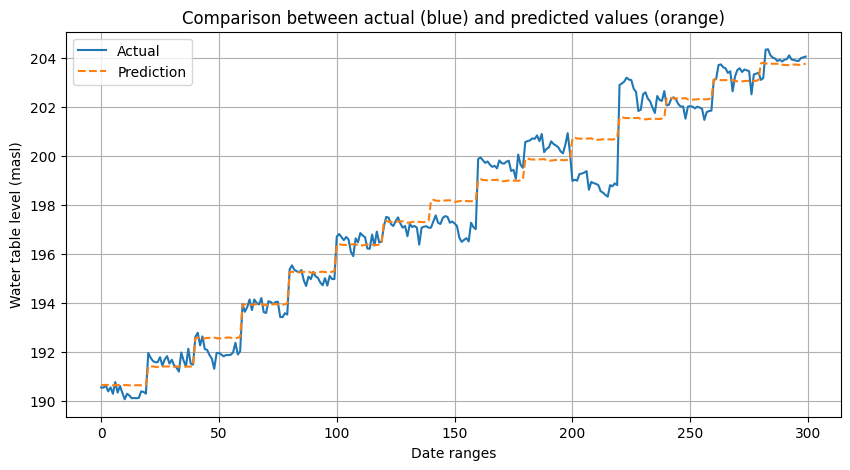

In [45]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("Comparison between actual (blue) and predicted values (orange)")
plt.legend()
plt.grid()
plt.show()


Loss (MSE): 0.0309

MAE: 0.1317

R²: 0.9700

RMSE: 0.1758


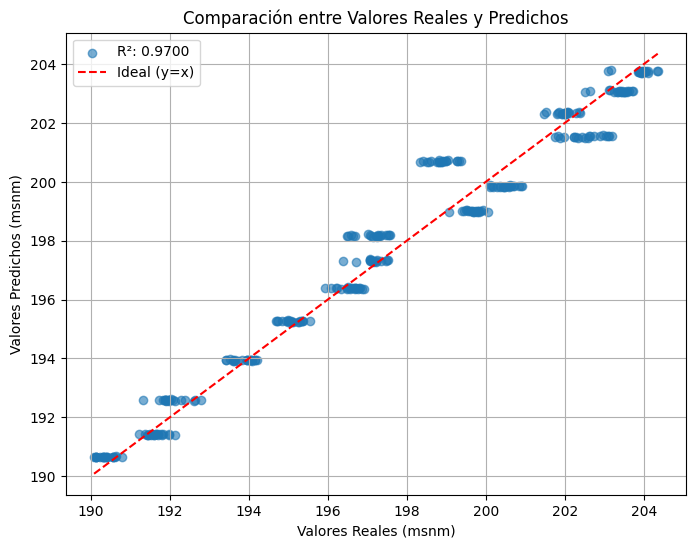

In [46]:
#metricas

print(f"\nLoss (MSE): {loss:.4f}")
print(f"\nMAE: {mae:.4f}")
#luego calculamos:
#metrica r2, mejor valor mas cerca de 1
r2 = r2_score(y_test, y_pred_scaled)
print(f"\nR²: {r2:.4f}")

# metrica RMSE, mejor valor mas cerca de 0
#rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
rmse = np.sqrt(loss)
print(f"\nRMSE: {rmse:.4f}")


# dibujo por si sirve
# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()


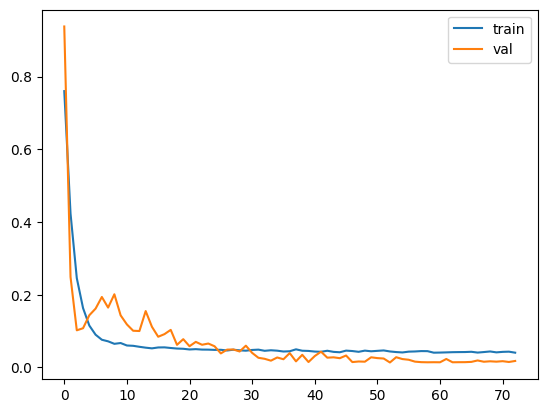

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()

###LSTM: 2da configuracion, la que puse en el paper

Number of LSTM layers 2

Number of units per layer 128-64

Batch size 16

Number of epochs 200

Learning rate 0.001

Activation function (LSTM) tanh

Dropout rate (LSTM) 0.3

Optimization Adam

In [47]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
# 1ra configuracion

#Number of LSTM layers 2
#Number of units per layer 128-64
#Activation function (LSTM) tanh

model = Sequential()
#capa 1
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh', return_sequences=True))
model.add(Dropout(0.3))

#capa 2
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))

model.add(Dense(1, activation='linear'))


# 🔹 **Compilar el Modelo**

#Optimization Adam
#Learning rate 0.001
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

#Batch size 16
#Number of epochs 200

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 0.5656 - mae: 0.5868 - val_loss: 0.0361 - val_mae: 0.1581
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0670 - mae: 0.2029 - val_loss: 0.0819 - val_mae: 0.2614
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0584 - mae: 0.1912 - val_loss: 0.1463 - val_mae: 0.3650
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0553 - mae: 0.1883 - val_loss: 0.0925 - val_mae: 0.2824
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0461 - mae: 0.1679 - val_loss: 0.0647 - val_mae: 0.2300
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0487 - mae: 0.1718 - val_loss: 0.0305 - val_mae: 0.1434
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0512 - mae: 0.1708 - val_loss: 0.0772 - val_mae: 0.2560
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0473 - mae: 0.1709 - val_loss: 0.0191 - val_mae: 0.1044
Epoch 9/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0515 

In [64]:
history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0424 - mae: 0.1580 - val_loss: 0.0261 - val_mae: 0.1279
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0431 - mae: 0.1620 - val_loss: 0.0237 - val_mae: 0.1207
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0414 - mae: 0.1584 - val_loss: 0.0393 - val_mae: 0.1595
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0471 - mae: 0.1690 - val_loss: 0.2909 - val_mae: 0.4998
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0402 - mae: 0.1552 - val_loss: 0.0568 - val_mae: 0.1936
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0431 - mae: 0.1584 - val_loss: 0.1517 - val_mae: 0.3404
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0398 - mae: 0.1542 - val_loss: 0.0399 - val_mae: 0.1631
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0418 - mae: 0.1574 - val_loss: 0.4284 - val_mae: 0.6001
Epoch 9/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - lo

In [65]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================

# aca calcule las métricas loss=mse y  mae
loss, mae = model.evaluate(X_test, y_test, verbose=1)

loss_test, mae_test = model.evaluate(X_test, y_test, verbose=0)

print("Test loss (MSE):", loss_test)
print("Test MAE:", mae_test)


# 🔹 **Generar Predicciones**
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 **Decodificar los IDs de los freatímetros**
encoded_to_id = {v: k for k, v in id_to_encoded.items()}
freatimetros_test_original=  [encoded_to_id[id_] for id_ in freatimetros_test]

# 🔹 **Crear un DataFrame con los resultados**
df_resultados = pd.DataFrame({
    "Fecha": fechas_test,
    "Freátimetro ID": freatimetros_test_original,
    "Predicción": y_pred.flatten(),
    "Real": y_test_descaled.flatten()
})

# 🔹 **Obtener la última predicción por cada freatímetro**
df_resultados = df_resultados.sort_values(by=["Freátimetro ID", "Fecha"])  # Ordenar correctamente
df_ultimas_predicciones = df_resultados.groupby("Freátimetro ID").last().reset_index()

# 🔹 **Mostrar los resultados finales**
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
print(df_ultimas_predicciones)

# 🔹 **Opcional: Guardar en Excel para análisis posterior**
df_ultimas_predicciones.to_excel("predicciones_ventana4.xlsx", index=False)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0204 - mae: 0.1055
Test loss (MSE): 0.03165823221206665
Test MAE: 0.13368265330791473
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Loss (MSE): 0.0317, MAE: 0.1337
📌 Última predicción de cada freatímetro:
    Freátimetro ID      Fecha  Predicción        Real
0            60040 2022-12-01  191.372528  191.495829
1            60075 2022-12-01  192.456116  192.037601
2            60160 2022-12-01  193.789871  193.537241
3            60300 2022-12-01  195.183929  194.983411
4            60440 2022-12-01  196.368729  196.506990
5            60460 2022-12-01  197.276047  197.078000
6            60610 2022-12-01  198.018097  197.020000
7            60771 2022-12-01  198.708755  199.520000
8            60933 2022-12-01  199.420670  200.110000
9            60947 2022-12-01  200.197372  198.815000
10           60955 2022-12-01  201.062317  202.647000
11           61250 2022-12-01  202.018875  201.853000
12           61271 2022-12-01  203.047729  203.39

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


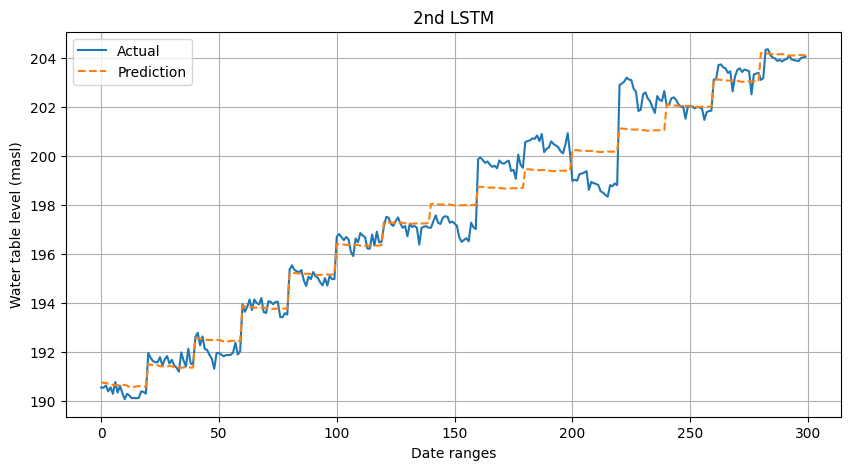

In [66]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("2nd LSTM")
plt.legend()
plt.grid()
plt.show()


Loss (MSE): 0.0317

MAE: 0.1337

R²: 0.9693

RMSE: 0.1779


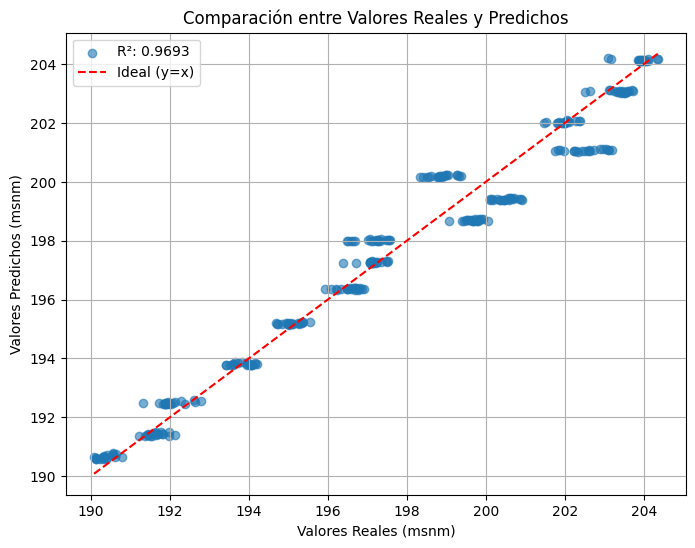

In [67]:
#metricas

print(f"\nLoss (MSE): {loss:.4f}")
print(f"\nMAE: {mae:.4f}")
#luego calculamos:
#metrica r2, mejor valor mas cerca de 1
r2 = r2_score(y_test, y_pred_scaled)
print(f"\nR²: {r2:.4f}")

# metrica RMSE, mejor valor mas cerca de 0
#rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
rmse = np.sqrt(loss)
print(f"\nRMSE: {rmse:.4f}")


# dibujo por si sirve
# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()


### ANN

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo ANN como regresion**
# ========================================================================


from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Reshape X_train and X_test from 3D to 2D
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# Initialize and train MLPRegressor (for regression since y is continuous)

#da peor con 128, 64
#mlp = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
mlp = MLPRegressor(hidden_layer_sizes=(20,), alpha = 0.01, activation='relu', max_iter=500, solver='lbfgs', random_state=42)
mlp.fit(X_train_reshaped, y_train)

y_pred = mlp.predict(X_test_reshaped)

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error:: {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error:: 0.1314
Mean Squared Error (MSE): 0.0302
Root Mean Squared Error (RMSE): 0.1737
R-squared (R²): 0.9707


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


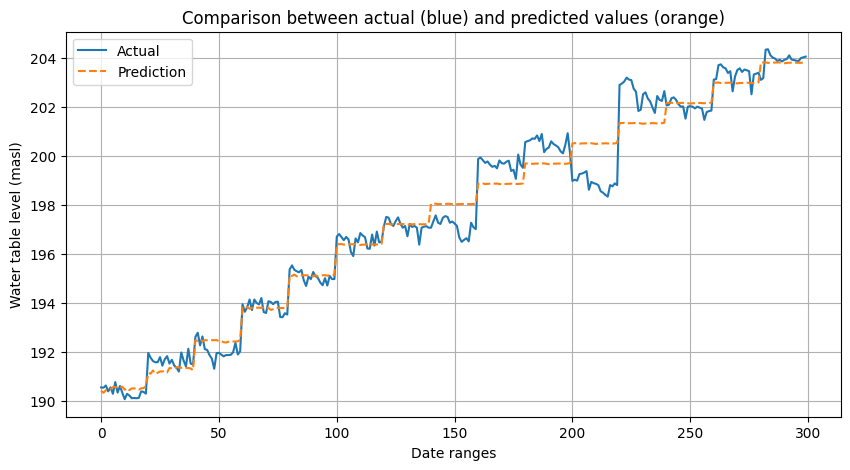

In [ ]:
#graficar

import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = mlp.predict(X_test_reshaped)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("Comparison between actual (blue) and predicted values (orange)")
plt.legend()
plt.grid()
plt.show()


Loss (MSE): 0.0302

RMSE: 0.1737

R²: 0.9707


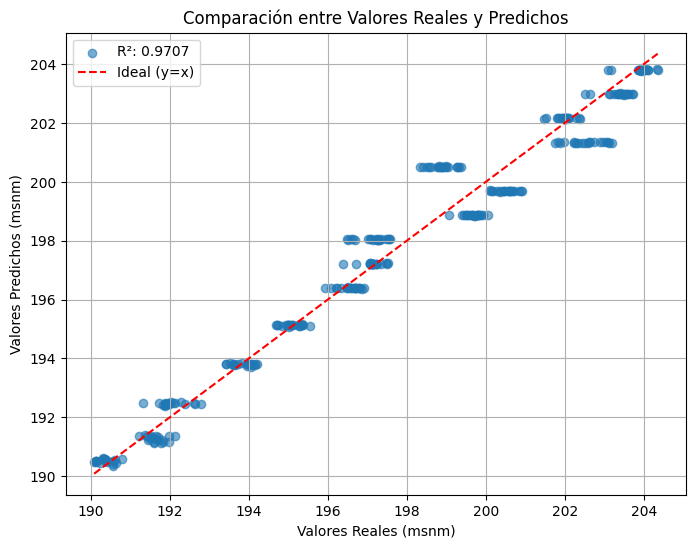

In [ ]:
import matplotlib.pyplot as plt

# Evaluate the model using regression metrics
#mse = mean_squared_error(y_test, y_pred)
#rmse = np.sqrt(mse)
#r2 = r2_score(y_test, y_pred)

#metricas

print(f"\nLoss (MSE): {mse:.4f}") # Using mse directly as the 'loss' metric
print(f"\nRMSE: {rmse:.4f}")
print(f"\nR²: {r2:.4f}")


# dibujo por si sirve
# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()

###SVM

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo SVM**
# ========================================================================
#aplicar SVM, en realidad SVR para regresion

import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold



# Reshape X_train and X_test from 3D to 2D
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# 3. Create and train the SVR model
# A pipeline is used to first scale the data and then apply SVR
# The RBF kernel is a common choice for non-linear data
regr = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, epsilon=0.2, gamma=0.01))
regr.fit(X_train_reshaped, y_train) # Train the model
#Best Hyperparameters: {'svr__C': 100, 'svr__epsilon': 0.2, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}


# 4. Make predictions
y_pred = regr.predict(X_test_reshaped)



# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error:: {mae:.4f}")

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# 4. CONFIGURE CROSS-VALIDATION
# For small data (<50 samples), use KFold with more splits (e.g., 5 or 10)
# or even LeaveOneOut() to maximize training data usage.
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'svr__kernel': ['rbf'],              # RBF is usually best for small/complex data
    'svr__C': [0.1, 1, 10, 50, 100],     # Regularization: Higher C = less regularization
    'svr__gamma': ['scale', 0.1, 0.01],  # 'scale' is default, explicit floats help fine-tune
    'svr__epsilon': [0.01, 0.1, 0.2]     # Threshold of error tolerance
}

# 5. RUN GRID SEARCH
print("Tuning SVR... this may take a moment.")
grid_search = GridSearchCV(
    estimator=regr,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_mean_squared_error', # Optimized for lowest error
    n_jobs=-1,                        # Use all CPU cores
    verbose=1
)

grid_search.fit(X_train_reshaped, y_train)

# 6. RESULTS
best_params = grid_search.best_params_
best_score = -grid_search.best_score_  # Negating because scoring was negative MSE

print("\n--- Best Results ---")
print(f"Best Hyperparameters: {best_params}")
print(f"Best RMSE (approx): {np.sqrt(best_score):.4f}")


Mean Absolute Error:: 0.1622
Mean Squared Error (MSE): 0.0373
Root Mean Squared Error (RMSE): 0.1932
R-squared (R²): 0.9649
Tuning SVR... this may take a moment.
Fitting 5 folds for each of 45 candidates, totalling 225 fits

--- Best Results ---
Best Hyperparameters: {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
Best RMSE (approx): 0.1841


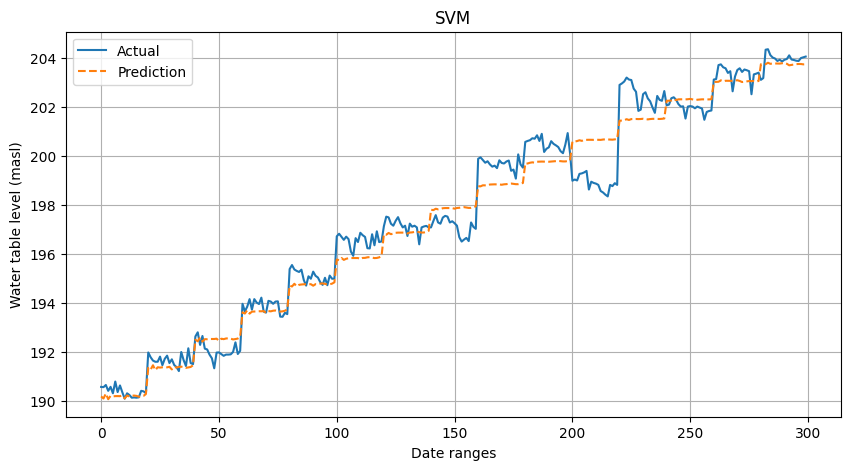

In [ ]:
#graficar

import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = regr.predict(X_test_reshaped)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("SVM")
plt.legend()
plt.grid()
plt.show()

# H2 y H3. Configuraciones con Clima y Freatimetros

## PARTE COMUN H3: Solo con 'Out Hum', 'Dew Pt.','Rain Rate'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
archivo_excel = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datasetRedNcaso2.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datasetMerge = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)

# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]  # Asegúrate de que esta lista contenga todos los freatímetros que desees incluir.
# Agrega aquí otras variables de interés
variables_interes = ['Out Hum', 'Dew Pt.','Rain Rate']




# Combina las listas
columnas_interes = freatimetros + variables_interes

print(columnas_interes)

[60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053, 'Out Hum', 'Dew Pt.', 'Rain Rate']


['Out Hum', 'Dew Pt.', 'Rain Rate']


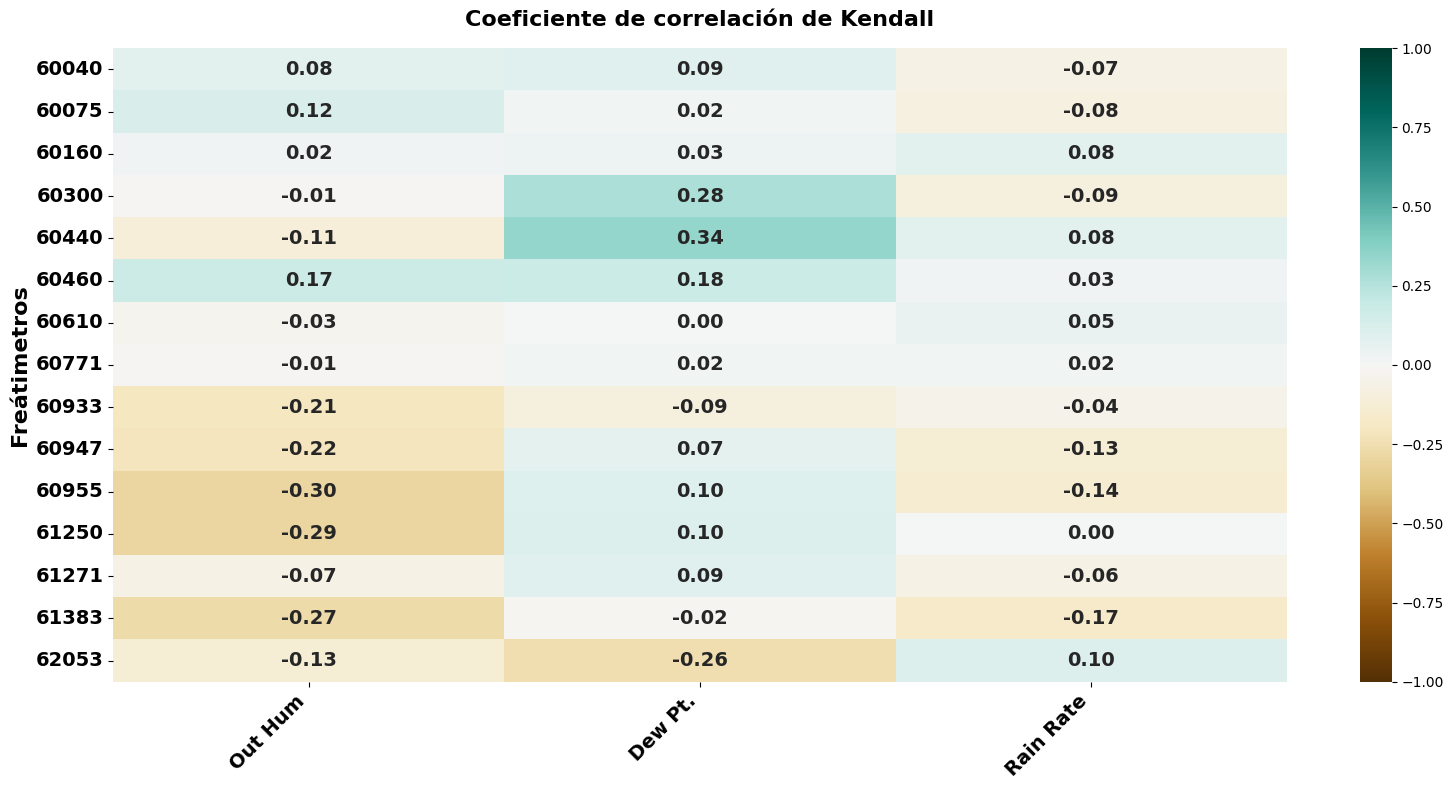

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
aux = datasetMerge[columnas_interes].corr(method='pearson')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

print(climaticas_labels)

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

#Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
#variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.10).sum(), axis=0)
#variables_to_keep = variables_to_keep[variables_to_keep > 7].index  # Variables que cumplen la condición

# Filtrar la matriz para las variables climáticas seleccionadas
#filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
# Transformar el dataset al formato "long" para incluir todos los freátimetros
# Identificar las columnas de los freátimetros
freatimetro_columns = [60040, 60075, 60160, 60300, 60440, 60460, 60610,
                       60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

variables_interes = ['Out Hum', 'Dew Pt.','Rain Rate','fecha']
#print(datasetMerge)

# Usar pandas.melt para transformar el dataset
long_data = pd.melt(
    datasetMerge,
    id_vars=variables_interes,  # Variables comunes
    value_vars=freatimetro_columns,  # Columnas de freátimetros
    var_name='freátimetro_id',       # Nombre de la columna de identificadores
    value_name='nivel_freatico'      # Valores de los niveles freáticos
)
#print(long_data)

# Ordenar por fecha para preservar la secuencia temporal
long_data.sort_values(by=['fecha', 'freátimetro_id'], inplace=True)
# Verificar el formato de la columna 'fecha'
print(long_data['fecha'].dtype)
print(long_data['fecha'].head())
long_data = long_data[
    #ya tenia solo esos meses igualmente
    (long_data['fecha'].dt.month.isin([1,2,3,4,9,10,11,12])) &
    (long_data['fecha'].dt.year.between(2010, 2021))
]

# Revisar el resultado de la transformación
print(f'el long data tiene {long_data.head()} ')
print(f'las variables son {variables_interes} ')

datetime64[ns]
0     2010-01-01
77    2010-01-01
154   2010-01-01
231   2010-01-01
308   2010-01-01
Name: fecha, dtype: datetime64[ns]
el long data tiene        Out Hum   Dew Pt.  Rain Rate      fecha freátimetro_id  nivel_freatico
0    54.647326  4.970003   0.305193 2010-01-01          60040         191.432
77   54.647326  4.970003   0.305193 2010-01-01          60075         192.015
154  54.647326  4.970003   0.305193 2010-01-01          60160         194.180
231  54.647326  4.970003   0.305193 2010-01-01          60300         195.252
308  54.647326  4.970003   0.305193 2010-01-01          60440         197.180 
las variables son ['Out Hum', 'Dew Pt.', 'Rain Rate', 'fecha'] 


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Asumo que ya tenés tu DataFrame df con las variables climáticas y el freatimetro_id

# ========================================================================
# 1️⃣ **Preprocesamiento: Codificación y Normalización - Variables Climáticas**
# ========================================================================
df = long_data.copy()
# 🔹 **Orden personalizado para freatímetros**
unique_ids = np.sort(df['freátimetro_id'].unique())
custom_order = [62053] + [id_ for id_ in unique_ids if id_ != 62053]
id_to_encoded = {id_: idx for idx, id_ in enumerate(custom_order)}
df['freátimetro_id_encoded'] = df['freátimetro_id'].map(id_to_encoded)

# 🔹 **Escalar las variables climáticas seleccionadas**
scaler_X = StandardScaler()
df[['out_hum_scaled', 'dew_pt_scaled', 'rain_rate_scaled']] = scaler_X.fit_transform(df[['Out Hum', 'Dew Pt.','Rain Rate']])

# 🔹 **Escalar la variable de salida (nivel freático)**
scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])

# ========================================================================
# 2️⃣ **Generación de Secuencias (Ventana de 8 Meses)**
# ========================================================

def create_sequences_per_freatimetro(df, window_size=8):
    """
    Genera secuencias por cada freatímetro sin mezclar datos entre ellos.
    """
    X_seq, y_seq, freatimetros_seq, fechas_seq = [], [], [], []

    for freatimetro_id in df['freátimetro_id_encoded'].unique():
        df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

        X = df_freatimetro[['out_hum_scaled', 'dew_pt_scaled', 'rain_rate_scaled', 'freátimetro_id_encoded']].values
        y = df_freatimetro['nivel_freatico_scaled'].values
        fechas = df_freatimetro['fecha'].values

        for i in range(len(X) - window_size):
            ventana_X = X[i:i + window_size]
            valor_y = y[i + window_size]
            fecha_prediccion = fechas[i + window_size]

            X_seq.append(ventana_X)
            y_seq.append(valor_y)
            freatimetros_seq.append(freatimetro_id)
            fechas_seq.append(fecha_prediccion)

    return np.array(X_seq), np.array(y_seq), np.array(freatimetros_seq), np.array(fechas_seq)

# ========================================================================
# 3️⃣ **División en Entrenamiento y Prueba POR FREATÍMETRO**
# ========================================================================

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
freatimetros_train_list, freatimetros_test_list = [], []
fechas_train_list, fechas_test_list = [], []

X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df, window_size=4)

for freatimetro_id in np.unique(freatimetros_seq):
    indices_freatimetro = np.where(freatimetros_seq == freatimetro_id)[0]
    train_size = int(len(indices_freatimetro) * 0.8)

    X_train_list.append(X_seq[indices_freatimetro[:train_size]])
    X_test_list.append(X_seq[indices_freatimetro[train_size:]])
    y_train_list.append(y_seq[indices_freatimetro[:train_size]])
    y_test_list.append(y_seq[indices_freatimetro[train_size:]])
    fechas_train_list.append(fechas_seq[indices_freatimetro[:train_size]])
    fechas_test_list.append(fechas_seq[indices_freatimetro[train_size:]])
    freatimetros_train_list.append(freatimetros_seq[indices_freatimetro[:train_size]])
    freatimetros_test_list.append(freatimetros_seq[indices_freatimetro[train_size:]])

X_train, X_test = np.vstack(X_train_list), np.vstack(X_test_list)
y_train, y_test = np.hstack(y_train_list), np.hstack(y_test_list)
fechas_train, fechas_test = np.hstack(fechas_train_list), np.hstack(fechas_test_list)
freatimetros_train, freatimetros_test = np.hstack(freatimetros_train_list), np.hstack(freatimetros_test_list)

# ========================================================================
# ✅ **Verificación**
# ========================================================================
print(f"🔹 X_train shape: {X_train.shape}  (n_muestras, 4, 10)")  # 10 variables ahora
print(f"🔹 y_train shape: {y_train.shape}")
print(f"🔹 Variables usadas: {variables_interes} + ID freatímetro")
#X_seq[0]
X_test[0]

🔹 X_train shape: (870, 4, 4)  (n_muestras, 4, 10)
🔹 y_train shape: (870,)
🔹 Variables usadas: ['Out Hum', 'Dew Pt.', 'Rain Rate', 'fecha'] + ID freatímetro


array([[ 1.44667586,  1.05729416,  0.98574808,  0.        ],
       [ 2.6301191 ,  0.44817504,  0.40927278,  0.        ],
       [ 0.42960508, -0.72370692, -0.01562957,  0.        ],
       [-1.14254711, -1.29521829, -0.47953316,  0.        ]])

### LSTM:  2da configuracion, segun paper

Number of LSTM layers 2

Number of units per layer 128-64

Batch size 16

Number of epochs 200

Learning rate 0.001

Activation function (LSTM) tanh

Dropout rate (LSTM) 0.3

Optimization Adam

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
# 1ra configuracion

#Number of LSTM layers 2
#Number of units per layer 128-64
#Activation function (LSTM) tanh

model = Sequential()
#capa 1
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh', return_sequences=True))
model.add(Dropout(0.3))

#capa 2
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))

model.add(Dense(1, activation='linear'))


# 🔹 **Compilar el Modelo**

#Optimization Adam
#Learning rate 0.001
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

#Batch size 16
#Number of epochs 200

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.6396 - mae: 0.6220 - val_loss: 0.0167 - val_mae: 0.1093
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1167 - mae: 0.2572 - val_loss: 0.0889 - val_mae: 0.2813
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0589 - mae: 0.1871 - val_loss: 0.1489 - val_mae: 0.3739
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0655 - mae: 0.2009 - val_loss: 0.1123 - val_mae: 0.3213
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0518 - mae: 0.1827 - val_loss: 0.0354 - val_mae: 0.1635
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0495 - mae: 0.1790 - val_loss: 0.0613 - val_mae: 0.2287
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0477 - mae: 0.1758 - val_loss: 0.0195 - val_mae: 0.1087
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0453 - mae: 0.1675 - val_loss: 0.0736 - val_mae: 0.2541
Epoch 9/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0520 - ma

KeyboardInterrupt: 

In [ ]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================

# aca calcule las métricas loss=mse y  mae
loss, mae = model.evaluate(X_test, y_test, verbose=1)

loss_test, mae_test = model.evaluate(X_test, y_test, verbose=0)

print("Test loss (MSE):", loss_test)
print("Test MAE:", mae_test)


# 🔹 **Generar Predicciones**
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 **Decodificar los IDs de los freatímetros**
encoded_to_id = {v: k for k, v in id_to_encoded.items()}
freatimetros_test_original=  [encoded_to_id[id_] for id_ in freatimetros_test]

# 🔹 **Crear un DataFrame con los resultados**
df_resultados = pd.DataFrame({
    "Fecha": fechas_test,
    "Freátimetro ID": freatimetros_test_original,
    "Predicción": y_pred.flatten(),
    "Real": y_test_descaled.flatten()
})

# 🔹 **Obtener la última predicción por cada freatímetro**
df_resultados = df_resultados.sort_values(by=["Freátimetro ID", "Fecha"])  # Ordenar correctamente
df_ultimas_predicciones = df_resultados.groupby("Freátimetro ID").last().reset_index()

# 🔹 **Mostrar los resultados finales**
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
print(df_ultimas_predicciones)

# 🔹 **Opcional: Guardar en Excel para análisis posterior**
df_ultimas_predicciones.to_excel("predicciones_ventana4.xlsx", index=False)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0294 - mae: 0.1151
Test loss (MSE): 0.041278257966041565
Test MAE: 0.14336271584033966
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step

Loss (MSE): 0.0413, MAE: 0.1434
📌 Última predicción de cada freatímetro:
    Freátimetro ID      Fecha  Predicción     Real
0            60040 2019-09-01  191.490097  191.112
1            60075 2019-09-01  192.722321  191.405
2            60160 2019-09-01  194.025909  192.950
3            60300 2019-09-01  195.305969  194.642
4            60440 2019-09-01  196.500900  196.320
5            60460 2019-09-01  197.586105  196.858
6            60610 2019-09-01  198.563202  197.090
7            60771 2019-09-01  199.444305  199.130
8            60933 2019-09-01  200.241470  200.300
9            60947 2019-09-01  200.962860  198.925
10           60955 2019-09-01  201.613297  202.467
11           61250 2019-09-01  202.195969  201.493
12           61271 2019-09-01  202.714096  202.937
13           61383 2019-09-01  203.1716

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


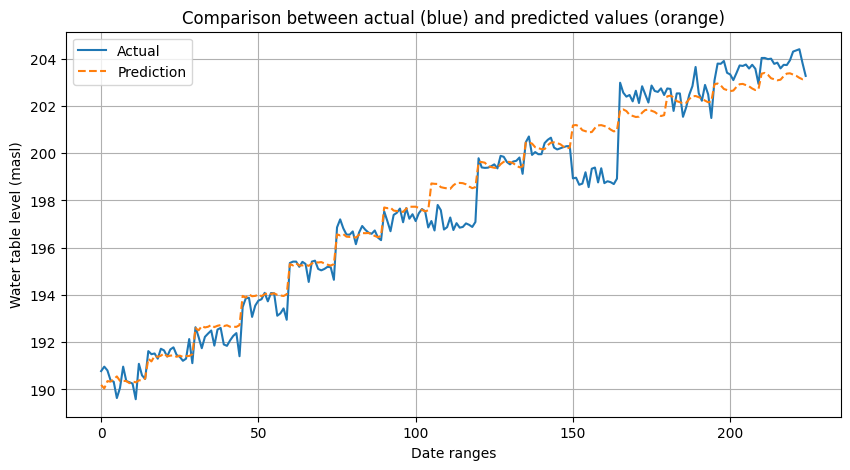

In [ ]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("Comparison between actual (blue) and predicted values (orange)")
plt.legend()
plt.grid()
plt.show()


Loss (MSE): 0.0413

MAE: 0.1434

R²: 0.9611

RMSE: 0.2032


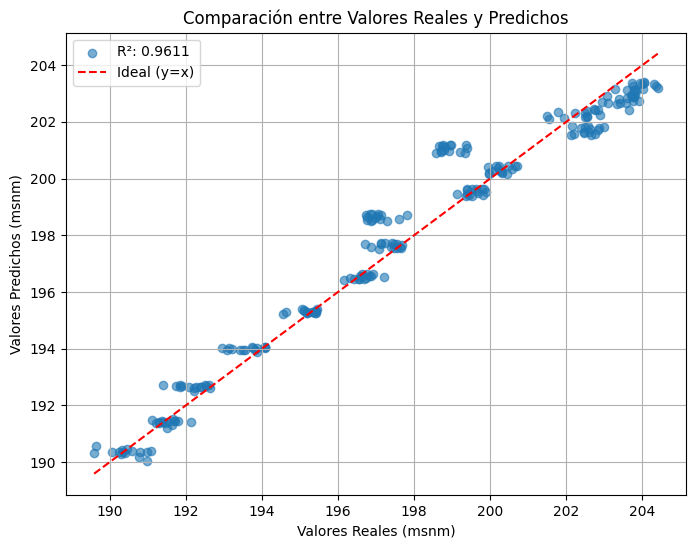

In [ ]:
# metricas

print(f"\nLoss (MSE): {loss:.4f}")
print(f"\nMAE: {mae:.4f}")
#luego calculamos:
#metrica r2, mejor valor mas cerca de 1
r2 = r2_score(y_test, y_pred_scaled)
print(f"\nR²: {r2:.4f}")

# metrica RMSE, mejor valor mas cerca de 0
#rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
rmse = np.sqrt(loss)
print(f"\nRMSE: {rmse:.4f}")


# dibujo por si sirve
# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()

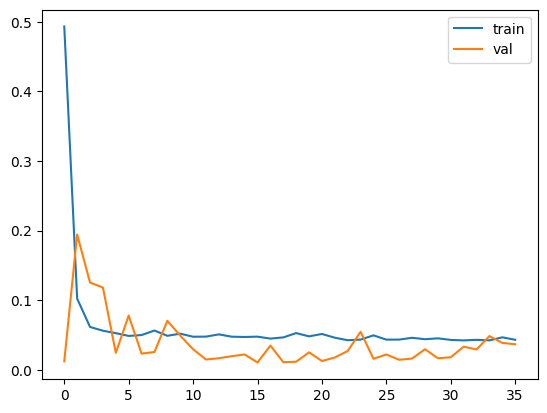

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()

###ANN

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo ANN como regresion**
# ========================================================================


from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Reshape X_train and X_test from 3D to 2D
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# Initialize and train MLPRegressor (for regression since y is continuous)

#da peor con 128, 64
#mlp = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
mlp = MLPRegressor(hidden_layer_sizes=(20,), alpha = 0.01, activation='relu', max_iter=500, solver='lbfgs', random_state=42)
mlp.fit(X_train_reshaped, y_train)

y_pred = mlp.predict(X_test_reshaped)

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error:: {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error:: 0.1527
Mean Squared Error (MSE): 0.0356
Root Mean Squared Error (RMSE): 0.1886
R-squared (R²): 0.9665


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


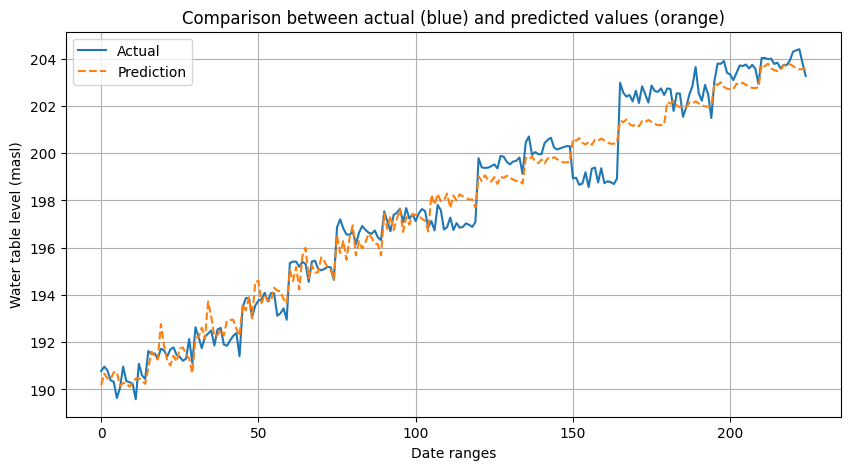

In [ ]:
#graficar

import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = mlp.predict(X_test_reshaped)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("Comparison between actual (blue) and predicted values (orange)")
plt.legend()
plt.grid()
plt.show()


Loss (MSE): 0.0356

RMSE: 0.1886

R²: 0.9665


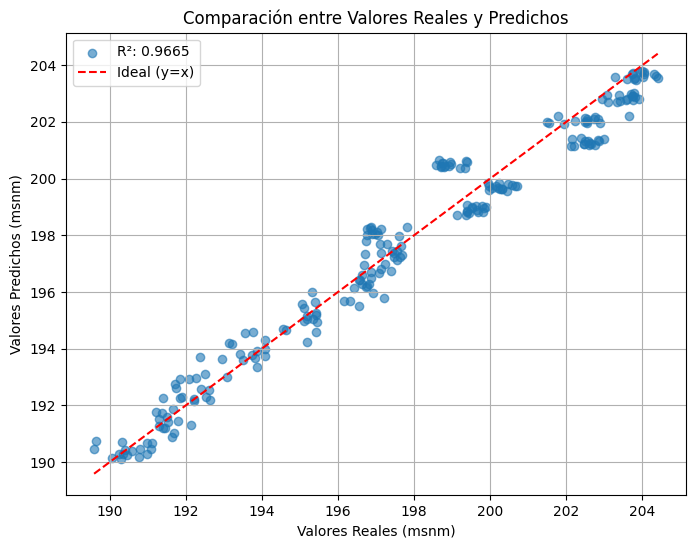

In [ ]:
import matplotlib.pyplot as plt

# Evaluate the model using regression metrics
#mse = mean_squared_error(y_test, y_pred)
#rmse = np.sqrt(mse)
#r2 = r2_score(y_test, y_pred)

#metricas

print(f"\nLoss (MSE): {mse:.4f}") # Using mse directly as the 'loss' metric
print(f"\nRMSE: {rmse:.4f}")
print(f"\nR²: {r2:.4f}")


# dibujo por si sirve
# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()

#### importance variables

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# Define the original feature names before flattening
# Corrected to reflect the 4 features actually used in X_train for this configuration
#original_feature_names = ['rain_rate_scaled', 'out_hum_scaled', 'dew_pt_scaled', 'freátimetro_id_encoded']
variable_names = ['out_hum_scaled', 'dew_pt_scaled','rain_rate_scaled','freátimetro_id_encoded']

result = permutation_importance(
    mlp,
    X_test_reshaped,      # (samples, 40)
    y_test,
    scoring='neg_mean_squared_error',
    n_repeats=20,
    random_state=42
)


# Feature importance per flattened feature
importances = result.importances_mean  # shape (40,)

# Reshape to (timesteps, variables)
##################################
# CAMBIAR ACA FIJARSE 4 tiempos, 4 variables
#############################
importances_reshaped = importances.reshape(4, 4)

# Aggregate over time (mean importance)
variable_importance = importances_reshaped.mean(axis=0)

for name, imp in zip(variable_names, variable_importance):
    print(f"{name}: {imp:.4f}")

importance_df = pd.DataFrame({
    "Variable": variable_names,
    "Importance": variable_importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)


out_hum_scaled: 0.0014
dew_pt_scaled: 0.0004
rain_rate_scaled: -0.0002
freátimetro_id_encoded: 0.3074
                 Variable  Importance
3  freátimetro_id_encoded    0.307384
0          out_hum_scaled    0.001374
1           dew_pt_scaled    0.000404
2        rain_rate_scaled   -0.000209


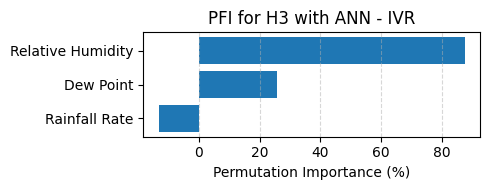

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1️⃣ Convert to percentages
# -----------------------------
importance_values = importance_df["Importance"].values

importance_percent = 100 * importance_values / np.sum(importance_values)

importance_df["Importance (%)"] = importance_percent

importance_df_clean = importance_df[
    importance_df["Variable"] != "freátimetro_id_encoded"].copy()

importance_values = importance_df_clean["Importance"].values
importance_percent = 100 * importance_values / importance_values.sum()

importance_df_clean["Importance (%)"] = importance_percent

plt.figure(figsize=(5, 2))


name_mapping = {
    "out_hum_scaled": "Relative Humidity",
    "dew_pt_scaled": "Dew Point",
    "rain_rate_scaled": "Rainfall Rate"
    }

importance_df_clean["Variable"] = importance_df_clean["Variable"].map(name_mapping)

plt.barh(
    importance_df_clean["Variable"],
    importance_df_clean["Importance (%)"]
)

plt.xlabel("Permutation Importance (%)")
plt.title("PFI for H3 with ANN - IVR")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()




###SVM

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo SVM**
# ========================================================================
#aplicar SVM, en realidad SVR para regresion

import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold



# Reshape X_train and X_test from 3D to 2D
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# 3. Create and train the SVR model
# A pipeline is used to first scale the data and then apply SVR
# The RBF kernel is a common choice for non-linear data
regr = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, epsilon=0.2, gamma=0.01))
regr.fit(X_train_reshaped, y_train) # Train the model
#Best Hyperparameters: {'svr__C': 100, 'svr__epsilon': 0.2, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}


# 4. Make predictions
y_pred = regr.predict(X_test_reshaped)



# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error:: {mae:.4f}")

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# 4. CONFIGURE CROSS-VALIDATION
# For small data (<50 samples), use KFold with more splits (e.g., 5 or 10)
# or even LeaveOneOut() to maximize training data usage.
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'svr__kernel': ['rbf'],              # RBF is usually best for small/complex data
    'svr__C': [0.1, 1, 10, 50, 100],     # Regularization: Higher C = less regularization
    'svr__gamma': ['scale', 0.1, 0.01],  # 'scale' is default, explicit floats help fine-tune
    'svr__epsilon': [0.01, 0.1, 0.2]     # Threshold of error tolerance
}

# 5. RUN GRID SEARCH
print("Tuning SVR... this may take a moment.")
grid_search = GridSearchCV(
    estimator=regr,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_mean_squared_error', # Optimized for lowest error
    n_jobs=-1,                        # Use all CPU cores
    verbose=1
)

grid_search.fit(X_train_reshaped, y_train)

# 6. RESULTS
best_params = grid_search.best_params_
best_score = -grid_search.best_score_  # Negating because scoring was negative MSE

print("\n--- Best Results ---")
print(f"Best Hyperparameters: {best_params}")
print(f"Best RMSE (approx): {np.sqrt(best_score):.4f}")


Mean Absolute Error:: 0.1622
Mean Squared Error (MSE): 0.0373
Root Mean Squared Error (RMSE): 0.1932
R-squared (R²): 0.9649
Tuning SVR... this may take a moment.
Fitting 5 folds for each of 45 candidates, totalling 225 fits

--- Best Results ---
Best Hyperparameters: {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
Best RMSE (approx): 0.1841


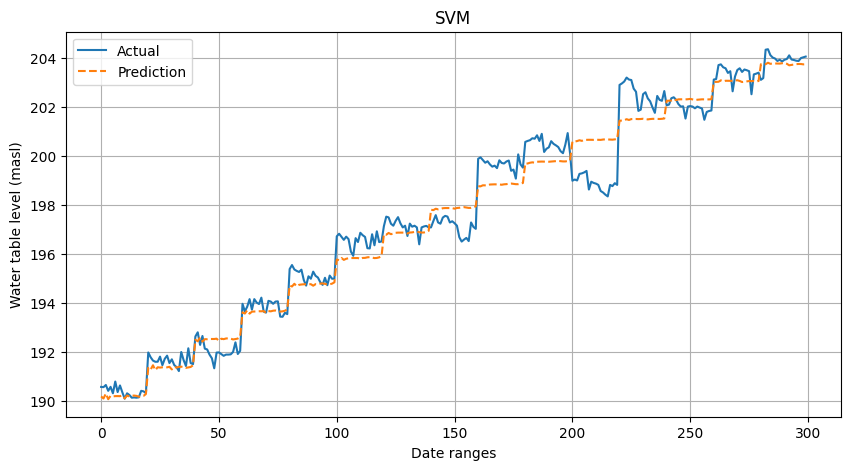

In [ ]:
#graficar

import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = regr.predict(X_test_reshaped)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("SVM")
plt.legend()
plt.grid()
plt.show()

## PARTE COMUN H2: con todas las variables climaticas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
archivo_excel = '/content/drive/MyDrive/tesisWalterDatos/preparedDatasets/datasetRedNcaso2.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datasetMerge = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)

In [ ]:
# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]  # Asegúrate de que esta lista contenga todos los freatímetros que desees incluir.
# Agrega aquí otras variables de interés si lo deseas
variables_interes = ['Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Bar', 'Rain Rate', 'Solar Rad.', 'ET']
 # Añade tus variables relevantes



# Combina las listas
columnas_interes = freatimetros + variables_interes

print(columnas_interes)

[60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053, 'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Bar', 'Rain Rate', 'Solar Rad.', 'ET']


['Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Bar', 'Rain Rate', 'Solar Rad.', 'ET']


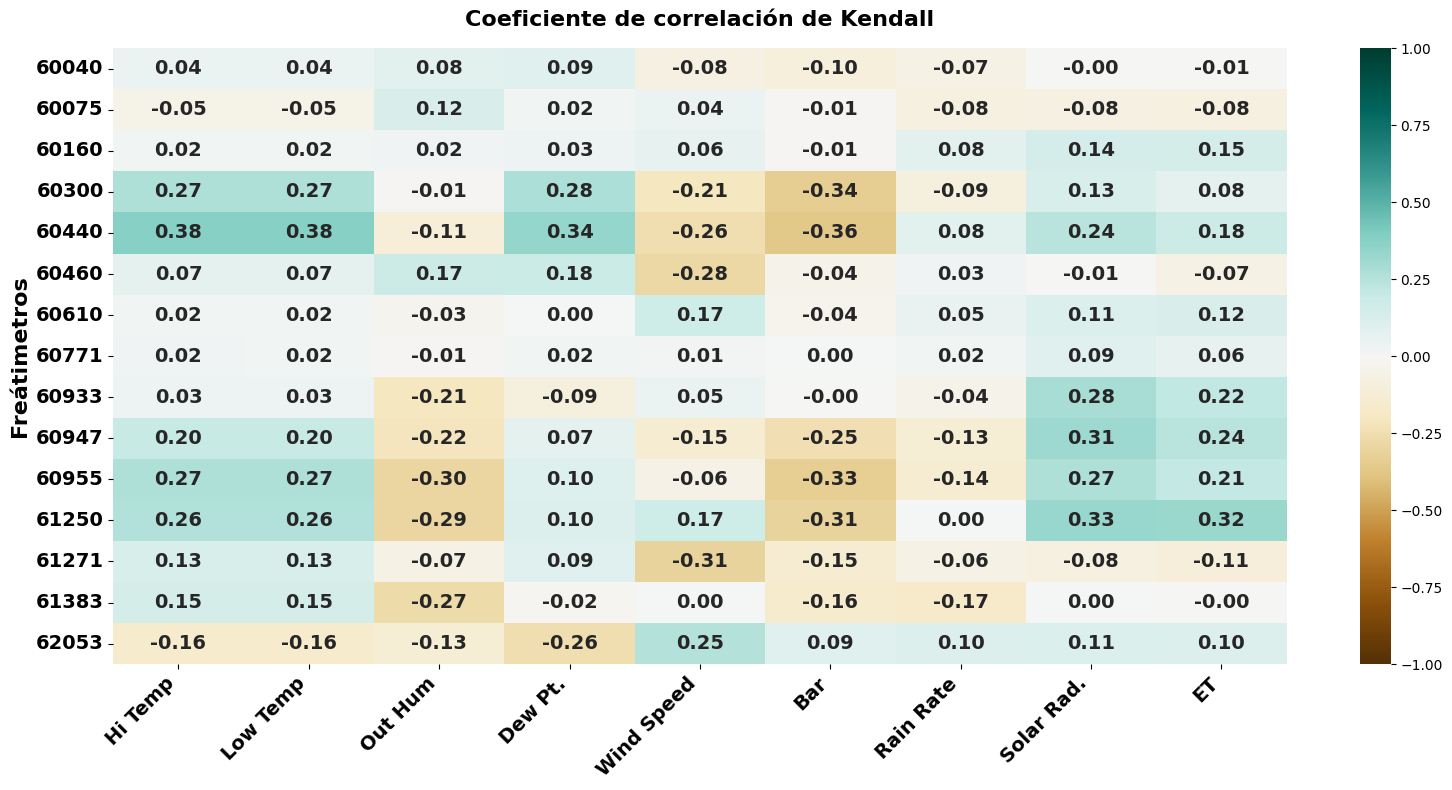

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
aux = datasetMerge[columnas_interes].corr(method='pearson')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

print(climaticas_labels)

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

#Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
#variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.10).sum(), axis=0)
#variables_to_keep = variables_to_keep[variables_to_keep > 7].index  # Variables que cumplen la condición

# Filtrar la matriz para las variables climáticas seleccionadas
#filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
# Transformar el dataset al formato "long" para incluir todos los freátimetros
# Identificar las columnas de los freátimetros
freatimetro_columns = [60040, 60075, 60160, 60300, 60440, 60460, 60610,
                       60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]
#'In  Dew','Hi Speed'
variables_interes = ['Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Bar', 'Rain Rate', 'Solar Rad.', 'ET','fecha']
#print(datasetMerge)

# Usar pandas.melt para transformar el dataset
long_data = pd.melt(
    datasetMerge,
    id_vars=variables_interes,  # Variables comunes
    value_vars=freatimetro_columns,  # Columnas de freátimetros
    var_name='freátimetro_id',       # Nombre de la columna de identificadores
    value_name='nivel_freatico'      # Valores de los niveles freáticos
)
#print(long_data)

# Ordenar por fecha para preservar la secuencia temporal
long_data.sort_values(by=['fecha', 'freátimetro_id'], inplace=True)
# Verificar el formato de la columna 'fecha'
print(long_data['fecha'].dtype)
print(long_data['fecha'].head())
long_data = long_data[
    #ya tenia solo esos meses igualmente
    (long_data['fecha'].dt.month.isin([1,2,3,4,9,10,11,12])) &
    (long_data['fecha'].dt.year.between(2010, 2021))
]

# Revisar el resultado de la transformación
print(f'el long data tiene {long_data.head()} ')

datetime64[ns]
0     2010-01-01
77    2010-01-01
154   2010-01-01
231   2010-01-01
308   2010-01-01
Name: fecha, dtype: datetime64[ns]
el long data tiene        Hi Temp   Low Temp    Out Hum   Dew Pt.  Wind Speed         Bar  \
0    15.679427  15.359879  54.647326  4.970003    2.954101  762.073796   
77   15.679427  15.359879  54.647326  4.970003    2.954101  762.073796   
154  15.679427  15.359879  54.647326  4.970003    2.954101  762.073796   
231  15.679427  15.359879  54.647326  4.970003    2.954101  762.073796   
308  15.679427  15.359879  54.647326  4.970003    2.954101  762.073796   

     Rain Rate  Solar Rad.        ET      fecha freátimetro_id  nivel_freatico  
0     0.305193  174.213254  0.023448 2010-01-01          60040         191.432  
77    0.305193  174.213254  0.023448 2010-01-01          60075         192.015  
154   0.305193  174.213254  0.023448 2010-01-01          60160         194.180  
231   0.305193  174.213254  0.023448 2010-01-01          60300         195.25

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Asumo que ya tenés tu DataFrame df con las variables climáticas y el freatimetro_id

# ========================================================================
# 1️⃣ **Preprocesamiento: Codificación y Normalización - Variables Climáticas**
# ========================================================================
df = long_data.copy()
# 🔹 **Orden personalizado para freatímetros**
unique_ids = np.sort(df['freátimetro_id'].unique())
custom_order = [62053] + [id_ for id_ in unique_ids if id_ != 62053]
id_to_encoded = {id_: idx for idx, id_ in enumerate(custom_order)}
df['freátimetro_id_encoded'] = df['freátimetro_id'].map(id_to_encoded)

# 🔹 **Escalar las variables climáticas seleccionadas**
#'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Bar', 'Rain Rate', 'Hi Solar Rad.', 'ET'
scaler_X = StandardScaler()
df[['hi_temp_scaled', 'low_temp_scaled', 'out_hum_scaled', 'dew_pt_scaled', 'wind_speed_scaled', 'bar_scaled',
    'rain_rate_scaled', 'solar_rad_scaled', 'ET_scaled']] = scaler_X.fit_transform(df[['Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Bar', 'Rain Rate', 'Solar Rad.', 'ET']])

# 🔹 **Escalar la variable de salida (nivel freático)**
scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])

# ========================================================================
# 2️⃣ **Generación de Secuencias (Ventana de 8 Meses)**
# ========================================================

def create_sequences_per_freatimetro(df, window_size=8):
    """
    Genera secuencias por cada freatímetro sin mezclar datos entre ellos.
    """
    X_seq, y_seq, freatimetros_seq, fechas_seq = [], [], [], []

    for freatimetro_id in df['freátimetro_id_encoded'].unique():
        df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

        X = df_freatimetro[['hi_temp_scaled', 'low_temp_scaled', 'out_hum_scaled', 'dew_pt_scaled', 'wind_speed_scaled', 'bar_scaled',
                            'rain_rate_scaled', 'solar_rad_scaled', 'ET_scaled', 'freátimetro_id_encoded']].values
        y = df_freatimetro['nivel_freatico_scaled'].values
        fechas = df_freatimetro['fecha'].values

        for i in range(len(X) - window_size):
            ventana_X = X[i:i + window_size]
            valor_y = y[i + window_size]
            fecha_prediccion = fechas[i + window_size]

            X_seq.append(ventana_X)
            y_seq.append(valor_y)
            freatimetros_seq.append(freatimetro_id)
            fechas_seq.append(fecha_prediccion)

    return np.array(X_seq), np.array(y_seq), np.array(freatimetros_seq), np.array(fechas_seq)

# ========================================================================
# 3️⃣ **División en Entrenamiento y Prueba POR FREATÍMETRO**
# ========================================================================

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
freatimetros_train_list, freatimetros_test_list = [], []
fechas_train_list, fechas_test_list = [], []

X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df, window_size=4)

for freatimetro_id in np.unique(freatimetros_seq):
    indices_freatimetro = np.where(freatimetros_seq == freatimetro_id)[0]
    train_size = int(len(indices_freatimetro) * 0.8)

    X_train_list.append(X_seq[indices_freatimetro[:train_size]])
    X_test_list.append(X_seq[indices_freatimetro[train_size:]])
    y_train_list.append(y_seq[indices_freatimetro[:train_size]])
    y_test_list.append(y_seq[indices_freatimetro[train_size:]])
    fechas_train_list.append(fechas_seq[indices_freatimetro[:train_size]])
    fechas_test_list.append(fechas_seq[indices_freatimetro[train_size:]])
    freatimetros_train_list.append(freatimetros_seq[indices_freatimetro[:train_size]])
    freatimetros_test_list.append(freatimetros_seq[indices_freatimetro[train_size:]])

X_train, X_test = np.vstack(X_train_list), np.vstack(X_test_list)
y_train, y_test = np.hstack(y_train_list), np.hstack(y_test_list)
fechas_train, fechas_test = np.hstack(fechas_train_list), np.hstack(fechas_test_list)
freatimetros_train, freatimetros_test = np.hstack(freatimetros_train_list), np.hstack(freatimetros_test_list)

# ========================================================================
# ✅ **Verificación**
# ========================================================================
print(f"🔹 X_train shape: {X_train.shape}  (n_muestras, 4 time steps, 10 variables)")  # 10 variables ahora
print(f"🔹 y_train shape: {y_train.shape}")
print(f"🔹 Variables usadas: {variables_interes} + ID freatímetro")
#X_seq[0]
X_test[0]

🔹 X_train shape: (870, 4, 10)  (n_muestras, 4 time steps, 10 variables)
🔹 y_train shape: (870,)
🔹 Variables usadas: ['Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.', 'Wind Speed', 'Bar', 'Rain Rate', 'Solar Rad.', 'ET', 'fecha'] + ID freatímetro


array([[ 0.15704093,  0.16024965,  1.44667586,  1.05729416, -1.50786824,
        -0.01368325,  0.98574808, -0.52936722, -0.67213837,  0.        ],
       [-1.06326661, -1.05183455,  2.6301191 ,  0.44817504, -1.5319006 ,
         0.946902  ,  0.40927278, -1.40184061, -1.53390984,  0.        ],
       [-0.92444401, -0.92137006,  0.42960508, -0.72370692, -0.19094308,
         0.77715987, -0.01562957, -0.81803797, -0.71942732,  0.        ],
       [-0.51986861, -0.5252464 , -1.14254711, -1.29521829,  0.30839624,
        -0.25907059, -0.47953316,  0.22371677,  0.22360609,  0.        ]])

### LSTM:  2da configuracion, segun paper, puse solo esta

Number of LSTM layers 2

Number of units per layer 128-64

Batch size 16

Number of epochs 200

Learning rate 0.001

Activation function (LSTM) tanh

Dropout rate (LSTM) 0.3

Optimization Adam

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
# 1ra configuracion

#Number of LSTM layers 2
#Number of units per layer 128-64
#Activation function (LSTM) tanh

model = Sequential()
#capa 1
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh', return_sequences=True))
model.add(Dropout(0.3))

#capa 2
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))

model.add(Dense(1, activation='linear'))


# 🔹 **Compilar el Modelo**

#Optimization Adam
#Learning rate 0.001
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

#Batch size 16
#Number of epochs 200

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])

NameError: name 'Sequential' is not defined

In [ ]:
# veo la importantce de cada variable para LSTM

import numpy as np
from sklearn.metrics import mean_squared_error

baseline = mean_squared_error(y_test, model.predict(X_test))

importances = {}

# Define feature_names based on your scaled input features and encoded freatímetro_id
# This should match the order and number of features in X_train
feature_names = ['hi_temp_scaled', 'low_temp_scaled', 'out_hum_scaled', 'dew_pt_scaled',
                 'wind_speed_scaled', 'bar_scaled', 'rain_rate_scaled',
                 'solar_rad_scaled', 'ET_scaled']

for i, name in enumerate(feature_names):
    Xp = X_test.copy()
    for t in range(Xp.shape[1]):      # loop over timesteps
        np.random.shuffle(Xp[:, t, i])

    score = mean_squared_error(y_test, model.predict(Xp))
    importances[name] = score - baseline

print("Feature Importances:")
for name, importance in sorted(importances.items(), key=lambda item: item[1], reverse=True):
    print(f"  {name}: {importance:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Feature Importances:
  ET_scaled: 0.0081
  hi_temp_scaled: 0.0078
  bar_scaled: 0.0077
  dew_pt_scaled: 0.0066
  solar_rad_scaled: 0.0061
  out_hum_scaled: 0.0058
  low_temp_scaled: 0.0052
  rain_rate_scaled: 0.0008
  wind_speed_scaled: -0.0001


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

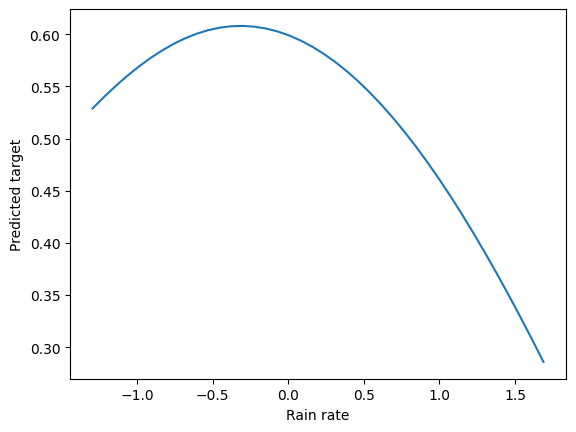

In [ ]:
# con SHAP
X_ref = X_test.mean(axis=0)
i = feature_names.index("dew_pt_scaled")

values = np.linspace(
    X_test[:,:,i].min(),
    X_test[:,:,i].max(),
    40
)

outputs = []

for v in values:
    X_temp = X_ref.copy()
    X_temp[:, i] = v
    y_pred = model.predict(X_temp[np.newaxis, ...])
    outputs.append(y_pred[0,0])

import matplotlib.pyplot as plt

plt.plot(values, outputs)
plt.xlabel("Rain rate")
plt.ylabel("Predicted target")
plt.show()



In [ ]:
import numpy as np

def permutation_importance_lstm(model, X_test, y_test, metric_func):
    baseline = metric_func(model, X_test, y_test)
    importances = []

    n_features = X_test.shape[2]

    for i in range(n_features):
        X_perm = X_test.copy()

        # Shuffle feature i across samples
        idx = np.random.permutation(X_test.shape[0])
        X_perm[:, :, i] = X_perm[idx, :, i]

        score = metric_func(model, X_perm, y_test)
        importances.append(score - baseline)

    return np.array(importances)


def rmse_metric(model, X, y):
    y_pred = model.predict(X, verbose=0)
    return np.sqrt(mean_squared_error(y, y_pred))

importances = permutation_importance_lstm(
    model, X_test, y_test, rmse_metric
)

for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")


hi_temp_scaled: 0.0370
low_temp_scaled: 0.0481
out_hum_scaled: 0.0345
dew_pt_scaled: 0.0478
wind_speed_scaled: 0.0056
bar_scaled: 0.0343
rain_rate_scaled: 0.0004
solar_rad_scaled: 0.0431
ET_scaled: 0.0289


In [ ]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================

# aca calcule las métricas loss=mse y  mae
loss, mae = model.evaluate(X_test, y_test, verbose=1)

loss_test, mae_test = model.evaluate(X_test, y_test, verbose=0)

print("Test loss (MSE):", loss_test)
print("Test MAE:", mae_test)


# 🔹 **Generar Predicciones**
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 **Decodificar los IDs de los freatímetros**
encoded_to_id = {v: k for k, v in id_to_encoded.items()}
freatimetros_test_original=  [encoded_to_id[id_] for id_ in freatimetros_test]

# 🔹 **Crear un DataFrame con los resultados**
df_resultados = pd.DataFrame({
    "Fecha": fechas_test,
    "Freátimetro ID": freatimetros_test_original,
    "Predicción": y_pred.flatten(),
    "Real": y_test_descaled.flatten()
})

# 🔹 **Obtener la última predicción por cada freatímetro**
df_resultados = df_resultados.sort_values(by=["Freátimetro ID", "Fecha"])  # Ordenar correctamente
df_ultimas_predicciones = df_resultados.groupby("Freátimetro ID").last().reset_index()

# 🔹 **Mostrar los resultados finales**
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
print(df_ultimas_predicciones)

# 🔹 **Opcional: Guardar en Excel para análisis posterior**
df_ultimas_predicciones.to_excel("predicciones_ventana4.xlsx", index=False)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0751 - mae: 0.2269
Test loss (MSE): 0.07534641027450562
Test MAE: 0.22013607621192932
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Loss (MSE): 0.0753, MAE: 0.2201
📌 Última predicción de cada freatímetro:
    Freátimetro ID      Fecha  Predicción     Real
0            60040 2019-09-01  193.131470  191.112
1            60075 2019-09-01  194.050217  191.405
2            60160 2019-09-01  195.047241  192.950
3            60300 2019-09-01  196.062408  194.642
4            60440 2019-09-01  197.057114  196.320
5            60460 2019-09-01  198.006042  196.858
6            60610 2019-09-01  198.893036  197.090
7            60771 2019-09-01  199.708832  199.130
8            60933 2019-09-01  200.449326  200.300
9            60947 2019-09-01  201.114014  198.925
10           60955 2019-09-01  201.704788  202.467
11           61250 2019-09-01  202.225067  201.493
12           61271 2019-09-01  202.679352  202.937
13           61383 2019-09-01  203.07290

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


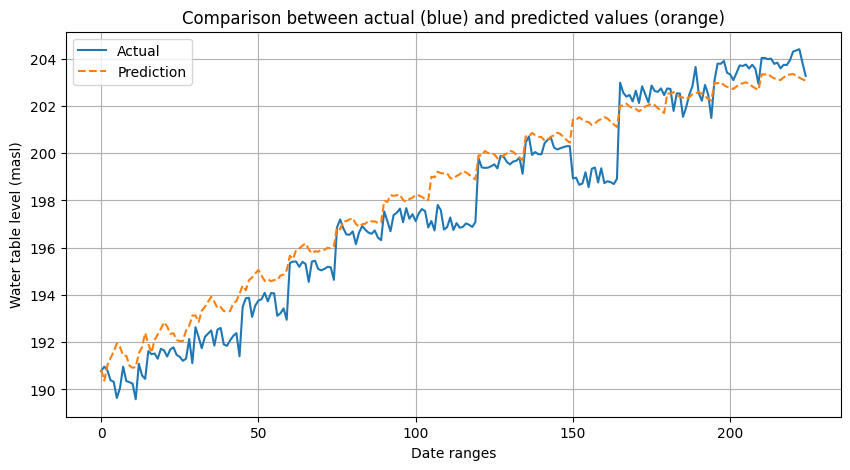

In [ ]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("Comparison between actual (blue) and predicted values (orange)")
plt.legend()
plt.grid()
plt.show()


Loss (MSE): 0.0753

MAE: 0.2201

R²: 0.9291

RMSE: 0.2745


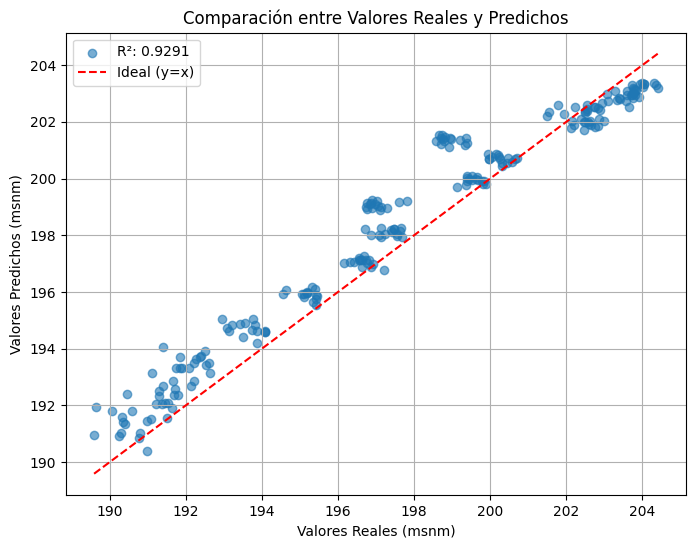

In [ ]:
# metricas

print(f"\nLoss (MSE): {loss:.4f}")
print(f"\nMAE: {mae:.4f}")
#luego calculamos:
#metrica r2, mejor valor mas cerca de 1
r2 = r2_score(y_test, y_pred_scaled)
print(f"\nR²: {r2:.4f}")

# metrica RMSE, mejor valor mas cerca de 0
#rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
rmse = np.sqrt(loss)
print(f"\nRMSE: {rmse:.4f}")


# dibujo por si sirve
# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()


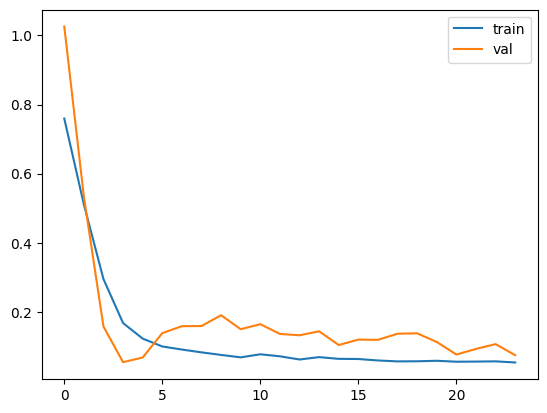

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()

### ANN

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo ANN como regresion**
# ========================================================================


from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Reshape X_train and X_test from 3D to 2D
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# Initialize and train MLPRegressor (for regression since y is continuous)

#da peor con 128, 64
#mlp = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
mlp = MLPRegressor(hidden_layer_sizes=(20,), alpha = 0.01, activation='relu', max_iter=500, solver='lbfgs', random_state=42)
mlp.fit(X_train_reshaped, y_train)

y_pred = mlp.predict(X_test_reshaped)

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error:: {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error:: 0.1696
Mean Squared Error (MSE): 0.0444
Root Mean Squared Error (RMSE): 0.2108
R-squared (R²): 0.9582


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


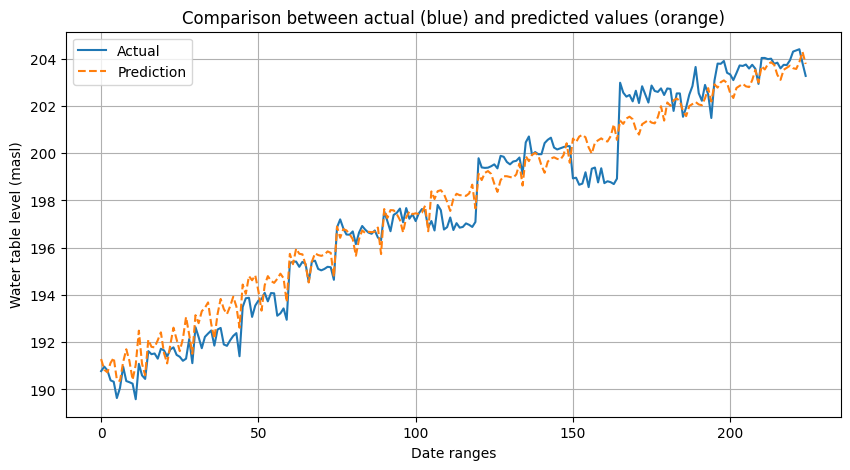

In [ ]:
#graficar

import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = mlp.predict(X_test_reshaped)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("Comparison between actual (blue) and predicted values (orange)")
plt.legend()
plt.grid()
plt.show()


Loss (MSE): 0.0444

RMSE: 0.2108

R²: 0.9582


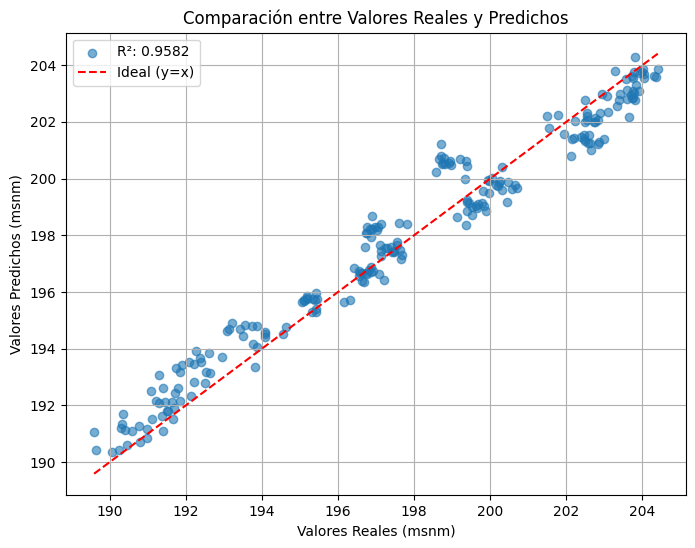

In [ ]:
import matplotlib.pyplot as plt

# Evaluate the model using regression metrics
#mse = mean_squared_error(y_test, y_pred)
#rmse = np.sqrt(mse)
#r2 = r2_score(y_test, y_pred)

#metricas

print(f"\nLoss (MSE): {mse:.4f}") # Using mse directly as the 'loss' metric
print(f"\nRMSE: {rmse:.4f}")
print(f"\nR²: {r2:.4f}")


# dibujo por si sirve
# Crear figura
plt.figure(figsize=(8,6))

# Graficar puntos reales vs predichos
plt.scatter(y_test_descaled, y_pred, alpha=0.6, label=f"R²: {r2:.4f}")

# Línea perfecta (x=y)
plt.plot([min(y_test_descaled), max(y_test_descaled)], [min(y_test_descaled), max(y_test_descaled)], 'r--', label="Ideal (y=x)")

# Etiquetas
plt.xlabel("Valores Reales (msnm)")
plt.ylabel("Valores Predichos (msnm)")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.grid(True)

# Mostrar gráfico
plt.show()

#### importance variables

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# Define the original feature names before flattening
# Corrected to reflect the 4 features actually used in X_train for this configuration
#original_feature_names = ['rain_rate_scaled', 'out_hum_scaled', 'dew_pt_scaled', 'freátimetro_id_encoded']
variable_names = ['hi_temp_scaled', 'low_temp_scaled', 'out_hum_scaled', 'dew_pt_scaled',
                 'wind_speed_scaled', 'bar_scaled', 'rain_rate_scaled',
                 'solar_rad_scaled', 'ET_scaled', 'freátimetro_id_encoded']

result = permutation_importance(
    mlp,
    X_test_reshaped,      # (samples, 40)
    y_test,
    scoring='neg_mean_squared_error',
    n_repeats=20,
    random_state=42
)


# Feature importance per flattened feature
importances = result.importances_mean  # shape (40,)

# Reshape to (timesteps, variables)
# CAMBIAR ACA FIJARSE 4 tiempos, 10 variables
importances_reshaped = importances.reshape(4, 10)

# Aggregate over time (mean importance)
variable_importance = importances_reshaped.mean(axis=0)

for name, imp in zip(variable_names, variable_importance):
    print(f"{name}: {imp:.4f}")

importance_df = pd.DataFrame({
    "Variable": variable_names,
    "Importance": variable_importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)


hi_temp_scaled: 0.0051
low_temp_scaled: 0.0018
out_hum_scaled: 0.0005
dew_pt_scaled: 0.0005
wind_speed_scaled: 0.0002
bar_scaled: 0.0015
rain_rate_scaled: -0.0001
solar_rad_scaled: 0.0027
ET_scaled: 0.0019
freátimetro_id_encoded: 0.1556
                 Variable  Importance
9  freátimetro_id_encoded    0.155611
0          hi_temp_scaled    0.005066
7        solar_rad_scaled    0.002667
8               ET_scaled    0.001937
1         low_temp_scaled    0.001769
5              bar_scaled    0.001497
3           dew_pt_scaled    0.000542
2          out_hum_scaled    0.000541
4       wind_speed_scaled    0.000231
6        rain_rate_scaled   -0.000052


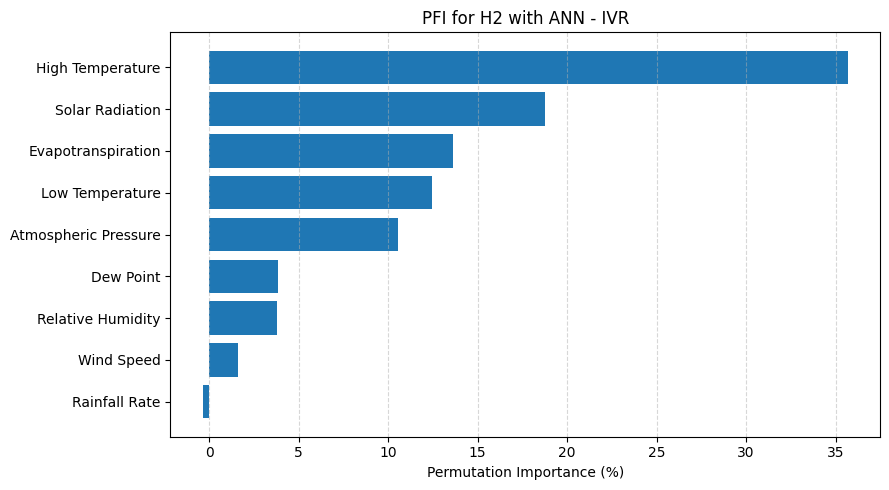

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1️⃣ Convert to percentages
# -----------------------------
importance_values = importance_df["Importance"].values

importance_percent = 100 * importance_values / np.sum(importance_values)

importance_df["Importance (%)"] = importance_percent

importance_df_clean = importance_df[
    importance_df["Variable"] != "freátimetro_id_encoded"].copy()

importance_values = importance_df_clean["Importance"].values
importance_percent = 100 * importance_values / importance_values.sum()

importance_df_clean["Importance (%)"] = importance_percent

plt.figure(figsize=(9, 5))


name_mapping = {
    "hi_temp_scaled": "High Temperature",
    "low_temp_scaled": "Low Temperature",
    "out_hum_scaled": "Relative Humidity",
    "dew_pt_scaled": "Dew Point",
    "wind_speed_scaled": "Wind Speed",
    "bar_scaled": "Atmospheric Pressure",
    "rain_rate_scaled": "Rainfall Rate",
    "solar_rad_scaled": "Solar Radiation",
    "ET_scaled": "Evapotranspiration"
}

importance_df_clean["Variable"] = importance_df_clean["Variable"].map(name_mapping)

plt.barh(
    importance_df_clean["Variable"],
    importance_df_clean["Importance (%)"]
)

plt.xlabel("Permutation Importance (%)")
plt.title("PFI for H2 with ANN - IVR")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()




###SVM

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo SVM**
# ========================================================================
#aplicar SVM, en realidad SVR para regresion

import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold



# Reshape X_train and X_test from 3D to 2D
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

# 3. Create and train the SVR model
# A pipeline is used to first scale the data and then apply SVR
# The RBF kernel is a common choice for non-linear data
regr = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, epsilon=0.2, gamma=0.01))
regr.fit(X_train_reshaped, y_train) # Train the model
#Best Hyperparameters: {'svr__C': 100, 'svr__epsilon': 0.2, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}


# 4. Make predictions
y_pred = regr.predict(X_test_reshaped)



# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error:: {mae:.4f}")

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# 4. CONFIGURE CROSS-VALIDATION
# For small data (<50 samples), use KFold with more splits (e.g., 5 or 10)
# or even LeaveOneOut() to maximize training data usage.
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'svr__kernel': ['rbf'],              # RBF is usually best for small/complex data
    'svr__C': [0.1, 1, 10, 50, 100],     # Regularization: Higher C = less regularization
    'svr__gamma': ['scale', 0.1, 0.01],  # 'scale' is default, explicit floats help fine-tune
    'svr__epsilon': [0.01, 0.1, 0.2]     # Threshold of error tolerance
}

# 5. RUN GRID SEARCH
print("Tuning SVR... this may take a moment.")
grid_search = GridSearchCV(
    estimator=regr,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_mean_squared_error', # Optimized for lowest error
    n_jobs=-1,                        # Use all CPU cores
    verbose=1
)

grid_search.fit(X_train_reshaped, y_train)

# 6. RESULTS
best_params = grid_search.best_params_
best_score = -grid_search.best_score_  # Negating because scoring was negative MSE

print("\n--- Best Results ---")
print(f"Best Hyperparameters: {best_params}")
print(f"Best RMSE (approx): {np.sqrt(best_score):.4f}")


Mean Absolute Error:: 0.1723
Mean Squared Error (MSE): 0.0472
Root Mean Squared Error (RMSE): 0.2174
R-squared (R²): 0.9555
Tuning SVR... this may take a moment.
Fitting 5 folds for each of 45 candidates, totalling 225 fits

--- Best Results ---
Best Hyperparameters: {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
Best RMSE (approx): 0.1888


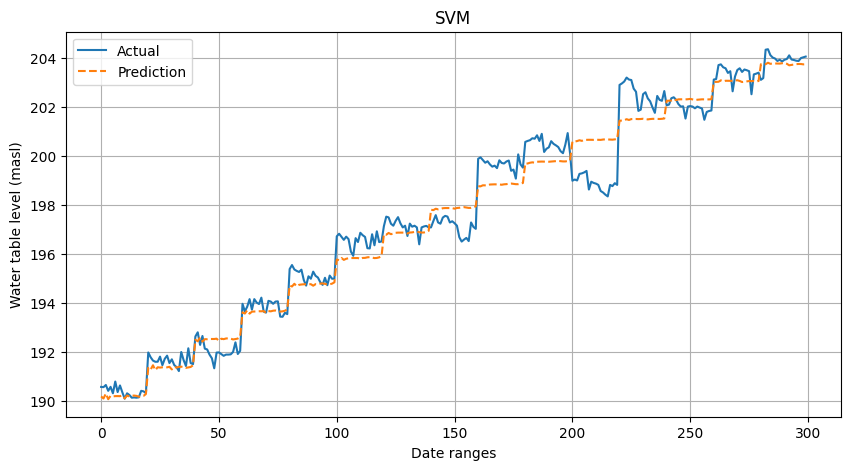

In [ ]:
#graficar

import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = regr.predict(X_test_reshaped)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Actual", linestyle="-")
plt.plot(y_pred, label="Prediction", linestyle="dashed")
plt.xlabel("Date ranges")
plt.ylabel("Water table level (masl)")
plt.title("SVM")
plt.legend()
plt.grid()
plt.show()